# IndoBERT Clickbait Detection - Complete Pipeline

This notebook runs the complete training and evaluation pipeline for IndoBERT-based clickbait detection with robustness evaluation.

**Requirements:**
- GPU Runtime (T4 for testing, A100 for full training)
- 5 CSV files with columns: `id`, `source`, `date`, `title`, `Label`, `url`
  (one file per domain: technology.csv, politic.csv, health.csv, sport.csv, education.csv)
- ~(TBA) hours for complete execution

❗❗**BOLD -> changed**

---
**model: base**

**BertTokenizer**

DROPOUT_RATE: float = 0.1

# Hyperparameters
LEARNING_RATE: float = 2e-5

BATCH_SIZE: int = 32

NUM_EPOCHS: int = 4

WEIGHT_DECAY: float = 0.01

WARMUP_RATIO: float = 0.1

# Optimizer
OPTIMIZER: str = "AdamW"

EPSILON: float = 1e-8

MAX_GRAD_NORM: float = 1.0

# Early stopping
EARLY_STOPPING_PATIENCE: int = 2

EARLY_STOPPING_METRIC: str = "f1"

# Learning rate scheduler
SCHEDULER_TYPE: str = "linear"

In [ ]:
import os

os.environ["HF_HUB_DISABLE_XET"] = "1"

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# %cd /content
# !rm -rf domain-shift-trustworthy-ai

%cd /content/drive/MyDrive/
!rm -rf run_thesis

%cd /content
!rm -rf checkpoints_staging

%cd domain-shift-trustworthy-ai

/content/drive/MyDrive
/content
[Errno 2] No such file or directory: 'domain-shift-trustworthy-ai'
/content


## 1. Environment Setup

In [ ]:
# Check GPU availability
!nvidia-smi

Wed Sep  2 13:54:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P0             27W /   70W |     635MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Clone repository or upload code files
# Option 1: Clone from GitHub
!git clone https://github.com/gredss/domain-shift-trustworthy-ai.git
%cd domain-shift-trustworthy-ai

# # Option 2: Upload files manually
# from google.colab import files
# import os

# print("Upload all Python files (.py) from your project")
# uploaded = files.upload()

# # List uploaded files
# !ls -lh *.py

Cloning into 'domain-shift-trustworthy-ai'...
remote: Enumerating objects: 559, done.
remote: Counting objects: 100% (214/214), done.
remote: Compressing objects: 100% (181/181), done.
remote: Total 559 (delta 128), reused 63 (delta 33), pack-reused 345 (from 1)
Receiving objects: 100% (559/559), 6.87 MiB | 13.78 MiB/s, done.
Resolving deltas: 100% (320/320), done.
/content/domain-shift-trustworthy-ai


In [ ]:
%%writefile /content/domain-shift-trustworthy-ai/src/model_trainer.py
# 31 AUG - add do_lower_case: True in tokenizer
"""
Model Trainer Module for IndoBERT Clickbait Detection System

This module handles model initialization, training loop implementation,
hyperparameter grid search, checkpoint management, and evaluation utilities
for IndoBERT variants (base, large, lite).
"""

import os
import json
import shutil
import time
import traceback
from itertools import product
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoModel,
    AutoTokenizer,BertTokenizer,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from typing import Dict, List, Tuple, Optional, Any
import pandas as pd
import numpy as np
from tqdm import tqdm
import logging
from datetime import datetime
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

from debug_logger import (
    dbg_dataset_created,
    dbg_tokenizer_samples,
    dbg_trainer_init,
    dbg_trainer_batch,
    dbg_trainer_epoch_end,
    dbg_trainer_predict_start,
    dbg_trainer_predict_batch,
    dbg_trainer_predict_done,
)

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


class ClickbaitDataset(Dataset):
    """
    PyTorch Dataset for clickbait detection.
    """

    def __init__(
        self,
        texts: List[str],
        labels: List[int],
        tokenizer: AutoTokenizer,
        max_length: int = 128,
        split_name: str = ""
    ):
        """
        Initialize the dataset.

        Args:
            texts: List of text strings
            labels: List of binary labels (0 or 1)
            tokenizer: Tokenizer for text preprocessing
            max_length: Maximum sequence length
            split_name: Optional label for debug output (e.g. 'train', 'val')
        """
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

        # ── debug: dataset stats ───────────────────────────────────────────
        n_clickbait = sum(1 for l in labels if l == 1)
        dbg_dataset_created(
            split_name=split_name,
            n_samples=len(texts),
            n_clickbait=n_clickbait,
        )
        # ── debug: sample tokenisations ───────────────────────────────────
        dbg_tokenizer_samples(
            tokenizer=tokenizer,
            texts=texts,
            labels=labels,
            max_length=max_length,
        )

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


class IndoBERTClassifier(nn.Module):
    """
    IndoBERT-based binary classifier for clickbait detection.
    """

    def __init__(
        self,
        model_name: str = "indobenchmark/indobert-base-p1",
        num_labels: int = 2,
        dropout_rate: float = 0.1
    ):
        """
        Initialize the classifier.

        Args:
            model_name: Name of the pretrained IndoBERT model
            num_labels: Number of output classes (2 for binary)
            dropout_rate: Dropout probability for regularization
        """
        super(IndoBERTClassifier, self).__init__()

        self.model_name = model_name
        self.num_labels = num_labels

        # Load pretrained IndoBERT
        self.bert = AutoModel.from_pretrained(model_name)

        # Get hidden size from model config
        self.hidden_size = self.bert.config.hidden_size

        # Classification head
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(self.hidden_size, num_labels)

        logger.info(f"Initialized {model_name} with hidden_size={self.hidden_size}")

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor
    ) -> torch.Tensor:
        """
        Forward pass through the model.

        Args:
            input_ids: Token IDs [batch_size, seq_length]
            attention_mask: Attention mask [batch_size, seq_length]

        Returns:
            Logits [batch_size, num_labels]
        """
        # Get BERT outputs
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Use CLS token representation
        pooled_output = outputs.last_hidden_state[:, 0, :]

        # Apply dropout and classification layer
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        return logits


def _copy_to_drive(src: str, dst: str, retries: int = 5, base_delay: float = 3.0) -> None:
    """
    Copy a fully-written local file to a destination path, with exponential
    back-off retries for transient OSError failures (e.g. Drive FUSE rate
    limits that return [Errno 95] Operation not supported).

    Design rationale
    ----------------
    src is always a local /tmp file that torch.save() has already closed and
    fully committed to local disk.  We therefore need only a reliable *copy*
    to the destination — no fsync, no kernel-buffer tricks, no magic-byte
    verification.  Those approaches are unreliable on network FUSE mounts and
    add latency without meaningful safety guarantees.

    The correct architectural pattern (enforced by train_pipeline.py) is:
      1. Train entirely with local checkpoint_dir (/content/...)
      2. Call _copy_to_drive once per domain after training completes
    This keeps Drive I/O off the hot training path entirely.

    Args:
        src: Local source path (fully written, e.g. /content/checkpoints/...)
        dst: Destination path (may be on Google Drive FUSE)
        retries: Maximum number of attempts (default 5)
        base_delay: Initial back-off delay in seconds; doubles each retry
    """
    last_err: Exception = RuntimeError("No attempts made")
    delay = base_delay
    for attempt in range(1, retries + 1):
        try:
            shutil.copy2(src, dst)
            return  # success
        except OSError as exc:
            last_err = exc
            logger.warning(
                f"Drive copy attempt {attempt}/{retries} failed "
                f"({exc}). Retrying in {delay:.0f}s…"
            )
            time.sleep(delay)
            delay *= 2  # exponential back-off
    raise RuntimeError(
        f"Failed to copy checkpoint to {dst} after {retries} attempts. "
        f"Last error: {last_err}"
    ) from last_err


class ModelTrainer:
    """
    Handles training, evaluation, and checkpoint management for IndoBERT models.
    """

    def __init__(
        self,
        model_name: str = "indobenchmark/indobert-base-p1",
        num_labels: int = 2,
        max_length: int = 128,
        device: Optional[str] = None,
        random_seed: int = 42
    ):
        """
        Initialize the trainer.

        Args:
            model_name: Name of the pretrained IndoBERT model
            num_labels: Number of output classes
            max_length: Maximum sequence length
            device: Device to use ('cuda', 'cpu', or 'auto').
                    ``None`` and ``"auto"`` both trigger automatic detection.
            random_seed: Random seed for reproducibility
        """
        self.model_name = model_name
        self.num_labels = num_labels
        self.max_length = max_length
        self.random_seed = random_seed

        # Set device — None and "auto" both mean auto-detect
        if device is None or device == "auto":
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device(device)

        logger.info(f"Using device: {self.device}")

        # Set random seeds
        self._set_seed(random_seed)

        # Initialize components
        self.tokenizer = BertTokenizer.from_pretrained(model_name, do_lower_case= True)
        self.model = None
        self.optimizer = None
        self.scheduler = None
        self.training_history = []

        logger.info(f"ModelTrainer initialized for {model_name}")
        # ── debug: trainer init summary ────────────────────────────────────
        # dropout_rate is not known at __init__ time (set during initialize_model);
        # we emit a placeholder here and log the actual value in initialize_model.
        dbg_trainer_init(
            model_name=model_name,
            device=str(self.device),
            max_length=max_length,
            num_labels=num_labels,
            dropout_rate=0.0,  # actual value logged in initialize_model()
        )

    def _set_seed(self, seed: int) -> None:
        """Set random seeds for reproducibility."""
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        np.random.seed(seed)

    def initialize_model(self, dropout_rate: float = 0.1) -> None:
        """
        Initialize the model.

        Args:
            dropout_rate: Dropout probability
        """
        self.model = IndoBERTClassifier(
            model_name=self.model_name,
            num_labels=self.num_labels,
            dropout_rate=dropout_rate
        )
        self.model.to(self.device)
        logger.info("Model initialized and moved to device")
        # ── debug: actual dropout used ─────────────────────────────────────
        dbg_trainer_init(
            model_name=self.model_name,
            device=str(self.device),
            max_length=self.max_length,
            num_labels=self.num_labels,
            dropout_rate=dropout_rate,
        )

    def prepare_data_loaders(
        self,
        train_df: pd.DataFrame,
        val_df: pd.DataFrame,
        batch_size: int = 32
    ) -> Tuple[DataLoader, DataLoader]:
        """
        Prepare DataLoaders for training and validation.

        Args:
            train_df: Training DataFrame with 'text' and 'label' columns
            val_df: Validation DataFrame with 'text' and 'label' columns
            batch_size: Batch size for DataLoader

        Returns:
            Tuple of (train_loader, val_loader)
        """
        train_dataset = ClickbaitDataset(
            texts=train_df['text'].tolist(),
            labels=train_df['label'].tolist(),
            tokenizer=self.tokenizer,
            max_length=self.max_length,
            split_name="train",
        )

        val_dataset = ClickbaitDataset(
            texts=val_df['text'].tolist(),
            labels=val_df['label'].tolist(),
            tokenizer=self.tokenizer,
            max_length=self.max_length,
            split_name="val",
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=0
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0
        )

        logger.info(f"DataLoaders prepared: train={len(train_loader)} batches, val={len(val_loader)} batches")

        return train_loader, val_loader

    def configure_optimizer(
        self,
        learning_rate: float = 2e-5,
        weight_decay: float = 0.01,
        num_training_steps: int = 1000,
        num_warmup_steps: Optional[int] = None
    ) -> None:
        """
        Configure optimizer and learning rate scheduler.

        Args:
            learning_rate: Learning rate for optimizer
            weight_decay: Weight decay for regularization
            num_training_steps: Total number of training steps
            num_warmup_steps: Number of warmup steps (10% of total if None)
        """
        if self.model is None:
            raise RuntimeError("Model not initialized. Call initialize_model() first.")

        # Configure optimizer
        self.optimizer = AdamW(
            self.model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

        # Configure scheduler
        if num_warmup_steps is None:
            num_warmup_steps = int(0.1 * num_training_steps)

        self.scheduler = get_linear_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps=num_warmup_steps,
            num_training_steps=num_training_steps
        )

        logger.info(f"Optimizer configured: lr={learning_rate}, warmup_steps={num_warmup_steps}")

    def train_epoch(
        self,
        train_loader: DataLoader,
        epoch: int
    ) -> Dict[str, float]:
        """
        Train for one epoch.

        Args:
            train_loader: Training DataLoader
            epoch: Current epoch number

        Returns:
            Dictionary with training metrics
        """
        self.model.train()
        total_loss = 0
        correct_predictions = 0
        total_samples = 0

        loss_fn = nn.CrossEntropyLoss()
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}")

        for batch_idx, batch in enumerate(progress_bar):
            # Move batch to device
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            labels = batch['labels'].to(self.device)

            # Forward pass
            logits = self.model(input_ids, attention_mask)

            # Calculate loss
            loss = loss_fn(logits, labels)

            # Backward pass
            self.optimizer.zero_grad()
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

            # Update weights
            self.optimizer.step()
            self.scheduler.step()

            # Calculate accuracy
            predictions = torch.argmax(logits, dim=1)
            correct_predictions += (predictions == labels).sum().item()
            total_samples += labels.size(0)
            total_loss += loss.item()

            # Update progress bar
            progress_bar.set_postfix({
                'loss': loss.item(),
                'acc': correct_predictions / total_samples
            })

            # ── debug: batch-level model inputs and outputs ────────────────
            dbg_trainer_batch(
                batch_idx=batch_idx,
                input_ids_shape=tuple(input_ids.shape),
                labels=labels.cpu(),
                logits=logits.detach().cpu(),
                loss=loss.item(),
            )

        avg_loss = total_loss / len(train_loader)
        accuracy = correct_predictions / total_samples

        train_metrics = {'loss': avg_loss, 'accuracy': accuracy}
        # ── debug: epoch training summary ─────────────────────────────────
        dbg_trainer_epoch_end(epoch=epoch, phase="train", metrics=train_metrics)

        return train_metrics

    def evaluate(
        self,
        val_loader: DataLoader
    ) -> Dict[str, float]:
        """
        Evaluate the model on validation set.

        Args:
            val_loader: Validation DataLoader

        Returns:
            Dictionary with evaluation metrics
        """
        self.model.eval()
        total_loss = 0
        all_predictions = []
        all_labels = []

        loss_fn = nn.CrossEntropyLoss()
        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Evaluating"):
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)

                logits = self.model(input_ids, attention_mask)
                loss = loss_fn(logits, labels)
                total_loss += loss.item()

                predictions = torch.argmax(logits, dim=1)
                all_predictions.extend(predictions.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # Calculate metrics
        all_predictions = np.array(all_predictions)
        all_labels = np.array(all_labels)

        accuracy = accuracy_score(all_labels, all_predictions)

        precision, recall, f1, _ = precision_recall_fscore_support(
          all_labels,
          all_predictions,
          labels=[0, 1],
          average=None,
          zero_division=0
        )

        macro_f1 = np.mean(f1)

        avg_loss = total_loss / len(val_loader)

        val_metrics = {
          'loss': avg_loss,
          'accuracy': accuracy,

          # class 0
          'precision_0': precision[0],
          'recall_0': recall[0],
          'f1_0': f1[0],

          # class 1
          'precision_1': precision[1],
          'recall_1': recall[1],
          'f1_1': f1[1],

          # macro
          'macro_f1': macro_f1
        }
        # ── debug: validation epoch summary ───────────────────────────────
        dbg_trainer_epoch_end(epoch=0, phase="val", metrics=val_metrics)
        return val_metrics

    def train(
        self,
        train_df: pd.DataFrame,
        val_df: pd.DataFrame,
        num_epochs: int = 4,
        batch_size: int = 32,
        learning_rate: float = 2e-5,
        weight_decay: float = 0.01,
        dropout_rate: float = 0.1,
        early_stopping_patience: int = 2,
        checkpoint_dir: Optional[str] = None
    ) -> Dict[str, List[float]]:
        """
        Complete training pipeline.

        Args:
            train_df: Training DataFrame
            val_df: Validation DataFrame
            num_epochs: Number of training epochs
            batch_size: Batch size
            learning_rate: Learning rate
            weight_decay: Weight decay
            dropout_rate: Dropout rate
            early_stopping_patience: Patience for early stopping
            checkpoint_dir: Directory to save checkpoints

        Returns:
            Training history dictionary
        """
        logger.info("Starting training pipeline")

        # Initialize model
        self.initialize_model(dropout_rate=dropout_rate)

        # Prepare data loaders
        train_loader, val_loader = self.prepare_data_loaders(
            train_df, val_df, batch_size
        )

        # Configure optimizer
        num_training_steps = len(train_loader) * num_epochs
        self.configure_optimizer(
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            num_training_steps=num_training_steps
        )

        # Training loop
        best_macro_f1 = -1
        patience_counter = 0

        for epoch in range(1, num_epochs + 1):
            logger.info(f"Epoch {epoch}/{num_epochs}")

            # Train
            train_metrics = self.train_epoch(train_loader, epoch)
            logger.info(f"Train Loss: {train_metrics['loss']:.4f}, Accuracy: {train_metrics['accuracy']:.4f}")

            # Evaluate
            val_metrics = self.evaluate(val_loader)
            logger.info(
				f"Val Loss: {val_metrics['loss']:.4f}, "
				f"Accuracy: {val_metrics['accuracy']:.4f}, "
				f"F1_0: {val_metrics['f1_0']:.4f}, "
				f"F1_1: {val_metrics['f1_1']:.4f}, "
				f"Macro-F1: {val_metrics['macro_f1']:.4f}"
			)

            # Save history
            self.training_history.append({
                'epoch': epoch,
                'train_loss': train_metrics['loss'],
                'train_accuracy': train_metrics['accuracy'],
                'val_loss': val_metrics['loss'],
                'val_accuracy': val_metrics['accuracy'],

                'val_precision_0': val_metrics['precision_0'],
				'val_recall_0': val_metrics['recall_0'],
				'val_f1_0': val_metrics['f1_0'],

				'val_precision_1': val_metrics['precision_1'],
				'val_recall_1': val_metrics['recall_1'],
				'val_f1_1': val_metrics['f1_1'],

				'val_macro_f1': val_metrics['macro_f1']
            })

            # Check for improvement
            # We use >= 0 to ensure we at least save the first epoch's model
            if val_metrics['macro_f1'] > best_macro_f1:
                best_macro_f1 = val_metrics['macro_f1']
                patience_counter = 0

                # Save best model
                if checkpoint_dir:
                    # We save even if F1 is 0.0, so you have at least one checkpoint
                    self.save_checkpoint(checkpoint_dir, f"best_model")
                    logger.info(f"Model saved with Macro-F1: {best_macro_f1:.4f}")
            else:
                patience_counter += 1
                logger.info(f"No improvement. Patience: {patience_counter}/{early_stopping_patience}")

            # Early stopping
            if patience_counter >= early_stopping_patience:
                logger.info(f"Early stopping triggered at epoch {epoch}")
                break

        logger.info("Training completed")
        return self._format_history()

    def _format_history(self) -> Dict[str, List[float]]:
        """Format training history for easy access."""
        history = {
			'epochs': [],
			'train_loss': [],
			'train_accuracy': [],
			'val_loss': [],
			'val_accuracy': [],

			'val_precision_0': [],
			'val_recall_0': [],
			'val_f1_0': [],

			'val_precision_1': [],
			'val_recall_1': [],
			'val_f1_1': [],

			'val_macro_f1': []
		}

        for entry in self.training_history:
            history['epochs'].append(entry['epoch'])
            history['train_loss'].append(entry['train_loss'])
            history['train_accuracy'].append(entry['train_accuracy'])
            history['val_loss'].append(entry['val_loss'])
            history['val_accuracy'].append(entry['val_accuracy'])

            history['val_precision_0'].append(entry['val_precision_0'])
            history['val_recall_0'].append(entry['val_recall_0'])
            history['val_f1_0'].append(entry['val_f1_0'])

            history['val_precision_1'].append(entry['val_precision_1'])
            history['val_recall_1'].append(entry['val_recall_1'])
            history['val_f1_1'].append(entry['val_f1_1'])

            history['val_macro_f1'].append(entry['val_macro_f1'])

        return history

    def save_checkpoint(
        self,
        checkpoint_dir: str,
        checkpoint_name: str = "checkpoint"
    ) -> str:
        """
        Save model checkpoint.

        checkpoint_dir must point to a local filesystem path (e.g. /content/...)
        so that torch.save() writes to fast local SSD.  Copying to Google Drive
        is the responsibility of the caller (train_pipeline.py) after training
        completes — never during the hot training loop.

        Args:
            checkpoint_dir: Local directory to save checkpoint
            checkpoint_name: Name for the checkpoint

        Returns:
            Path to saved checkpoint
        """
        os.makedirs(checkpoint_dir, exist_ok=True)

        checkpoint_path = os.path.join(checkpoint_dir, f"{checkpoint_name}.pt")

        checkpoint = {
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict() if self.optimizer else None,
            'scheduler_state_dict': self.scheduler.state_dict() if self.scheduler else None,
            'training_history': self.training_history,
            'model_name': self.model_name,
            'config': {
                'num_labels': self.num_labels,
                'max_length': self.max_length,
                'random_seed': self.random_seed
            }
        }

        torch.save(checkpoint, checkpoint_path)
        logger.info(f"Checkpoint saved to {checkpoint_path}")

        # Save training history as JSON (non-critical; errors are logged, not raised)
        history_path = os.path.join(checkpoint_dir, f"{checkpoint_name}_history.json")
        try:
            with open(history_path, 'w') as f:
                json.dump(self.training_history, f, indent=2)
        except Exception as hist_err:
            logger.warning(f"Could not save training history JSON: {hist_err}")

        return checkpoint_path

    def load_checkpoint(self, checkpoint_path: str) -> None:
        """
        Load model from checkpoint.

        Args:
            checkpoint_path: Path to checkpoint file
        """
        if not os.path.exists(checkpoint_path):
            raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

        checkpoint = torch.load(checkpoint_path, map_location=self.device, weights_only=False)

        # Initialize model if not already done
        if self.model is None:
            self.initialize_model()

        # Load state
        self.model.load_state_dict(checkpoint['model_state_dict'])

        if checkpoint.get('optimizer_state_dict') and self.optimizer:
            self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        if checkpoint.get('scheduler_state_dict') and self.scheduler:
            self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

        self.training_history = checkpoint.get('training_history', [])

        logger.info(f"Checkpoint loaded from {checkpoint_path}")

    def predict(
        self,
        texts: List[str],
        batch_size: int = 32
    ) -> Tuple[np.ndarray, np.ndarray]:
        """
        Make predictions on new texts.

        Args:
            texts: List of text strings
            batch_size: Batch size for prediction

        Returns:
            Tuple of (predictions, probabilities)
        """
        if self.model is None:
            raise RuntimeError("Model not initialized or loaded")

        self.model.eval()

        # ── debug: predict call summary ────────────────────────────────────
        dbg_trainer_predict_start(n_texts=len(texts), batch_size=batch_size)

        # Create dummy labels for dataset
        dummy_labels = [0] * len(texts)
        dataset = ClickbaitDataset(
            texts=texts,
            labels=dummy_labels,
            tokenizer=self.tokenizer,
            max_length=self.max_length,
            split_name="predict",
        )

        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

        all_predictions = []
        all_probabilities = []

        with torch.no_grad():
            for batch_idx, batch in enumerate(tqdm(loader, desc="Predicting")):
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)

                logits = self.model(input_ids, attention_mask)
                probabilities = torch.softmax(logits, dim=1)
                predictions = torch.argmax(logits, dim=1)

                # ── debug: raw logits + predictions ───────────────────────
                dbg_trainer_predict_batch(
                    batch_idx=batch_idx,
                    logits=logits.cpu(),
                    preds=predictions.cpu(),
                    probs=probabilities.cpu(),
                )

                all_predictions.extend(predictions.cpu().numpy())
                all_probabilities.extend(probabilities.cpu().numpy())

        all_preds_arr = np.array(all_predictions)
        all_probs_arr = np.array(all_probabilities)

        # ── debug: predict done ────────────────────────────────────────────
        from collections import Counter
        dbg_trainer_predict_done(
            n_preds=len(all_preds_arr),
            label_counts=dict(Counter(all_preds_arr.tolist())),
        )

        return all_preds_arr, all_probs_arr


class HyperparameterSearch:
    """
    Grid search for hyperparameter optimization.
    """

    def __init__(
        self,
        model_name: str,
        param_grid: Dict[str, List[Any]],
        max_length: int = 128,
        device: Optional[str] = None,
        random_seed: int = 42
    ):
        """
        Initialize hyperparameter search.

        Args:
            model_name: Name of the model to tune
            param_grid: Dictionary of hyperparameters to search
            max_length: Maximum sequence length
            device: Device to use
            random_seed: Random seed
        """
        self.model_name = model_name
        self.param_grid = param_grid
        self.max_length = max_length
        self.device = device
        self.random_seed = random_seed
        self.results = []

        logger.info(f"HyperparameterSearch initialized for {model_name}")

    def search(
        self,
        train_df: pd.DataFrame,
        val_df: pd.DataFrame,
        num_epochs: int = 4
    ) -> Dict[str, Any]:
        """
        Perform grid search.

        Args:
            train_df: Training DataFrame
            val_df: Validation DataFrame
            num_epochs: Number of epochs per configuration

        Returns:
            Best hyperparameters and results
        """
        # Generate all combinations
        keys = list(self.param_grid.keys())
        values = list(self.param_grid.values())
        combinations = list(product(*values))

        logger.info(f"Testing {len(combinations)} hyperparameter combinations")

        best_macro_f1 = 0
        best_params = None

        for idx, combo in enumerate(combinations, 1):
            params = dict(zip(keys, combo))
            logger.info(f"Configuration {idx}/{len(combinations)}: {params}")

            # Train with current parameters
            trainer = ModelTrainer(
                model_name=self.model_name,
                max_length=self.max_length,
                device=self.device,
                random_seed=self.random_seed
            )

            history = trainer.train(
                train_df=train_df,
                val_df=val_df,
                num_epochs=num_epochs,
                **params
            )

            # Get best F1 from this run
            best_run_macro_f1  = max(history['val_macro_f1'])

            # Store results
            result = {
                'params': params,
                'best_macro_f1': best_run_macro_f1 ,
                'history': history
            }
            self.results.append(result)

            # Update best
            if best_run_macro_f1  > best_macro_f1:
                best_macro_f1 = best_run_macro_f1
                best_params = params
                logger.info(f"New best F1: {best_macro_f1:.4f}")

        logger.info(f"Grid search completed. Best F1: {best_macro_f1:.4f}")
        logger.info(f"Best parameters: {best_params}")

        return {
            'best_params': best_params,
            'best_f1': best_macro_f1,
            'all_results': self.results
        }

    def save_results(self, output_path: str) -> None:
        """Save search results to JSON file."""
        with open(output_path, 'w') as f:
            json.dump(self.results, f, indent=2)
        logger.info(f"Search results saved to {output_path}")

Overwriting /content/domain-shift-trustworthy-ai/src/model_trainer.py


In [ ]:
%%writefile /content/domain-shift-trustworthy-ai/src/perturbation_engine.py
# 1 SEP 2349 - Perturbation Engine

"""
Perturbation Engine Module for IndoBERT Clickbait Detection System

Final perturbation design:

    Clean : 0%
    Low   : 10% eligible words
    Medium: 20% eligible words
    High  : 30% eligible words

All three levels use the SAME perturbation method:

    semantic similarity-based word substitution

Candidate generation:
    Indonesian Tesaurus

Candidate filtering:
    1. Same POS
    2. Exclude original word
    3. Exclude antonyms
    4. IndoBERT cosine similarity in [0.80, 0.95]

Important:
    The 0.80-0.95 cosine constraint is applied to:

        original_word <-> replacement_word

    NOT:

        original_headline <-> perturbed_headline

The headline-level similarity is optional metadata only.
"""

import os
import json
import random
import re
import logging

from pathlib import Path
from functools import lru_cache
from abc import ABC, abstractmethod
from typing import List, Dict, Optional

import numpy as np
import pandas as pd
import torch

from transformers import AutoTokenizer, AutoModel

from debug_logger import (
    dbg_perturbation_samples,
    dbg_perturbation_stats,
)

from tqdm.auto import tqdm

# =============================================================================
# LOGGING
# =============================================================================

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
)

logger = logging.getLogger(__name__)


# =============================================================================
# FINAL EXPERIMENT CONFIGURATION
# =============================================================================

SIM_MIN = 0.80
SIM_MAX = 0.95

PERTURBATION_INTENSITIES = {
    "low": 0.10,
    "medium": 0.20,
    "high": 0.30,
}


# =============================================================================
# WORD TOKENIZATION
# =============================================================================

WORD_PATTERN = re.compile(
    r"[A-Za-zÀ-ÖØ-öø-ÿ]+",
    flags=re.UNICODE,
)


def tokenize_words(text: str) -> List[str]:
    """
    Extract alphabetic word tokens.

    Punctuation is excluded from the perturbation count.
    """
    return WORD_PATTERN.findall(text)

def tokenize_word_spans(
    text: str,
) -> List[Dict[str, object]]:
    """
    Return words together with their character positions.

    Example:

        "Bagaimana pengobatannya?"

    returns approximately:

        [
            {
                "word": "Bagaimana",
                "start": 0,
                "end": 9
            },
            {
                "word": "pengobatannya",
                "start": 10,
                "end": 23
            }
        ]
    """

    return [
        {
            "word": match.group(0),
            "start": match.start(),
            "end": match.end(),
        }
        for match in WORD_PATTERN.finditer(text)
    ]

# =============================================================================
# INDOBERT CONTEXTUAL SEMANTIC SIMILARITY
# =============================================================================

class _SimilarityChecker:
    """
    IndoBERT contextual similarity checker.

    Optimization:
        1. Original contextual embedding is calculated ONCE per target word.
        2. Candidate sentences are encoded in a batch.
        3. Target-span embeddings are extracted from the batch.
        4. Cosine similarities are calculated against the single
           original embedding.

    Methodology remains unchanged:

        original word in original context
                    VS
        candidate word in modified context

    The target span is represented by the mean of the hidden states
    belonging to the target span.
    """

    def __init__(
        self,
        model_name: str = "indobenchmark/indobert-base-p1",
        device: Optional[str] = None,
        batch_size: int = 32,
    ):
        # self.device = "cpu"
        self.device = device or (
            "cuda"
            if torch.cuda.is_available()
            else "cpu"
        )

        self.batch_size = batch_size

        logger.info(
            "Loading IndoBERT contextual similarity model: %s",
            model_name,
        )

        self.tokenizer = AutoTokenizer.from_pretrained(
            model_name
        )

        self.model = AutoModel.from_pretrained(
            model_name
        ).to(self.device)

        self.model.eval()

        logger.info(
            "IndoBERT contextual similarity model loaded on %s",
            self.device,
        )

        logger.info(
            "Similarity inference device: %s",
            self.device,
        )

        logger.info(
            "Similarity batch size: %d",
            self.batch_size,
        )

    # =========================================================================
    # SINGLE TEXT EMBEDDING
    # =========================================================================

    @torch.no_grad()
    def _contextual_span_embedding(
        self,
        text: str,
        start: int,
        end: int,
    ) -> Optional[torch.Tensor]:
        """
        Extract contextual embedding for one target span.

        The full sentence is passed through IndoBERT.

        Target representation =
            mean of hidden states overlapping the target span.

        Output is L2-normalized.
        """

        encoded = self.tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=128,
            add_special_tokens=True,
            return_offsets_mapping=True,
        )

        offsets = encoded.pop(
            "offset_mapping"
        )[0]

        encoded = {
            key: value.to(self.device)
            for key, value in encoded.items()
        }

        output = self.model(**encoded)

        hidden = output.last_hidden_state[0]

        selected_vectors = []

        for token_index, (
            token_start,
            token_end,
        ) in enumerate(offsets.tolist()):

            # Ignore special tokens
            if token_start == token_end:
                continue

            # Token overlaps target character span
            if (
                token_end > start
                and token_start < end
            ):
                selected_vectors.append(
                    hidden[token_index]
                )

        if not selected_vectors:
            return None

        pooled = torch.stack(
            selected_vectors
        ).mean(dim=0)

        pooled = torch.nn.functional.normalize(
            pooled,
            p=2,
            dim=0,
        )

        return pooled.detach().cpu()

    # =========================================================================
    # BATCHED CONTEXTUAL EMBEDDINGS
    # =========================================================================

    @torch.no_grad()
    def _contextual_span_embeddings_batch(
        self,
        texts: List[str],
        spans: List[tuple],
    ) -> List[Optional[torch.Tensor]]:
        """
        Extract contextual span embeddings for multiple texts at once.

        Args:
            texts:
                Candidate sentences.

            spans:
                Character spans corresponding to the candidate
                replacement in each sentence.

        Returns:
            List of normalized span embeddings.

        Example:

            texts = [
                "Pemerintah membuka bursa baru",
                "Pemerintah membuka market baru",
                "Pemerintah membuka pusat baru",
            ]

            spans = [
                (20, 25),
                (20, 26),
                (20, 26),
            ]

        All candidate sentences are processed in one or more
        IndoBERT batches.
        """

        if not texts:
            return []

        all_embeddings = []

        for batch_start in range(
            0,
            len(texts),
            self.batch_size,
        ):

            batch_texts = texts[
                batch_start:
                batch_start + self.batch_size
            ]

            batch_spans = spans[
                batch_start:
                batch_start + self.batch_size
            ]

            encoded = self.tokenizer(
                batch_texts,
                return_tensors="pt",
                truncation=True,
                max_length=128,
                padding=True,
                add_special_tokens=True,
                return_offsets_mapping=True,
            )

            offsets = encoded.pop(
                "offset_mapping"
            )

            encoded = {
                key: value.to(self.device)
                for key, value in encoded.items()
            }

            output = self.model(**encoded)

            hidden = output.last_hidden_state

            for batch_index, (
                start,
                end,
            ) in enumerate(batch_spans):

                selected_vectors = []

                token_offsets = offsets[
                    batch_index
                ].tolist()

                for token_index, (
                    token_start,
                    token_end,
                ) in enumerate(token_offsets):

                    # Ignore special tokens / padding
                    if token_start == token_end:
                        continue

                    # Token overlaps target span
                    if (
                        token_end > start
                        and token_start < end
                    ):
                        selected_vectors.append(
                            hidden[
                                batch_index,
                                token_index,
                            ]
                        )

                if not selected_vectors:

                    all_embeddings.append(None)

                    continue

                pooled = torch.stack(
                    selected_vectors
                ).mean(dim=0)

                pooled = torch.nn.functional.normalize(
                    pooled,
                    p=2,
                    dim=0,
                )

                all_embeddings.append(
                    pooled.detach().cpu()
                )

        return all_embeddings

    # =========================================================================
    # SPAN REPLACEMENT
    # =========================================================================

    @staticmethod
    def _replace_span(
        text: str,
        start: int,
        end: int,
        replacement: str,
    ) -> str:
        """
        Replace exact character span.
        """

        return (
            text[:start]
            + replacement
            + text[end:]
        )

    # =========================================================================
    # BATCHED CANDIDATE SCORING
    # =========================================================================

    def score_candidates(
        self,
        text: str,
        target_start: int,
        target_end: int,
        candidates: List[str],
    ) -> List[Optional[float]]:
        """
        Calculate contextual cosine similarity for multiple candidates.

        IMPORTANT:

        Original embedding:
            calculated ONCE.

        Candidate embeddings:
            calculated in batches.

        Returns:
            One cosine similarity per candidate.
        """

        if not text.strip():
            return [
                0.0
                for _ in candidates
            ]

        candidates = [
            str(candidate).strip()
            for candidate in candidates
        ]

        candidates = [
            candidate
            for candidate in candidates
            if candidate
        ]

        if not candidates:
            return []

        # =====================================================================
        # STEP 1
        # Original contextual embedding calculated ONCE
        # =====================================================================

        original_embedding = (
            self._contextual_span_embedding(
                text=text,
                start=target_start,
                end=target_end,
            )
        )

        if original_embedding is None:
            return [
                0.0
                for _ in candidates
            ]

        # =====================================================================
        # STEP 2
        # Build candidate sentences
        # =====================================================================

        candidate_texts = []
        candidate_spans = []

        for candidate in candidates:

            candidate_text = self._replace_span(
                text,
                target_start,
                target_end,
                candidate,
            )

            candidate_start = target_start

            candidate_end = (
                target_start
                + len(candidate)
            )

            candidate_texts.append(
                candidate_text
            )

            candidate_spans.append(
                (
                    candidate_start,
                    candidate_end,
                )
            )

        # =====================================================================
        # STEP 3
        # Candidate embeddings calculated in batches
        # =====================================================================

        candidate_embeddings = (
            self._contextual_span_embeddings_batch(
                texts=candidate_texts,
                spans=candidate_spans,
            )
        )

        # =====================================================================
        # STEP 4
        # Cosine similarity
        #
        # Embeddings are already L2-normalized.
        # Therefore:
        #
        # cosine(a,b) = dot(a,b)
        # =====================================================================

        scores = []

        for candidate_embedding in candidate_embeddings:

            if candidate_embedding is None:

                scores.append(0.0)

                continue

            score = torch.dot(
                original_embedding,
                candidate_embedding,
            )

            scores.append(
                float(score.item())
            )

        return scores

    # =========================================================================
    # BACKWARD-COMPATIBLE SINGLE CANDIDATE METHOD
    # =========================================================================

    def score(
        self,
        text: str,
        target_start: int,
        target_end: int,
        candidate: str,
    ) -> float:
        """
        Single-candidate interface.

        Kept for compatibility.

        For performance-critical code, use score_candidates().
        """

        scores = self.score_candidates(
            text=text,
            target_start=target_start,
            target_end=target_end,
            candidates=[candidate],
        )

        if not scores:
            return 0.0

        return scores[0]


_checker = _SimilarityChecker(
    batch_size=32
)


# =============================================================================
# INDONESIAN THESAURUS
# =============================================================================

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory


class IndonesianThesaurus:
    """
    Candidate generator using:

        victoriasovereigne/tesaurus

    Lookup strategy:

        1. Direct exact lookup
        2. Reverse synonym -> parent lemma lookup
        3. Stemmed lookup
        4. If no lookup succeeds -> word is not eligible

    Important:
        Stemming is used ONLY for dictionary lookup.

        The actual replacement text always comes from the thesaurus.
        We do NOT replace the original word with its stem.

    Example:

        Sentence:
            "aku mengetahui cara menggunakan abakus"

        "abakus"
            ↓
        reverse synonym lookup
            ↓
        parent = "dekak-dekak"
            ↓
        POS = noun
            ↓
        synonyms:
            cempoa
            sempoa
            swipoa

    For a morphological case:

        "menggunakan"
            ↓
        exact lookup fails
            ↓
        stemmed lookup
            ↓
        matching thesaurus entry
            ↓
        synonyms become candidates
    """

    def __init__(
        self,
        path: str,
    ):
        self.path = Path(path)

        if not self.path.exists():
            raise FileNotFoundError(
                f"Tesaurus file not found: {self.path}"
            )

        logger.info("START loading thesaurus JSON")
        with open(
            self.path,
            "r",
            encoding="utf-8",
        ) as file:
            self.data = json.load(file)

        logger.info(
            "Thesaurus JSON loaded: %d entries",
            len(self.data),
        )

        # ---------------------------------------------------------------------
        # Normalize dictionary keys once
        # ---------------------------------------------------------------------

        self.data = {
            str(key).strip().lower(): value
            for key, value in self.data.items()
        }

        # ---------------------------------------------------------------------
        # Sastrawi stemmer
        # ---------------------------------------------------------------------

        logger.info("START creating Sastrawi stemmer")

        factory = StemmerFactory()
        self.stemmer = factory.create_stemmer()

        logger.info("Sastrawi stemmer created")

        # ---------------------------------------------------------------------
        # Reverse synonym index
        #
        # Instead of doing:
        #
        #     for main_word, candidate_entry in self.data.items():
        #
        # for EVERY lookup, build the reverse mapping once.
        #
        # Example:
        #
        #     "abakus" -> [
        #         ("dekak-dekak", entry)
        #     ]
        # ---------------------------------------------------------------------

        self.reverse_index = {}
        logger.info("START building reverse index")
        for parent_word, entry in self.data.items():

            if not isinstance(entry, dict):
                continue

            if not entry.get("tag"):
                continue

            for synonym in entry.get(
                "sinonim",
                [],
            ):

                synonym_key = (
                    str(synonym)
                    .strip()
                    .lower()
                )

                if not synonym_key:
                    continue

                self.reverse_index.setdefault(
                    synonym_key,
                    [],
                ).append(
                    {
                        "parent_word": parent_word,
                        "entry": entry,
                    }
                )

        logger.info(
            "Reverse index complete: %d terms",
            len(self.reverse_index),
        )
        # ---------------------------------------------------------------------
        # Stem index
        #
        # Maps stemmed dictionary words and synonyms to parent entries.
        #
        # Used ONLY after exact lookup fails.
        # ---------------------------------------------------------------------

        self.stem_index = {}
        logger.info("START building stem index")
        for parent_word, entry in self.data.items():

            if not isinstance(entry, dict):
                continue

            if not entry.get("tag"):
                continue

            # Parent lemma itself
            parent_stem = self._stem(
                parent_word
            )

            if parent_stem:
                self.stem_index.setdefault(
                    parent_stem,
                    [],
                ).append(
                    {
                        "parent_word": parent_word,
                        "entry": entry,
                        "source_word": parent_word,
                    }
                )

            # Synonyms
            for synonym in entry.get(
                "sinonim",
                [],
            ):

                synonym_key = (
                    str(synonym)
                    .strip()
                    .lower()
                )

                if not synonym_key:
                    continue

                synonym_stem = self._stem(
                    synonym_key
                )

                if synonym_stem:
                    self.stem_index.setdefault(
                        synonym_stem,
                        [],
                    ).append(
                        {
                            "parent_word": parent_word,
                            "entry": entry,
                            "source_word": synonym_key,
                        }
                    )

        logger.info(
            "Stem index complete: %d stems",
            len(self.stem_index),
        )

        logger.info(
            "Loaded Indonesian thesaurus: %d entries",
            len(self.data),
        )

        logger.info(
            "Built reverse synonym index: %d terms",
            len(self.reverse_index),
        )

        logger.info(
            "Built stem index: %d stems",
            len(self.stem_index),
        )

    # =========================================================================
    # STEMMING
    # =========================================================================

    @lru_cache(maxsize=100000)
    def _stem(
        self,
        word: str,
    ) -> str:
        """
        Stem a word using Sastrawi.

        Cached because the same words appear repeatedly.
        """

        word = str(word).strip().lower()

        if not word:
            return ""

        # Do not stem multi-word expressions as one replacement unit.
        #
        # They will be handled using exact/reverse lookup.
        if " " in word:
            return word

        return self.stemmer.stem(word)

    # =========================================================================
    # INTERNAL ENTRY SELECTION
    # =========================================================================

    @staticmethod
    def _select_entry(
        matches: List[Dict[str, object]],
    ) -> Optional[Dict[str, object]]:
        """
        Select first valid parent entry.

        All indexed entries already have POS information.
        """

        for item in matches:

            entry = item.get("entry")

            if (
                isinstance(entry, dict)
                and entry.get("tag")
            ):
                return item

        return None

    # =========================================================================
    # ENTRY LOOKUP
    # =========================================================================

    @lru_cache(maxsize=100000)
    def get_entry_with_metadata(
        self,
        word: str,
    ) -> Optional[Dict[str, object]]:
        """
        Find thesaurus entry.

        Lookup order:

            1. Direct exact entry
            2. Reverse synonym -> parent
            3. Stemmed lookup

        Returns metadata describing how the entry was found.

        Example:

            {
                "entry": {...},
                "parent_word": "dekak-dekak",
                "lookup_source": "reverse_parent"
            }
        """

        key = str(
            word
        ).strip().lower()

        if not key:
            return None

        # =====================================================================
        # 1. DIRECT LOOKUP
        # =====================================================================

        entry = self.data.get(key)

        if (
            entry is not None
            and entry.get("tag")
        ):

            return {
                "entry": entry,
                "parent_word": key,
                "lookup_source": "direct",
            }

        # =====================================================================
        # 2. REVERSE SYNONYM LOOKUP
        #
        # Example:
        #
        #     abakus
        #       ↓
        #     dekak-dekak
        # =====================================================================

        reverse_matches = (
            self.reverse_index.get(
                key,
                [],
            )
        )

        selected = self._select_entry(
            reverse_matches
        )

        if selected is not None:

            return {
                "entry": selected["entry"],
                "parent_word": selected[
                    "parent_word"
                ],
                "lookup_source": "reverse_parent",
            }

        # =====================================================================
        # 3. STEMMED LOOKUP
        #
        # Only used when exact/reverse lookup failed.
        #
        # Example:
        #
        #     menggunakan
        #          ↓
        #     stemmer
        #          ↓
        #     menggunakan -> gunakan
        #          ↓
        #     stem index
        # =====================================================================

        stem = self._stem(key)

        if stem and stem != key:

            stem_matches = (
                self.stem_index.get(
                    stem,
                    [],
                )
            )

            selected = self._select_entry(
                stem_matches
            )

            if selected is not None:

                return {
                    "entry": selected["entry"],
                    "parent_word": selected[
                        "parent_word"
                    ],
                    "lookup_source": "stemmed",
                }

        return None

    # =========================================================================
    # BACKWARD-COMPATIBLE GET ENTRY
    # =========================================================================

    def get_entry(
        self,
        word: str,
    ) -> Optional[Dict]:
        """
        Backward-compatible method.

        Returns only the thesaurus entry.
        """

        result = self.get_entry_with_metadata(
            word
        )

        if result is None:
            return None

        return result["entry"]

    # =========================================================================
    # POS
    # =========================================================================

    def get_pos(
        self,
        word: str,
    ) -> Optional[str]:
        """
        Return POS tag.
        """

        result = self.get_entry_with_metadata(
            word
        )

        if result is None:
            return None

        return result["entry"].get(
            "tag"
        )

    # =========================================================================
    # CANDIDATES
    # =========================================================================

    def get_candidates_with_pos(
        self,
        word: str,
    ) -> List[Dict[str, object]]:
        """
        Generate thesaurus candidates.

        Lookup strategy:

            direct
                ↓
            reverse parent
                ↓
            stemmed

        Candidate filtering:

            1. Candidate != original
            2. Candidate != antonym
            3. Same POS when candidate POS can be established
            4. Unknown POS is allowed only when candidate is explicitly
               listed as a synonym of the selected parent entry

        Returns:

            [
                {
                    "candidate": str,
                    "candidate_pos": Optional[str],
                    "pos_verified": bool,
                    "pos_source": str,
                    "lookup_source": str,
                    "parent_word": str,
                }
            ]
        """

        # =====================================================================
        # Find original word's thesaurus entry
        # =====================================================================

        original_lookup = (
            self.get_entry_with_metadata(
                word
            )
        )

        if original_lookup is None:
            return []

        entry = original_lookup["entry"]

        original_word = (
            str(word)
            .strip()
            .lower()
        )

        original_pos = entry.get(
            "tag"
        )

        if not original_pos:
            return []

        original_parent = (
            original_lookup["parent_word"]
        )

        original_lookup_source = (
            original_lookup["lookup_source"]
        )

        # =====================================================================
        # Antonyms
        # =====================================================================

        antonyms = {
            str(x)
            .strip()
            .lower()
            for x in entry.get(
                "antonim",
                [],
            )
        }

        candidates = []

        # =====================================================================
        # Candidate generation
        # =====================================================================

        for raw_candidate in entry.get(
            "sinonim",
            [],
        ):

            candidate = (
                str(raw_candidate)
                .strip()
            )

            if not candidate:
                continue

            candidate_lower = (
                candidate.lower()
            )

            # -----------------------------------------------------------------
            # Exclude original
            # -----------------------------------------------------------------

            if candidate_lower == original_word:
                continue

            # -----------------------------------------------------------------
            # Exclude antonyms
            # -----------------------------------------------------------------

            if candidate_lower in antonyms:
                continue

            # -----------------------------------------------------------------
            # Try to determine candidate POS
            #
            # Same lookup strategy:
            #
            #     direct
            #     reverse parent
            #     stemmed
            # -----------------------------------------------------------------

            candidate_lookup = (
                self.get_entry_with_metadata(
                    candidate
                )
            )

            if candidate_lookup is not None:
                candidate_entry = candidate_lookup["entry"]
                candidate_pos = candidate_entry.get("tag")

                # Candidate POS is known
                if candidate_pos is not None:
                    # Reject candidate if POS differs
                    if candidate_pos != original_pos:
                        continue
                    candidates.append(
                        {
                            "candidate": candidate,
                            "candidate_pos": (
                                candidate_pos
                            ),
                            "pos_verified": True,
                            "pos_source": (
                                candidate_lookup[
                                    "lookup_source"
                                ]
                            ),
                            "lookup_source": (
                                candidate_lookup[
                                    "lookup_source"
                                ]
                            ),
                            "parent_word": (
                                candidate_lookup[
                                    "parent_word"
                                ]
                            ),
                            "original_lookup_source": (
                                original_lookup_source
                            ),
                            "original_parent_word": (
                                original_parent
                            ),
                        }
                    )

                    continue

            # =================================================================
            # Candidate has no independently recoverable POS
            #
            # BUT:
            #
            # It is explicitly listed under the original thesaurus entry.
            #
            # Therefore we can safely inherit the parent's POS.
            # =================================================================

            candidates.append(
                {
                    "candidate": candidate,

                    "candidate_pos": (
                        original_pos
                    ),

                    "pos_verified": True,

                    "pos_source": (
                        "inherited_from_original_parent"
                    ),

                    "lookup_source": (
                        "synonym_list"
                    ),

                    "parent_word": (
                        original_parent
                    ),

                    "original_lookup_source": (
                        original_lookup_source
                    ),

                    "original_parent_word": (
                        original_parent
                    ),
                }
            )

        # =====================================================================
        # Remove duplicate candidates
        # =====================================================================

        unique = {}

        for item in candidates:

            key = (
                item["candidate"]
                .lower()
            )

            if key not in unique:
                unique[key] = item

        return list(
            unique.values()
        )

    def diagnose_candidates(
        self,
        word: str,
    ) -> Dict[str, object]:
        """
        Diagnose why a word does or does not produce valid candidates.

        This method is for analysis/debugging only.
        It does NOT change the perturbation rules.
        """

        result = {
            "word": word,

            "lookup_found": False,
            "lookup_source": None,
            "parent_word": None,
            "original_pos": None,

            "synonyms_total": 0,

            "rejected_original": 0,
            "rejected_antonym": 0,
            "rejected_pos": 0,

            "pos_compatible_candidates": 0,

            "candidates_for_cosine": [],
        }

        # ================================================================
        # LOOKUP
        # ================================================================

        lookup = self.get_entry_with_metadata(word)

        if lookup is None:
            return result

        result["lookup_found"] = True
        result["lookup_source"] = lookup["lookup_source"]
        result["parent_word"] = lookup["parent_word"]

        entry = lookup["entry"]

        original_word = (
            str(word)
            .strip()
            .lower()
        )

        original_pos = entry.get("tag")

        result["original_pos"] = original_pos

        synonyms = entry.get("sinonim", [])

        result["synonyms_total"] = len(synonyms)

        antonyms = {
            str(x).strip().lower()
            for x in entry.get("antonim", [])
        }

        # ================================================================
        # CANDIDATE FILTERING
        # ================================================================

        for raw_candidate in synonyms:

            candidate = str(
                raw_candidate
            ).strip()

            if not candidate:
                continue

            candidate_lower = candidate.lower()

            # ------------------------------------------------------------
            # Original word
            # ------------------------------------------------------------

            if candidate_lower == original_word:
                result["rejected_original"] += 1
                continue

            # ------------------------------------------------------------
            # Antonym
            # ------------------------------------------------------------

            if candidate_lower in antonyms:
                result["rejected_antonym"] += 1
                continue

            # ------------------------------------------------------------
            # POS
            # ------------------------------------------------------------

            candidate_lookup = (
                self.get_entry_with_metadata(
                    candidate
                )
            )

            if candidate_lookup is not None:

                candidate_entry = (
                    candidate_lookup["entry"]
                )

                candidate_pos = (
                    candidate_entry.get("tag")
                )

                if (
                    candidate_pos is not None
                    and candidate_pos != original_pos
                ):
                    result["rejected_pos"] += 1
                    continue

            # ------------------------------------------------------------
            # Survived dictionary/POS/antonym rules
            # ------------------------------------------------------------

            result[
                "pos_compatible_candidates"
            ] += 1

            result[
                "candidates_for_cosine"
            ].append(candidate)

        return result

# =============================================================================
# BASE PERTURBATION
# =============================================================================

class BasePerturbation(ABC):

    @abstractmethod
    def perturb(
        self,
        text: str,
        intensity: Optional[float] = None,
    ) -> str:
        raise NotImplementedError

    @abstractmethod
    def perturb_with_metadata(
        self,
        text: str,
        intensity: Optional[float] = None,
    ) -> Dict[str, object]:
        raise NotImplementedError


# =============================================================================
# SEMANTIC WORD SUBSTITUTION
# =============================================================================

class SemanticWordSubstitution(
    BasePerturbation
):
    """
    Single perturbation method used for ALL levels.

    Intensity controls only the percentage of eligible words changed.

        Low    = 10%
        Medium = 20%
        High   = 30%
    """

    def __init__(
        self,
        thesaurus_path: str,
        random_seed: int = 42,
        sim_min: float = SIM_MIN,
        sim_max: float = SIM_MAX,
    ):
        self.thesaurus = IndonesianThesaurus(
            thesaurus_path
        )

        self.random_seed = random_seed

        self.rng = random.Random(
            random_seed
        )

        self.sim_min = sim_min
        self.sim_max = sim_max

    # =========================================================================
    # PUBLIC
    # =========================================================================

    def perturb(
        self,
        text: str,
        intensity: Optional[float] = None,
    ) -> str:

        result = self.perturb_with_metadata(
            text=text,
            intensity=intensity,
        )

        return result["perturbed_text"]

    # =========================================================================
    # MAIN
    # =========================================================================

    def perturb_with_metadata(
        self,
        text: str,
        intensity: Optional[float] = None,
    ) -> Dict[str, object]:

        if text is None:
            text = ""

        text = str(text)

        if intensity is None:
            raise ValueError(
                "Intensity must be explicitly supplied."
            )

        intensity = float(
            intensity
        )

        if not (
            0 < intensity <= 1
        ):
            raise ValueError(
                f"Invalid intensity: {intensity}"
            )

        if not text.strip():
            return self._infeasible_result(
                text,
                "EMPTY_TEXT",
                target_intensity=intensity,
            )

        word_spans = tokenize_word_spans(text)

        words = [
            item["word"]
            for item in word_spans
        ]

        if not words:
            return self._infeasible_result(
                text,
                "NO_WORDS",
                target_intensity=intensity,
            )

        # ---------------------------------------------------------------------
        # Determine eligible words
        # ---------------------------------------------------------------------
        lookup_stats = {
            "direct": 0,
            "reverse_parent": 0,
            "stemmed": 0,
            "failed": 0,
        }

        diagnostic_stats = {
            "words_no_dictionary_entry": 0,
            "words_no_synonyms": 0,

            "candidates_generated": 0,

            "candidates_rejected_original": 0,
            "candidates_rejected_antonym": 0,
            "candidates_rejected_pos": 0,

            "candidates_passed_pos": 0,

            "candidates_rejected_cosine_low": 0,
            "candidates_rejected_cosine_high": 0,

            "candidates_valid": 0,
        }

        word_diagnostics = []
        eligible = []
        # candidates = []

        for word_position, word_info in enumerate(word_spans):
            word = word_info["word"]
            word_start = word_info["start"]
            word_end = word_info["end"]

            diagnosis = self.thesaurus.diagnose_candidates(
                word
            )

            diagnosis["position"] = word_position

            word_diagnostics.append(
                diagnosis
            )

            # ================================================================
            # No dictionary entry
            # ================================================================
            if not diagnosis["lookup_found"]:
                lookup_stats["failed"] += 1
                diagnostic_stats[
                    "words_no_dictionary_entry"
                ] += 1
                continue

            # ================================================================
            # Lookup statistics
            # ================================================================
            lookup_source = diagnosis[
                "lookup_source"
            ]
            lookup_stats[
                lookup_source
            ] += 1

            # ================================================================
            # No synonym candidates
            # ================================================================
            if diagnosis["synonyms_total"] == 0:
                diagnostic_stats[
                    "words_no_synonyms"
                ] += 1
                continue

            # ================================================================
            # Candidate filtering diagnostics
            # ================================================================
            diagnostic_stats[
                "candidates_generated"
            ] += diagnosis[
                "synonyms_total"
            ]

            diagnostic_stats[
                "candidates_rejected_original"
            ] += diagnosis[
                "rejected_original"
            ]

            diagnostic_stats[
                "candidates_rejected_antonym"
            ] += diagnosis[
                "rejected_antonym"
            ]

            diagnostic_stats[
                "candidates_rejected_pos"
            ] += diagnosis[
                "rejected_pos"
            ]

            diagnostic_stats[
                "candidates_passed_pos"
            ] += diagnosis[
                "pos_compatible_candidates"
            ]

            candidate_strings = diagnosis[
                "candidates_for_cosine"
            ]

            if not candidate_strings:
                continue

            valid_candidates = []

            # =====================================================================
            # ORIGINAL EMBEDDING:
            # calculated ONCE
            #
            # CANDIDATE EMBEDDINGS:
            # calculated in batches
            # =====================================================================
            similarities = _checker.score_candidates(
                text=text,
                target_start=word_start,
                target_end=word_end,
                candidates=candidate_strings,
            )

            for candidate, similarity in zip(
                candidate_strings,
                similarities,
            ):

                if similarity < self.sim_min:
                    diagnostic_stats[
                        "candidates_rejected_cosine_low"
                    ] += 1
                    continue

                if similarity > self.sim_max:
                    diagnostic_stats[
                        "candidates_rejected_cosine_high"
                    ] += 1
                    continue

                diagnostic_stats[
                    "candidates_valid"
                ] += 1

                valid_candidates.append(
                    {
                        "candidate": candidate,
                        "similarity": similarity,

                        "candidate_pos": None,
                        "pos_verified": True,
                        "pos_source": (
                            "diagnostic_pos_filter"
                        ),

                        "lookup_source": (
                            diagnosis["lookup_source"]
                        ),

                        "parent_word": (
                            diagnosis["parent_word"]
                        ),

                        "original_lookup_source": (
                            diagnosis["lookup_source"]
                        ),

                        "original_parent_word": (
                            diagnosis["parent_word"]
                        ),
                    }
                )

            if valid_candidates:
                eligible.append(
                    {
                        "position": word_position,
                        "word": word,
                        "start": word_start,
                        "end": word_end,
                        "candidates": valid_candidates,
                    }
                )

        if not eligible:
            return self._infeasible_result(
                text,
                "NO_VALID_SEMANTIC_CANDIDATE",
                target_intensity=intensity,
                total_words=len(words),

                direct_lookup_words=(
                    lookup_stats["direct"]
                ),

                reverse_parent_lookup_words=(
                    lookup_stats["reverse_parent"]
                ),

                stemmed_lookup_words=(
                    lookup_stats["stemmed"]
                ),

                failed_lookup_words=(
                    lookup_stats["failed"]
                ),

                diagnostic_stats=diagnostic_stats,
                word_diagnostics=word_diagnostics,
            )

        # ---------------------------------------------------------------------
        # Target number of changed words
        #
        # Intensity is defined against all words in the original text.
        # Only eligible words can be selected to satisfy this target.
        # ---------------------------------------------------------------------

        requested_target_count  = int(
            np.floor(
                len(words) * intensity + 0.5
            )
        )

        target_count = min(
            requested_target_count ,
            len(eligible),
        )

        if target_count == 0:
            return self._infeasible_result(
                text,
                "TARGET_COUNT_ROUNDED_TO_ZERO",
                target_intensity=intensity,
                total_words=len(words),
                eligible_words=len(eligible),
                target_words=target_count,
                valid_replacements=0,

                direct_lookup_words=lookup_stats["direct"],
                reverse_parent_lookup_words=lookup_stats["reverse_parent"],
                stemmed_lookup_words=lookup_stats["stemmed"],
                failed_lookup_words=lookup_stats["failed"],

                diagnostic_stats=diagnostic_stats,
                word_diagnostics=word_diagnostics,
            )

        #if len(eligible) < target_count:
        #    return self._infeasible_result(
        #        text,
        #        "INSUFFICIENT_ELIGIBLE_WORDS",
        #
        #        target_intensity=intensity,
        #
        #        total_words=len(words),
        #
        #        eligible_words=len(eligible),
        #
        #        target_words=target_count,
        #
        #        valid_replacements=0,
        #
        #        direct_lookup_words=(
        #            lookup_stats["direct"]
        #        ),
        #
        #        reverse_parent_lookup_words=(
        #            lookup_stats["reverse_parent"]
        #        ),
        #
        #        stemmed_lookup_words=(
        #            lookup_stats["stemmed"]
        #        ),
        #
        #        failed_lookup_words=(
        #            lookup_stats["failed"]
        #        ),
        #
        #        diagnostic_stats=diagnostic_stats,
        #
        #        word_diagnostics=word_diagnostics,
        #    )

        # ---------------------------------------------------------------------
        # Shuffle eligible words so the selected positions vary while remaining
        # reproducible through the random seed.
        # ---------------------------------------------------------------------

        shuffled = eligible.copy()

        self.rng.shuffle(
            shuffled
        )

        replacements = []

        # ---------------------------------------------------------------------
        # Select enough valid word replacements.
        #
        # If selected word cannot be replaced, move to another eligible word.
        # ---------------------------------------------------------------------

        for item in shuffled:
            if len(replacements) >= target_count:
                break

            candidates = item[
                "candidates"
            ]

            # highest contextual semantic similarity: 0.95
            #best = self.rng.choice(candidates)
			best = max(
                candidates,
                key=lambda x: x["similarity"],
            )

            replacements.append(
                {
                    "position": item["position"],

                    "original": item["word"],

                    "replacement": best[
                        "candidate"
                    ],

                    "word_cosine_similarity": (
                        best["similarity"]
                    ),

                    "candidate_pos": (
                        best["candidate_pos"]
                    ),

                    "pos_verified": (
                        best["pos_verified"]
                    ),

                    "pos_source": (
                        best["pos_source"]
                    ),

                    "lookup_source": (
                        best["lookup_source"]
                    ),

                    "parent_word": (
                        best["parent_word"]
                    ),

                    "original_lookup_source": (
                        best["original_lookup_source"]
                    ),

                    "original_parent_word": (
                        best["original_parent_word"]
                    ),
                }
            )

        # ---------------------------------------------------------------------
        # Cannot satisfy requested intensity
        # ---------------------------------------------------------------------

        if len(replacements) < target_count:
            return self._infeasible_result(
                text,
                "INSUFFICIENT_VALID_REPLACEMENTS",
                target_intensity=intensity,
                total_words=len(words),
                eligible_words=len(eligible),
                target_words=target_count,
                valid_replacements=len(
                    replacements
                ),
                direct_lookup_words=(
                    lookup_stats["direct"]
                ),
                reverse_parent_lookup_words=(
                    lookup_stats["reverse_parent"]
                ),
                stemmed_lookup_words=(
                    lookup_stats["stemmed"]
                ),
                failed_lookup_words=(
                    lookup_stats["failed"]
                ),
                diagnostic_stats=diagnostic_stats,
                word_diagnostics=word_diagnostics,
            )

        # ---------------------------------------------------------------------
        # Apply substitutions
        # ---------------------------------------------------------------------

        perturbed_words = words.copy()

        for item in replacements:

            replacement = item[
                "replacement"
            ]

            original = item[
                "original"
            ]

            replacement = (
                self._preserve_case(
                    original,
                    replacement,
                )
            )

            perturbed_words[
                item["position"]
            ] = replacement

        # ---------------------------------------------------------------------
        # Reconstruct headline
        # ---------------------------------------------------------------------

        perturbed_text = self._replace_words(
            text,
            perturbed_words,
        )

        words_changed = sum(
            original.lower()
            != replacement.lower()
            for original, replacement
            in zip(
                words,
                perturbed_words,
            )
        )

        actual_ratio_all_words = (
            words_changed
            / len(words)
        )

        actual_ratio_eligible = (
            words_changed
            / len(eligible)
        )

        # ---------------------------------------------------------------------
        # Validate every replacement
        # ---------------------------------------------------------------------
        logger.info(
            "DEBUG replacements=%d target_count=%d eligible=%d",
            len(replacements),
            target_count,
            len(eligible),
        )

        replacement_similarities = [
            x["word_cosine_similarity"]
            for x in replacements
        ]

        similarity_valid = (
            bool(replacement_similarities)
            and all(
                self.sim_min <= score <= self.sim_max
                for score in replacement_similarities
            )
        )

        if replacement_similarities:
            similarity_mean = float(np.mean(replacement_similarities))
            similarity_min = float(np.min(replacement_similarities))
            similarity_max = float(np.max(replacement_similarities))
        else:
            similarity_mean = np.nan
            similarity_min = np.nan
            similarity_max = np.nan

        return {
            "original_text": text,
            "perturbed_text": perturbed_text,

            "perturbation_level": None,

            "perturbation_rule": (
                "semantic_similarity_based_word_substitution"
            ),

            "target_intensity": intensity,

            "total_words": len(words),

            "direct_lookup_words": lookup_stats["direct"],
            "reverse_parent_lookup_words": lookup_stats["reverse_parent"],
            "stemmed_lookup_words": lookup_stats["stemmed"],
            "failed_lookup_words": lookup_stats["failed"],

            "eligible_words": len(eligible),
            "target_words": target_count,

            "can_satisfy_target": (
                len(eligible) >= target_count
            ),
            "eligible_shortage": (
                len(eligible) < target_count
            ),
            "eligible_shortage_count": max(
                0,
                target_count - len(eligible)
            ),
            "feasibility_reason": (
                "SUFFICIENT_ELIGIBLE_WORDS"
                if len(eligible) >= target_count
                else "INSUFFICIENT_ELIGIBLE_WORDS"
            ),

            "words_changed": words_changed,

            "actual_ratio_all_words": actual_ratio_all_words,
            "actual_ratio_eligible_words": actual_ratio_eligible,

            "diagnostic_stats": diagnostic_stats,
            "word_diagnostics": word_diagnostics,

            "is_same_as_original": text == perturbed_text,

            "similarity_in_range": similarity_valid,

            "perturbation_in_range": (
                words_changed == target_count
            ),

            "word_cosine_similarity_mean": similarity_mean,
            "word_cosine_similarity_min": similarity_min,
            "word_cosine_similarity_max": similarity_max,
            "replacements": replacements,
        }

    # =========================================================================
    # HELPERS
    # =========================================================================

    @staticmethod
    def _preserve_case(
        original: str,
        replacement: str,
    ) -> str:

        if original.isupper():
            return replacement.upper()

        if original.istitle():
            return replacement.capitalize()

        return replacement.lower()

    @staticmethod
    def _replace_words(
        original_text: str,
        replacement_words: List[str],
    ) -> str:
        """
        Replace word tokens in original text while preserving
        original punctuation and spacing as much as possible.
        """

        replacement_iter = iter(
            replacement_words
        )

        def replace_match(match):
            try:
                return next(
                    replacement_iter
                )
            except StopIteration:
                return match.group(0)

        return WORD_PATTERN.sub(
            replace_match,
            original_text,
        )

    @staticmethod
    def _infeasible_result(
        text: str,
        reason: str,
        target_intensity: float,
        total_words: int = 0,
        eligible_words: int = 0,
        target_words: int = 0,
        valid_replacements: int = 0,

        direct_lookup_words: int = 0,
        reverse_parent_lookup_words: int = 0,
        stemmed_lookup_words: int = 0,
        failed_lookup_words: int = 0,

        diagnostic_stats: Optional[Dict[str, object]] = None,
        word_diagnostics: Optional[List[Dict[str, object]]] = None,
    ) -> Dict[str, object]:

        return {
            "original_text": text,
            "perturbed_text": text,

            "perturbation_level": None,

            "perturbation_rule": (
                f"INFEASIBLE:{reason}"
            ),

            "target_intensity": target_intensity,

            "total_words": total_words,

            "eligible_words": eligible_words,

            "target_words": target_words,

            "words_changed": valid_replacements,

            "direct_lookup_words": direct_lookup_words,

            "reverse_parent_lookup_words": (
                reverse_parent_lookup_words
            ),

            "stemmed_lookup_words": (
                stemmed_lookup_words
            ),

            "failed_lookup_words": (
                failed_lookup_words
            ),

            # ============================================================
            # FEASIBILITY
            # ============================================================

            "can_satisfy_target": (
                eligible_words >= target_words
            ),

            "eligible_shortage": (
                eligible_words < target_words
            ),

            "eligible_shortage_count": max(
                0,
                target_words - eligible_words
            ),

            "feasibility_reason": reason,

            # ============================================================
            # DIAGNOSTICS
            # ============================================================

            "diagnostic_stats": (
                diagnostic_stats
                if diagnostic_stats is not None
                else {}
            ),

            "word_diagnostics": (
                word_diagnostics
                if word_diagnostics is not None
                else []
            ),

            "actual_ratio_all_words": (
                valid_replacements / total_words
                if total_words > 0
                else 0.0
            ),

            "actual_ratio_eligible_words": (
                valid_replacements / eligible_words
                if eligible_words > 0
                else 0.0
            ),

            "is_same_as_original": True,

            "similarity_in_range": False,

            "perturbation_in_range": False,

            "word_cosine_similarity_mean": np.nan,

            "word_cosine_similarity_min": np.nan,

            "word_cosine_similarity_max": np.nan,

            "replacements": [],
        }


# =============================================================================
# PERTURBATION ENGINE
# =============================================================================

class PerturbationEngine:
    """
    Main perturbation engine.

    Same method:
        semantic word substitution

    Different intensity:
        low    = 10%
        medium = 20%
        high   = 30%
    """

    def __init__(
        self,
        thesaurus_path: str,
        random_seed: int = 42,
        sim_min: float = SIM_MIN,
        sim_max: float = SIM_MAX,
    ):

        self.random_seed = random_seed

        self.sim_min = sim_min
        self.sim_max = sim_max

        self.perturbation = (
            SemanticWordSubstitution(
                thesaurus_path=thesaurus_path,
                random_seed=random_seed,
                sim_min=sim_min,
                sim_max=sim_max,
            )
        )

        logger.info(
            "PerturbationEngine initialized"
        )

        logger.info(
            "Method: semantic similarity-based "
            "word substitution"
        )

        logger.info(
            "Low=%.0f%%, Medium=%.0f%%, High=%.0f%%",
            PERTURBATION_INTENSITIES["low"] * 100,
            PERTURBATION_INTENSITIES["medium"] * 100,
            PERTURBATION_INTENSITIES["high"] * 100,
        )

        logger.info(
            "Word cosine similarity range: %.2f-%.2f",
            sim_min,
            sim_max,
        )

    # =========================================================================
    # PUBLIC
    # =========================================================================

    def apply_perturbation(
        self,
        text: str,
        level: str,
        intensity: Optional[float] = None,
    ) -> str:

        result = self.apply_perturbation_with_metadata(
            text=text,
            level=level,
            intensity=intensity,
        )

        return result["perturbed_text"]

    def apply_perturbation_with_metadata(
        self,
        text: str,
        level: str,
        intensity: Optional[float] = None,
    ) -> Dict[str, object]:

        level = level.lower().strip()

        if level not in PERTURBATION_INTENSITIES:
            raise ValueError(
                f"Invalid perturbation level: {level}. "
                "Choose low, medium, or high."
            )

        if intensity is None:
            intensity = (
                PERTURBATION_INTENSITIES[
                    level
                ]
            )

        result = (
            self.perturbation
            .perturb_with_metadata(
                text=text,
                intensity=intensity,
            )
        )

        result[
            "perturbation_level"
        ] = level

        return result

    # =========================================================================
    # DATAFRAME
    # =========================================================================

    def apply_to_dataframe(
        self,
        df: pd.DataFrame,
        text_column: str = "text",
        level: str = "low",
        intensity: Optional[float] = None,
        output_csv: Optional[str] = None,
    ) -> pd.DataFrame:

        if text_column not in df.columns:
            raise ValueError(
                f"Column '{text_column}' not found. "
                f"Available columns: {list(df.columns)}"
            )

        level = level.lower().strip()

        if level not in PERTURBATION_INTENSITIES:
            raise ValueError(
                f"Invalid level: {level}"
            )

        logger.info(
            "Applying %s perturbation to %d rows",
            level.upper(),
            len(df),
        )

        results = []

        for idx, value in tqdm(
            df[text_column].items(),
            total=len(df),
            desc=f"Perturbing {level.upper()}",
        ):

            text = (
                ""
                if pd.isna(value)
                else str(value)
            )

            result = (
                self.apply_perturbation_with_metadata(
                    text=text,
                    level=level,
                    intensity=intensity,
                )
            )

            results.append(
                {
                    "original_index": idx,
                    **result,
                }
            )

        result_df = pd.DataFrame(results)

		result_df["perturbation_success"] = (
			(~result_df["is_same_as_original"])
			& result_df["similarity_in_range"]
			& result_df["perturbation_in_range"]
		)

		successful_count = int(
			result_df["perturbation_success"].sum()
		)

        perturbed_df = df.copy()

        # Keep original dataframe columns intact
        perturbed_df[text_column] = (
            result_df["perturbed_text"].values
        )

        # Add audit metadata
        metadata_columns = [
            "original_text",
            "perturbed_text",
            "perturbation_level",
            "perturbation_rule",
            "target_intensity",

            "direct_lookup_words",
            "reverse_parent_lookup_words",
            "stemmed_lookup_words",
            "failed_lookup_words",

            "total_words",
            "eligible_words",
            "target_words",
            "words_changed",

            "actual_ratio_all_words",
            "actual_ratio_eligible_words",

            "word_cosine_similarity_mean",
            "word_cosine_similarity_min",
            "word_cosine_similarity_max",

            "is_same_as_original",
            "similarity_in_range",
            "perturbation_in_range",
			"perturbation_success",

            "diagnostic_stats",
            "word_diagnostics",

            "replacements",
        ]

        for column in metadata_columns:
            if column in result_df.columns:
                perturbed_df[column] = (
                    result_df[column].values
                )


        # -------------------------------------------------------------------------
        # SUCCESS COUNT
        # -------------------------------------------------------------------------

        successful = (
            result_df["perturbation_in_range"]
            & ~result_df["is_same_as_original"]
        )

        successful_count = int(
            successful.sum()
        )

        total_count = len(result_df)

        success_percentage = (
            successful_count / total_count * 100
            if total_count
            else 0.0
        )

        # -------------------------------------------------------------------------
        # DATASET-LEVEL PERTURBATION STATISTICS
        # -------------------------------------------------------------------------
		# MOVE
        perturbation_stats = {
            "total_samples": total_count,
            "successful_samples": successful_count,
            "changed_samples": int(
                (
                    ~result_df["is_same_as_original"]
                ).sum()
            ),

            "sample_change_rate": float(
                (
                    ~result_df["is_same_as_original"]
                ).mean()
            ) if total_count else 0.0,

            "mean_word_change_rate": float(
                result_df[
                    "actual_ratio_all_words"
                ].mean()
            ) if total_count else 0.0,

            "median_word_change_rate": float(
                result_df[
                    "actual_ratio_all_words"
                ].median()
            ) if total_count else 0.0,

            "mean_eligible_word_change_rate": float(
                result_df[
                    "actual_ratio_eligible_words"
                ].mean()
            ) if total_count else 0.0,

            "mean_word_cosine_similarity": float(
                result_df[
                    "word_cosine_similarity_mean"
                ].dropna().mean()
            )
            if result_df[
                "word_cosine_similarity_mean"
            ].notna().any()
            else None,

            "min_word_cosine_similarity": float(
                result_df[
                    "word_cosine_similarity_min"
                ].dropna().min()
            )
            if result_df[
                "word_cosine_similarity_min"
            ].notna().any()
            else None,

            "max_word_cosine_similarity": float(
                result_df[
                    "word_cosine_similarity_max"
                ].dropna().max()
            )
            if result_df[
                "word_cosine_similarity_max"
            ].notna().any()
            else None,
        }

        perturbed_df.attrs["perturbation_stats"] = perturbation_stats

        # -------------------------------------------------------------------------
        # Logging
        # -------------------------------------------------------------------------

        logger.info(
            "%s successful perturbations: %d/%d (%.2f%%)",
            level.upper(),
            successful_count,
            total_count,
            success_percentage,
        )

        print(
            f"\n{level.upper()} SUCCESS: "
            f"{successful_count}/{total_count} "
            f"({success_percentage:.2f}%)"
        )

        # -------------------------------------------------------------------------
        # Statistics
        # -------------------------------------------------------------------------

        logger.info(
            "%s target intensity: %.2f%%",
            level.upper(),
            (
                result_df["target_intensity"].iloc[0] * 100
                if len(result_df)
                else 0.0
            ),
        )

        logger.info(
            "%s actual ratio over all words: %.4f",
            level.upper(),
            result_df[
                "actual_ratio_all_words"
            ].mean(),
        )

        logger.info(
            "%s actual ratio over eligible words: %.4f",
            level.upper(),
            result_df[
                "actual_ratio_eligible_words"
            ].mean(),
        )

        logger.info(
            "%s mean word cosine similarity: %.4f",
            level.upper(),
            result_df[
                "word_cosine_similarity_mean"
            ].mean(),
        )

        # -------------------------------------------------------------------------
        # Debug samples
        # -------------------------------------------------------------------------

        dbg_perturbation_samples(
            level=level,
            domain="dataframe",
            originals=result_df[
                "original_text"
            ].tolist(),
            perturbed=result_df[
                "perturbed_text"
            ].tolist(),
        )

        dbg_perturbation_stats(
            level=level,
            domain="dataframe",
            n_texts=len(perturbed_df),
            char_change_mean=0.0,
            word_change_mean=float(
                result_df[
                    "actual_ratio_all_words"
                ].mean()
            ),
        )

        # -------------------------------------------------------------------------
        # SAVE
        # -------------------------------------------------------------------------

        if output_csv:

            output_dir = os.path.dirname(
                os.path.abspath(output_csv)
            )

            os.makedirs(
                output_dir,
                exist_ok=True,
            )

            perturbed_df.to_csv(
                output_csv,
                index=False,
                encoding="utf-8-sig",
            )

            logger.info(
                "Saved perturbation dataset: %s",
                output_csv,
            )

            print(
                f"Saved → {output_csv}"
            )

        return perturbed_df

    # =========================================================================
    # STATISTICS
    # =========================================================================

    def get_perturbation_stats(
        self,
        original: str,
        perturbed: str,
    ) -> Dict[str, float]:

        original_words = tokenize_words(
            original
        )

        perturbed_words = tokenize_words(
            perturbed
        )

        if len(original_words) != len(
            perturbed_words
        ):
            raise ValueError(
                "Word substitution should preserve "
                "the number of word tokens."
            )

        words_changed = sum(
            a.lower() != b.lower()
            for a, b in zip(
                original_words,
                perturbed_words,
            )
        )

        ratio = (
            words_changed
            / len(original_words)
            if original_words
            else 0.0
        )

        return {
            "original_word_count": len(
                original_words
            ),
            "perturbed_word_count": len(
                perturbed_words
            ),
            "words_changed": words_changed,
            "word_change_ratio": ratio,
            "is_same_as_original": (
                original == perturbed
            ),
        }

Overwriting /content/domain-shift-trustworthy-ai/src/perturbation_engine.py


In [ ]:
%%writefile /content/domain-shift-trustworthy-ai/src/evaluate_pipeline.py
# 29 AUG - Evaluation Pipeline
"""
Evaluation Pipeline for IndoBERT Clickbait Detection System

This script orchestrates comprehensive evaluation:
1. In-domain evaluation (train and test on same domain)
2. Cross-domain evaluation (5×5 matrix)
3. Perturbation robustness testing (3 intensity levels)
4. Statistical significance analysis
5. Results aggregation and visualization

Usage:
    # Evaluate single model
    python evaluate_pipeline.py --model base

    # Evaluate all models
    python evaluate_pipeline.py --model all

    # Skip perturbation testing (faster)
    python evaluate_pipeline.py --model base --skip-perturbation

    # On Colab
    !python evaluate_pipeline.py --model base --device cuda
"""

import glob
import os
import re
import sys
import argparse
import logging
import traceback
from datetime import datetime
from typing import Dict, Any, List, Optional
import pandas as pd
import numpy as np

from config import config
from data_manager import DataManager
from model_trainer import ModelTrainer
from evaluation_engine import EvaluationEngine
from perturbation_engine import PerturbationEngine
from statistical_analyzer import StatisticalAnalyzer
from error_analyzer import ErrorAnalyzer, attach_texts_to_results
from utils import file_manager, reproducibility, Timer, get_timestamp
import debug_logger

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)


class EvaluationPipeline:
    """Orchestrates comprehensive evaluation of trained IndoBERT models."""

    def __init__(
        self,
        checkpoint_dir: str = "checkpoints",
        dataset_dir: str = "dataset",
        output_dir: str = "evaluation_results",
        train_output_dir: str = "output",
        device: str = "auto",
        random_seed: int = 42,
        thesaurus_path: Optional[str] = None,
    ):
        """
        Initialize evaluation pipeline.

        Args:
            checkpoint_dir: Directory containing trained model checkpoints
            dataset_dir: Directory containing CSV files
            output_dir: Directory for evaluation results
            train_output_dir: Directory used by train_pipeline.py (where data_splits/ were saved)
            device: Device to use ('cuda', 'cpu', or 'auto')
            random_seed: Random seed for reproducibility
            thesaurus_path: Path to the Indonesian thesaurus dict.json.
                Defaults to <dataset_dir>/data/dict.json (the copy committed in the repo).
        """
        self.checkpoint_dir = checkpoint_dir
        self.dataset_dir = dataset_dir
        self.output_dir = output_dir
        self.train_output_dir = train_output_dir
        self.device = device
        self.random_seed = random_seed
        # Resolve thesaurus path: prefer explicit arg, then derive from dataset_dir
        if thesaurus_path is not None:
            self.thesaurus_path = thesaurus_path
        else:
            self.thesaurus_path = os.path.join(dataset_dir, "dict.json")

        reproducibility.set_seed(random_seed)
        file_manager.ensure_directory(output_dir)

        logger.info("Evaluation Pipeline initialized")
        logger.info(f"Checkpoints: {checkpoint_dir}, Dataset: {dataset_dir}, Output: {output_dir}")
        logger.info(f"Device: {device}, Random seed: {random_seed}")

    def load_data(self) -> Dict[str, Any]:
        """
        Load datasets and organize by domain.

        Splits are loaded from train_output_dir/data_splits/ (written by train_pipeline.py)
        so that evaluation uses the exact same test split the model never saw during training.
        If that directory does not exist, splits are recreated and saved there.

        Returns:
            Dictionary with data_manager and domain-organized test data
        """
        logger.info("\n[STEP 1] Loading Data")

        with Timer() as timer:
            data_manager = DataManager.from_dataset_directory(
                dataset_dir=self.dataset_dir,
                tokenizer_name=config.model.DEFAULT_MODEL,
                max_length=config.model.MAX_SEQUENCE_LENGTH,
                random_seed=self.random_seed
            )

            summary = data_manager.get_summary()
            logger.info(f"Loaded {summary['total_samples']} samples from {len(summary['domains'])} domains")

            # Always look in the training output dir first so we reuse the same
            # test split that was held out during train_pipeline.py.
            splits_dir = os.path.join(self.train_output_dir, "data_splits")

            if os.path.exists(splits_dir):
                logger.info(f"Loading existing domain splits from {splits_dir}")
                domain_splits = data_manager.load_domain_splits(splits_dir)
            else:
                logger.warning(
                    f"No pre-saved splits found at {splits_dir}. "
                    "Recreating splits — make sure this matches the training seed."
                )
                domain_splits = data_manager.stratified_split_by_domain(
                    train_size=config.data.TRAIN_SIZE,
                    val_size=config.data.VAL_SIZE,
                    test_size=config.data.TEST_SIZE
                )
                data_manager.export_domain_splits(domain_splits, splits_dir)

            # Evaluation only needs the test split of each domain
            test_data_by_domain = {
                domain: splits["test"]
                for domain, splits in domain_splits.items()
            }

        logger.info(f"Data loading completed in {timer.elapsed():.2f}s")

        return {
            "data_manager": data_manager,
            "domain_splits": domain_splits,
            "test_data_by_domain": test_data_by_domain
        }

    def load_models(self, model_names: List[str]) -> Dict[str, Dict[str, ModelTrainer]]:
        """
        Load trained specialist checkpoints for each requested model variant.

        For each model name (e.g. ``'base'``, ``'large'``, ``'lite'``) this
        method iterates over all five domains and attempts to load the best
        checkpoint saved by :class:`train_pipeline.TrainingPipeline`.  Domains
        whose checkpoint file is missing are skipped with a warning so that a
        partial evaluation can still proceed.

        Args:
            model_names: List of model variant names to load
                         (subset of ``['base', 'large', 'lite']``).

        Returns:
            Nested dict ``{model_name: {domain: ModelTrainer}}`` containing
            one :class:`ModelTrainer` per successfully loaded specialist.
        """
        logger.info("\n[STEP 2] Loading SPECIALIST Models")

        model_mapping = {
            'base': config.model.INDOBERT_BASE,
            'large': config.model.INDOBERT_LARGE,
            'lite': config.model.INDOBERT_LITE
        }

        all_models = {}

        for model_name in model_names:
            full_model_name = model_mapping[model_name]
            domain_trainers = {}

            # FIX: Loop through the 5 domains and load the SPECIFIC model for each
            for domain in config.data.DOMAINS:
                model_checkpoint_dir = os.path.join(
                    self.checkpoint_dir,
                    model_name,
                    domain.capitalize()
                )

                checkpoint_path = os.path.join(
                    model_checkpoint_dir,
                    "best_model.pt"
                )

                if not os.path.exists(checkpoint_path):
                    logger.warning(f"No checkpoint found for {model_name} -> {domain}")
                    continue

                logger.info(f"Loading {domain} specialist from {checkpoint_path}")

                trainer = ModelTrainer(
                    model_name=full_model_name,
                    max_length=config.model.MAX_SEQUENCE_LENGTH,
                    device=self.device,
                    random_seed=self.random_seed
                )
                trainer.load_checkpoint(checkpoint_path)

                # Assign the specific specialist trainer to its specific domain key
                domain_trainers[domain] = trainer

            all_models[model_name] = domain_trainers

        return all_models

    def evaluate_single_model(
        self,
        model_name: str,
        domain_trainers: Dict[str, ModelTrainer],
        test_data_by_domain: Dict[str, pd.DataFrame],
        skip_perturbation: bool = False
    ) -> Dict[str, Any]:
        """
        Evaluate a single model comprehensively.

        Args:
            model_name: Name of model variant
            domain_trainers: Dictionary mapping domains to trainers
            test_data_by_domain: Test data organized by domain
            skip_perturbation: Whether to skip perturbation testing

        Returns:
            Dictionary with all evaluation results
        """
        logger.info(f"\n[STEP 3] Evaluating {model_name.upper()} Model")

        total_timer = Timer()
        total_timer.start()

        perturbation_engine = PerturbationEngine(
            thesaurus_path=self.thesaurus_path,
            random_seed=self.random_seed,
        )

        model_output_dir = os.path.join(self.output_dir, model_name)
        perturbation_output_dir = os.path.join(
            "/content/drive/MyDrive/thesis/results/perturb_data",
            model_name
        )

        eval_engine = EvaluationEngine(
            model_trainers=domain_trainers,
            perturbation_engine=perturbation_engine,
            output_dir=model_output_dir,
            perturbation_output_dir=perturbation_output_dir
        )

        results = eval_engine.run_complete_evaluation(
            test_data=test_data_by_domain,
            include_perturbations=not skip_perturbation
        )

        # Inject raw texts into results so ErrorAnalyzer can access headlines
        results = attach_texts_to_results(
            results,
            test_data_by_domain
        )

        # Capture the output of save_results into the results_file variable
        results_file = eval_engine.save_results(results, filename='complete_evaluation.json')
        logger.info(f"Results saved to {results_file}")

        # Run error analysis — explains WHY performance drops per condition
        logger.info(f"\n[STEP 3b] Error Analysis for {model_name.upper()}")
        try:
            error_analyzer = ErrorAnalyzer()
            error_report = error_analyzer.analyze(results, model_name=model_name)
            error_analyzer.save_report(error_report, output_dir=model_output_dir)
            error_analyzer.print_report(error_report)
        except Exception as e:
            logger.warning(f"Error analysis failed (non-fatal): {e}")

        total_time = total_timer.stop()
        logger.info(f"Evaluation completed in {total_time:.2f}s ({total_time/60:.2f} minutes)")

        return results

    def perform_statistical_analysis(
        self,
        all_results: Dict[str, Dict[str, Any]]
    ) -> Dict[str, Any]:
        """
        Perform statistical analysis comparing model variants using F1-score
        sequences drawn from every (domain × perturbation_level) condition.

        Each observation is the F1-score of one experimental condition, which is
        the correct unit for a Bayesian signed-rank / paired-test comparison —
        not raw prediction probabilities, which would conflate calibration with
        discriminative performance and make the statistical conclusion meaningless.

        Score vector construction per model (up to 5 domains × 4 conditions = 20 points):
          - in-domain clean           : 5 F1 scores  (one per domain)
          - perturbation low/med/high : 5×3 = 15 F1 scores
        Total N = 20 per model (or fewer if perturbation was skipped).
        """
        logger.info("\n[STEP 4] Statistical Analysis (F1 per condition)")

        if len(all_results) < 2:
            logger.info("Skipping statistical analysis (need at least 2 models)")
            return {'status': 'skipped', 'reason': 'insufficient_models'}

        with Timer() as timer:
            analyzer = StatisticalAnalyzer()

            # Build one F1 sequence per model over all (domain × condition) pairs
            model_f1_sequences: Dict[str, np.ndarray] = {}

            for model_name, results in all_results.items():
                f1_scores: List[float] = []

                # 1. In-domain F1 — one observation per specialist domain
                for domain, domain_results in results.get('in_domain', {}).items():
                    f1_scores.append(float(domain_results['metrics']['macro_f1']))

                # 2. Perturbation F1 — one observation per (domain × level)
                for domain, levels in results.get('perturbation', {}).items():
                    for level in ['low', 'medium', 'high']:
                        if level in levels:
                            f1_scores.append(float(levels[level]['metrics']['macro_f1']))

                model_f1_sequences[model_name] = np.array(f1_scores)
                logger.info(
                    f"  {model_name}: {len(f1_scores)} F1 observations "
                    f"(mean={np.mean(f1_scores):.4f})"
                )

            # Pairwise Bayesian comparisons
            model_names = list(model_f1_sequences.keys())
            comparisons: Dict[str, Any] = {}

            for i in range(len(model_names)):
                for j in range(i + 1, len(model_names)):
                    model_a, model_b = model_names[i], model_names[j]
                    scores_a = model_f1_sequences[model_a]
                    scores_b = model_f1_sequences[model_b]

                    # Align lengths (take the shorter) in case perturbation was
                    # skipped for one model but not the other
                    n = min(len(scores_a), len(scores_b))
                    if len(scores_a) != len(scores_b):
                        logger.warning(
                            f"Score-vector length mismatch: {model_a}={len(scores_a)}, "
                            f"{model_b}={len(scores_b)}. Truncating to {n}."
                        )
                    scores_a, scores_b = scores_a[:n], scores_b[:n]

                    logger.info(
                        f"  Comparing {model_a} vs {model_b} "
                        f"(N={n} F1 conditions)"
                    )

                    comparison = analyzer.analyze_model_comparison(
                        model_a_scores=scores_a,
                        model_b_scores=scores_b,
                        model_a_name=model_a,
                        model_b_name=model_b
                    )
                    comparisons[f"{model_a}_vs_{model_b}"] = comparison

        return {
            'status': 'completed',
            'comparisons': comparisons,
            'score_type': 'f1_per_condition',
            'n_conditions_per_model': {
                name: len(seq) for name, seq in model_f1_sequences.items()
            }
        }

    def generate_summary(
        self,
        all_results: Dict[str, Dict[str, Any]],
        statistical_analysis: Dict[str, Any]
    ) -> Dict[str, Any]:
        """
        Generate evaluation summary.

        Args:
            all_results: Dictionary mapping model names to their results
            statistical_analysis: Statistical analysis results

        Returns:
            Summary dictionary
        """
        logger.info("\n[STEP 5] Generating Summary")

        summary = {
            'timestamp': datetime.now().isoformat(),
            'models_evaluated': list(all_results.keys()),
            'model_summaries': {}
        }

        for model_name, results in all_results.items():
            in_domain_f1 = []
            for domain, metrics in results['in_domain'].items():
                in_domain_f1.append(metrics['metrics']['macro_f1'])

            avg_in_domain_f1 = sum(in_domain_f1) / len(in_domain_f1) if in_domain_f1 else 0

            cross_domain_f1 = []
            if 'cross_domain' in results:
                for (source, target), metrics_data in results['cross_domain'].items():
                    if source != target:
                        cross_domain_f1.append(metrics_data['metrics']['macro_f1'])
            avg_cross_domain_f1 = sum(cross_domain_f1) / len(cross_domain_f1) if cross_domain_f1 else 0

            model_summary = {
                'avg_in_domain_f1': avg_in_domain_f1,
                'avg_cross_domain_f1': avg_cross_domain_f1,
                'in_domain_f1_scores': in_domain_f1
            }

            if 'perturbation' in results and results['perturbation']:
                perturbation_f1 = []
                for domain, levels in results['perturbation'].items():
                    for level in ['low', 'medium', 'high']:
                        if level in levels:
                            perturbation_f1.append(levels[level]['metrics']['macro_f1'])

                model_summary['avg_perturbation_f1'] = sum(perturbation_f1) / len(perturbation_f1) if perturbation_f1 else 0

            summary['model_summaries'][model_name] = model_summary

        summary['statistical_analysis'] = statistical_analysis

        summary_file = os.path.join(self.output_dir, 'evaluation_summary.json')
        file_manager.save_json(summary, summary_file)
        logger.info(f"Summary saved to {summary_file}")

        logger.info("\nEvaluation Summary:")
        for model_name, metrics in summary['model_summaries'].items():
            logger.info(f"  {model_name.upper()}:")
            logger.info(f"    Avg In-Domain Macro-F1: {metrics['avg_in_domain_f1']:.4f}")
            logger.info(f"    Avg Cross-Domain Macro-F1: {metrics['avg_cross_domain_f1']:.4f}")
            if 'avg_perturbation_f1' in metrics:
                logger.info(f"    Avg Perturbation Macro-F1: {metrics['avg_perturbation_f1']:.4f}")

        return summary

    def run(
        self,
        models: List[str] = ['base'],
        skip_perturbation: bool = False
    ) -> Dict[str, Any]:
        """
        Run the complete evaluation pipeline.

        Args:
            models: List of model names to evaluate
            skip_perturbation: Whether to skip perturbation testing

        Returns:
            Dictionary with all evaluation results
        """
        logger.info("\nStarting Evaluation Pipeline")
        logger.info(f"Models: {models}, Skip perturbation: {skip_perturbation}")

        total_timer = Timer()
        total_timer.start()

        data = self.load_data()

        if 'all' in models:
            models = ['base', 'large', 'lite']

        all_model_trainers = self.load_models(models)

        if not all_model_trainers:
            logger.error("No models loaded. Please train models first using train_pipeline.py")
            return {'status': 'failed', 'reason': 'no_models_loaded'}

        all_results = {}
        for model_name, domain_trainers in all_model_trainers.items():
            try:
                results = self.evaluate_single_model(
                    model_name=model_name,
                    domain_trainers=domain_trainers,
                    test_data_by_domain=data['test_data_by_domain'],
                    skip_perturbation=skip_perturbation
                )
                all_results[model_name] = results
            except Exception as e:
                logger.error(f"Failed to evaluate {model_name}: {str(e)}")
                traceback.print_exc()

        statistical_analysis = self.perform_statistical_analysis(all_results)
        summary = self.generate_summary(all_results, statistical_analysis)

        total_time = total_timer.stop()
        logger.info(f"\nPipeline completed in {total_time:.2f}s ({total_time/60:.2f} minutes)")

        return {
            'status': 'success',
            'results': all_results,
            'statistical_analysis': statistical_analysis,
            'summary': summary
        }


def parse_arguments():
    """Parse command line arguments."""
    parser = argparse.ArgumentParser(
        description='Evaluate trained IndoBERT models for clickbait detection'
    )

    parser.add_argument(
        '--model', type=str, default='base',
        choices=['base', 'large', 'lite', 'all'],
        help='Model variant to evaluate (default: base)'
    )
    parser.add_argument(
        '--checkpoint-dir', type=str, default='checkpoints',
        help='Directory containing trained model checkpoints (default: checkpoints)'
    )
    parser.add_argument(
        '--dataset-dir', type=str, default='dataset',
        help='Directory containing CSV files (default: dataset)'
    )
    parser.add_argument(
        '--output-dir', type=str, default='evaluation_results',
        help='Directory for evaluation results (default: evaluation_results)'
    )
    parser.add_argument(
        '--train-output-dir', type=str, default='output',
        help='Directory written by train_pipeline.py containing data_splits/ (default: output)'
    )
    parser.add_argument(
        '--device', type=str, default='auto',
        choices=['auto', 'cuda', 'cpu'],
        help='Device to use for evaluation (default: auto)'
    )
    parser.add_argument(
        '--skip-perturbation', action='store_true',
        help='Skip perturbation robustness testing (faster evaluation)'
    )
    parser.add_argument(
        '--seed', type=int, default=42,
        help='Random seed for reproducibility (default: 42)'
    )
    parser.add_argument(
        '--thesaurus-path', type=str, default=None,
        help='Path to dict.json thesaurus file. '
             'Defaults to <dataset-dir>/data/dict.json (committed in the repo). '
             'Override with e.g. /content/dict.json on Colab if using a Drive copy.'
    )
    parser.add_argument(
        '--debug', action='store_true',
        help='Enable comprehensive debug logging for all pipeline stages '
             '(also enabled via DEBUG_PIPELINE=1 env var)'
    )

    return parser.parse_args()


def main():
    """Main entry point."""
    try:
        args = parse_arguments()

        # ── activate debug logging if requested ────────────────────────────
        if args.debug:
            debug_logger.set_debug(True)
            logger.info("[debug_logger] Debug output ENABLED for this run")

        pipeline = EvaluationPipeline(
            checkpoint_dir=args.checkpoint_dir,
            dataset_dir=args.dataset_dir,
            output_dir=args.output_dir,
            train_output_dir=args.train_output_dir,
            device=args.device,
            random_seed=args.seed,
            thesaurus_path=args.thesaurus_path,
        )

        models = [args.model] if args.model != 'all' else ['base', 'large', 'lite']

        results = pipeline.run(
            models=models,
            skip_perturbation=args.skip_perturbation
        )

        if results['status'] == 'success':
            logger.info("Evaluation pipeline completed successfully")
            sys.exit(0)
        else:
            logger.error(f"Evaluation pipeline failed: {results.get('reason', 'unknown')}")
            sys.exit(1)

    except KeyboardInterrupt:
        logger.info("\nEvaluation interrupted by user")
        sys.exit(1)
    except Exception as e:
        logger.error(f"\nEvaluation pipeline failed: {str(e)}")
        traceback.print_exc()
        sys.exit(1)


if __name__ == "__main__":
    main()

Overwriting /content/domain-shift-trustworthy-ai/src/evaluate_pipeline.py


In [ ]:
%%writefile /content/domain-shift-trustworthy-ai/src/evaluation_engine.py
# 2 SEP 0016 - Evaluation Engine
"""
Evaluation Engine Module for IndoBERT Clickbait Detection System

This module handles metric calculation, in-domain evaluation, cross-domain evaluation,
perturbation testing orchestration, and results aggregation for robustness analysis.
"""

import os
import json
import numpy as np
import pandas as pd
from typing import Dict, List, Tuple, Optional, Any
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score, matthews_corrcoef
)
from datetime import datetime
import logging
import ast

from debug_logger import (
    dbg_eval_in_domain,
    dbg_eval_cross_domain,
    dbg_eval_confusion_matrix,
    dbg_eval_domain_shift,
    dbg_perturbation_samples,
    dbg_perturbation_stats,
    dbg_perturbation_metrics,
    dbg_perturbation_robustness,
)

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


class MetricsCalculator:
    """
    Calculates performance metrics for clickbait detection.
    """

    @staticmethod
    def calculate_metrics(y_true, y_pred, y_proba=None) -> Dict[str, Any]:
        """
        Calculate comprehensive evaluation metrics.

        Args:
            y_true: True labels
            y_pred: Predicted labels
            y_proba: Prediction probabilities (optional)

        Returns:
            Dictionary containing all metrics
        """

        precision = precision_score(
            y_true,
            y_pred,
            labels=[0, 1],
            average=None,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            labels=[0, 1],
            average=None,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            labels=[0, 1],
            average=None,
            zero_division=0
        )

        metrics = {
            'accuracy': accuracy_score(y_true, y_pred),

            # Macro metrics
            'macro_precision': precision_score(
                y_true,
                y_pred,
                labels=[0, 1],
                average='macro',
                zero_division=0
            ),

            'macro_recall': recall_score(
                y_true,
                y_pred,
                labels=[0, 1],
                average='macro',
                zero_division=0
            ),

            'macro_f1': f1_score(
                y_true,
                y_pred,
                labels=[0, 1],
                average='macro',
                zero_division=0
            ),

            # Class 0
            'precision_0': precision[0],
            'recall_0': recall[0],
            'f1_0': f1[0],

            # Class 1
            'precision_1': precision[1],
            'recall_1': recall[1],

            'f1_1': f1[1],

            'mcc': matthews_corrcoef(y_true, y_pred),
            'roc_auc': None
        }

        # Use y_proba for ROC-AUC
        if y_proba is not None:
            try:
                probs = (
                    y_proba[:, 1]
                    if len(np.array(y_proba).shape) == 2
                    else y_proba
                )
                metrics['roc_auc'] = roc_auc_score(y_true, probs)
            except Exception:
                metrics['roc_auc'] = None

        metrics['confusion_matrix'] = confusion_matrix(y_true, y_pred).tolist()
        return metrics

    @staticmethod
    def calculate_robustness_metrics(
        clean_metrics: Dict[str, float],
        perturbed_metrics: Dict[str, float]
    ) -> Dict[str, float]:
        """
        Calculate robustness degradation metrics.

        Args:
            clean_metrics: Metrics on clean data
            perturbed_metrics: Metrics on perturbed data

        Returns:
            Dictionary with degradation metrics
        """
        robustness = {}

        for metric_name in ['accuracy','macro_precision','macro_recall','macro_f1']:
            if metric_name in clean_metrics and metric_name in perturbed_metrics:
                clean_val = clean_metrics[metric_name]
                perturbed_val = perturbed_metrics[metric_name]

                # Absolute drop
                robustness[f'{metric_name}_drop'] = clean_val - perturbed_val

                # Relative drop (percentage)
                if clean_val > 0:
                    robustness[f'{metric_name}_drop_pct'] = (
                        (clean_val - perturbed_val) / clean_val * 100
                    )
                else:
                    robustness[f'{metric_name}_drop_pct'] = 0.0

        return robustness

    @staticmethod
    def calculate_domain_shift_metrics(
        source_metrics: Dict[str, float],
        target_metrics: Dict[str, float],
        in_domain_target_metrics: Dict[str, float]
    ) -> Dict[str, float]:
        """
        Calculate Source Drop (SD) and Target Drop (TD) metrics.
        """

        shift_metrics = {}

        # Source Drop (SD)
        for metric_name in ['accuracy','macro_precision','macro_recall','macro_f1']:
            if metric_name in source_metrics and metric_name in target_metrics:
                source_val = source_metrics[metric_name]
                cross_domain_val = target_metrics[metric_name]

                shift_metrics[f'sd_{metric_name}'] = (
                    source_val - cross_domain_val
                )

                if source_val > 0:
                    shift_metrics[f'sd_{metric_name}_pct'] = (
                        (source_val - cross_domain_val)
                        / source_val * 100
                    )
                else:
                    shift_metrics[f'sd_{metric_name}_pct'] = 0.0

        # Target Drop (TD)
        for metric_name in ['accuracy','macro_precision','macro_recall','macro_f1']:
            if (
                metric_name in in_domain_target_metrics
                and metric_name in target_metrics
            ):
                in_domain_val = in_domain_target_metrics[metric_name]
                cross_domain_val = target_metrics[metric_name]

                shift_metrics[f'td_{metric_name}'] = (
                    in_domain_val - cross_domain_val
                )

                if in_domain_val > 0:
                    shift_metrics[f'td_{metric_name}_pct'] = (
                        (in_domain_val - cross_domain_val)
                        / in_domain_val * 100
                    )
                else:
                    shift_metrics[f'td_{metric_name}_pct'] = 0.0

        return shift_metrics

    @staticmethod
    def calculate_prediction_flip(
        clean_predictions,
        perturbed_predictions,
        true_labels,
        successful_perturbations=None
    ) -> Dict[str, Any]:
        """
        Calculate prediction flips between clean and perturbed predictions.

        A prediction flip occurs when:
            clean prediction != perturbed prediction

        Also reports:
            - flip direction: 0 -> 1 and 1 -> 0
            - correctness transitions
            - flip rate over all samples
            - flip rate among successfully perturbed samples
        """

        clean_predictions = np.asarray(clean_predictions)
        perturbed_predictions = np.asarray(perturbed_predictions)
        true_labels = np.asarray(true_labels)

        if not (
            len(clean_predictions)
            == len(perturbed_predictions)
            == len(true_labels)
        ):
            raise ValueError(
                "Prediction and label arrays must have the same length."
            )

        total_samples = len(clean_predictions)

        # ------------------------------------------------------------
        # Identify prediction flips
        # ------------------------------------------------------------

        flip_mask = clean_predictions != perturbed_predictions

        flip_count = int(flip_mask.sum())

        flip_rate = (
            flip_count / total_samples
            if total_samples > 0
            else 0.0
        )

        # ------------------------------------------------------------
        # Flip direction
        # ------------------------------------------------------------

        flip_0_to_1_mask = (
            (clean_predictions == 0)
            & (perturbed_predictions == 1)
        )

        flip_1_to_0_mask = (
            (clean_predictions == 1)
            & (perturbed_predictions == 0)
        )

        flip_0_to_1_count = int(flip_0_to_1_mask.sum())
        flip_1_to_0_count = int(flip_1_to_0_mask.sum())

        # ------------------------------------------------------------
        # Correctness transitions
        # ------------------------------------------------------------

        clean_correct = clean_predictions == true_labels
        perturbed_correct = perturbed_predictions == true_labels

        correct_to_incorrect = int(
            (clean_correct & ~perturbed_correct).sum()
        )

        incorrect_to_correct = int(
            (~clean_correct & perturbed_correct).sum()
        )

        clean_correct_count = int(clean_correct.sum())
        clean_incorrect_count = int((~clean_correct).sum())

        # Rate among ALL samples
        correct_to_incorrect_rate = (
            correct_to_incorrect / total_samples
            if total_samples > 0
            else 0.0
        )

        incorrect_to_correct_rate = (
            incorrect_to_correct / total_samples
            if total_samples > 0
            else 0.0
        )

        # Rate conditional on original prediction correctness
        correct_to_incorrect_rate_among_correct = (
            correct_to_incorrect / clean_correct_count
            if clean_correct_count > 0
            else 0.0
        )

        incorrect_to_correct_rate_among_incorrect = (
            incorrect_to_correct / clean_incorrect_count
            if clean_incorrect_count > 0
            else 0.0
        )

        # ------------------------------------------------------------
        # Successful perturbations only
        # ------------------------------------------------------------

        successful_count = None
        flip_count_successful_only = None
        flip_rate_successful_only = None

        if successful_perturbations is not None:
            successful_mask = np.asarray(
                successful_perturbations,
                dtype=bool
            )

            if len(successful_mask) != total_samples:
                raise ValueError(
                    "successful_perturbations must have "
                    "the same length as predictions."
                )

            successful_count = int(successful_mask.sum())
            successful_flip_mask = flip_mask & successful_mask

            flip_count_successful_only = int(
                successful_flip_mask.sum()
            )

            flip_rate_successful_only = (
                flip_count_successful_only / successful_count
                if successful_count > 0
                else 0.0
            )

		successful_rate = None
		if successful_perturbations is not None:
			successful_rate = (
				successful_count / total_samples
				if total_samples > 0
				else 0.0
			)

        return {
            "total_samples": total_samples,

            "successful_perturbations": successful_count,
			"successful_perturbation_rate": successful_rate,
			"successful_perturbation_rate_pct": (
				successful_rate * 100
				if successful_rate is not None
				else None
			),

            "flip_count": flip_count,
            "flip_rate": flip_rate,
            "flip_rate_pct": flip_rate * 100,

            "flip_0_to_1_count": flip_0_to_1_count,
            "flip_1_to_0_count": flip_1_to_0_count,

            "flip_0_to_1_rate": (
                flip_0_to_1_count / total_samples
                if total_samples > 0
                else 0.0
            ),

            "flip_1_to_0_rate": (
                flip_1_to_0_count / total_samples
                if total_samples > 0
                else 0.0
            ),

            "flip_count_successful_only": flip_count_successful_only,

            "flip_rate_successful_only": (
                flip_rate_successful_only
            ),

            "flip_rate_successful_only_pct": (
                flip_rate_successful_only * 100
                if flip_rate_successful_only is not None
                else None
            ),

            "flips": {
                "correct_to_incorrect": correct_to_incorrect,
                "incorrect_to_correct": incorrect_to_correct,

                # Among all samples
                "correct_to_incorrect_rate": correct_to_incorrect_rate,
                "correct_to_incorrect_rate_pct":
                    correct_to_incorrect_rate * 100,

                "incorrect_to_correct_rate": incorrect_to_correct_rate,
                "incorrect_to_correct_rate_pct":
                    incorrect_to_correct_rate * 100,

                # Conditional rates
                "clean_correct_count": clean_correct_count,
                "clean_incorrect_count": clean_incorrect_count,

                "correct_to_incorrect_rate_among_correct":
                    correct_to_incorrect_rate_among_correct,

                "correct_to_incorrect_rate_among_correct_pct":
                    correct_to_incorrect_rate_among_correct * 100,

                "incorrect_to_correct_rate_among_incorrect":
                    incorrect_to_correct_rate_among_incorrect,

                "incorrect_to_correct_rate_among_incorrect_pct":
                    incorrect_to_correct_rate_among_incorrect * 100
            }
        }


class InDomainEvaluator:
    """
    Handles in-domain evaluation for trained models.
    """

    def __init__(self, model_trainer):
        """
        Initialize in-domain evaluator.

        Args:
            model_trainer: ModelTrainer instance with trained model
        """
        self.model_trainer = model_trainer
        self.metrics_calculator = MetricsCalculator()
        logger.info("InDomainEvaluator initialized")

    def evaluate(
        self,
        test_df: pd.DataFrame,
        domain: Optional[str] = None
    ) -> Dict[str, Any]:
        """
        Evaluate model on in-domain test data.

        Args:
            test_df: Test DataFrame with 'text' and 'label' columns
            domain: Domain name (for logging)

        Returns:
            Dictionary with evaluation results
        """
        domain_str = f" ({domain})" if domain else ""
        logger.info(f"Evaluating in-domain{domain_str}: {len(test_df)} samples")

        # Get predictions
        y_true = test_df['label'].values
        y_pred, y_proba = self.model_trainer.predict(test_df['text'].tolist())

        # Calculate metrics
        metrics = self.metrics_calculator.calculate_metrics(y_true, y_pred, y_proba)

        # Add metadata
        results = {
            'domain': domain,
            'num_samples': len(test_df),
            'metrics': metrics,
            'predictions': y_pred.tolist(),
            'probabilities': y_proba.tolist(),
            'true_labels': y_true.tolist()
        }

        logger.info(
           f"In-domain Macro-F1={metrics['macro_f1']:.4f} | "
           f"F1_0={metrics['f1_0']:.4f} | "
           f"F1_1={metrics['f1_1']:.4f}"
          )

        # ── debug: in-domain metrics + confusion matrix ────────────────────
        dbg_eval_in_domain(
            domain=domain or "?",
            n_samples=len(test_df),
            metrics=metrics,
        )
        if metrics.get('confusion_matrix'):
            dbg_eval_confusion_matrix(
                context=f"in-domain/{domain}",
                cm=metrics['confusion_matrix'],
            )

        return results

    def evaluate_by_domain(
        self,
        test_df: pd.DataFrame,
        domains: List[str]
    ) -> Dict[str, Dict[str, Any]]:
        """
        Evaluate model separately for each domain.

        Args:
            test_df: Test DataFrame with 'domain' column
            domains: List of domain names

        Returns:
            Dictionary mapping domain names to evaluation results
        """
        logger.info(f"Evaluating across {len(domains)} domains")

        results = {}

        for domain in domains:
            domain_df = test_df[test_df['domain'] == domain].copy()
            if len(domain_df) > 0:
                results[domain] = self.evaluate(domain_df, domain)
            else:
                logger.warning(f"No samples found for domain: {domain}")

        return results


class CrossDomainEvaluator:
    """
    Handles cross-domain evaluation (5x5 matrix).
    """

    def __init__(self, model_trainers: Dict[str, Any]):
        """
        Initialize cross-domain evaluator.

        Args:
            model_trainers: Dictionary mapping domain names to ModelTrainer instances
        """
        self.model_trainers = model_trainers
        self.metrics_calculator = MetricsCalculator()
        logger.info("CrossDomainEvaluator initialized")

    def evaluate_cross_domain(
        self,
        source_domain: str,
        target_domain: str,
        target_test_df: pd.DataFrame
    ) -> Dict[str, Any]:
        """
        Evaluate source domain model on target domain data.
        """
        logger.info(f"Cross-domain evaluation: {source_domain} -> {target_domain}")

        # Ensure we are selecting the trainer that corresponds to the source_domain
        if source_domain not in self.model_trainers:
            raise ValueError(f"No model found for source domain: {source_domain}")

        # This is the vital step: selecting the specialist model for the source domain
        model_trainer = self.model_trainers[source_domain]

        # Get predictions using the specialist model
        y_true = target_test_df['label'].values
        y_pred, y_proba = model_trainer.predict(target_test_df['text'].tolist())

        # Calculate metrics
        metrics = self.metrics_calculator.calculate_metrics(y_true, y_pred, y_proba)

        # ── debug: cross-domain metrics + confusion matrix ─────────────────
        dbg_eval_cross_domain(
            source=source_domain,
            target=target_domain,
            n_samples=len(target_test_df),
            metrics=metrics,
        )
        if metrics.get('confusion_matrix'):
            dbg_eval_confusion_matrix(
                context=f"cross-domain/{source_domain}->{target_domain}",
                cm=metrics['confusion_matrix'],
            )

        return {
            'source_domain': source_domain,
            'target_domain': target_domain,
            'num_samples': len(target_test_df),
            'metrics': metrics,
            'predictions': y_pred.tolist(),
            'probabilities': y_proba.tolist(),
            'true_labels': y_true.tolist()
        }

    def evaluate_all_combinations(self, test_data: Dict[str, pd.DataFrame]) -> Dict[Tuple[str, str], Dict[str, Any]]:
        """
        Evaluate all source-target domain combinations (5x5 matrix).

        Source domains for which no specialist was loaded are skipped with a
        warning instead of raising, so partial evaluation can complete for the
        domains that did train successfully.

        Args:
            test_data: Dictionary mapping domain names to test DataFrames

        Returns:
            Dictionary mapping (source, target) tuples to evaluation results
        """
        domains = list(test_data.keys())
        results = {}
        for source_domain in domains:
            if source_domain not in self.model_trainers:
                logger.warning(
                    f"Skipping cross-domain evaluation for source '{source_domain}': "
                    "no specialist model was loaded for this domain."
                )
                continue
            for target_domain in domains:
                if target_domain in test_data:
                    # Keep as Tuple key for internal logic
                    key = (source_domain, target_domain)
                    results[key] = self.evaluate_cross_domain(
                        source_domain, target_domain, test_data[target_domain]
                    )
        return results

    def create_performance_matrix(
        self,
        cross_domain_results: Dict[Tuple[str, str], Dict[str, Any]],
        metric: str = 'macro-f1'
    ) -> pd.DataFrame:
        """
        Create a performance matrix for visualization.

        Args:
            cross_domain_results: Results from evaluate_all_combinations
            metric: Metric to use for matrix values

        Returns:
            DataFrame with source domains as rows, target domains as columns
        """
        domains = sorted(
            set(
                [k[0] for k in cross_domain_results.keys()] +
                [k[1] for k in cross_domain_results.keys()]
            )
        )

        matrix = pd.DataFrame(
            index=domains,
            columns=domains,
            dtype=float
        )

        for (source, target), result in cross_domain_results.items():
            if metric in result['metrics']:
                matrix.loc[source, target] = result['metrics'][metric]

        return matrix


class PerturbationEvaluator:
    """
    Orchestrates perturbation testing across multiple levels.
    """

    def __init__(
        self,
        model_trainer,
        perturbation_engine,
        perturbation_output_dir: Optional[str] = None
    ):
        """
        Initialize perturbation evaluator.

        Args:
            model_trainer: ModelTrainer instance
            perturbation_engine: PerturbationEngine instance
            perturbation_output_dir: Directory where perturbation data
                                     will be saved.
        """
        self.model_trainer = model_trainer
        self.perturbation_engine = perturbation_engine
        self.metrics_calculator = MetricsCalculator()
        self.perturbation_output_dir = perturbation_output_dir

        logger.info("PerturbationEvaluator initialized")

    #def _calculate_perturbation_statistics(
    #    self,
    #    original_df: pd.DataFrame,
    #    perturbed_df: pd.DataFrame
    #) -> Dict[str, Any]:
    #    """
    #    Calculate actual perturbation change statistics.
    #    """
	#
    #    original_texts = (
    #        original_df['text'].astype(str).tolist()
    #    )
	#
    #    perturbed_texts = (
    #        perturbed_df['text'].astype(str).tolist()
    #    )
	#
    #    if len(original_texts) != len(perturbed_texts):
    #        raise ValueError(
    #            "Original and perturbed datasets must have "
    #            "the same number of samples."
    #        )
	#
    #    changed_samples = 0
    #    word_change_rates = []
    #    char_change_rates = []
	#
    #    for original, perturbed in zip(
    #        original_texts,
    #        perturbed_texts
    #    ):
	#
    #        if original != perturbed:
    #            changed_samples += 1
	#
    #        original_words = original.split()
    #        perturbed_words = perturbed.split()
	#
    #        # Position-based word changes
    #        max_len = max(
    #            len(original_words),
    #            len(perturbed_words)
    #        )
	#
    #        changed_words = sum(
    #            1
    #            for i in range(max_len)
    #            if (
    #                i >= len(original_words)
    #                or i >= len(perturbed_words)
    #                or original_words[i] != perturbed_words[i]
    #            )
    #        )
	#
    #        word_change_rate = (
    #            changed_words / len(original_words)
    #            if len(original_words) > 0
    #            else 0.0
    #        )
	#
    #        word_change_rates.append(word_change_rate)
	#
    #        # Character change rate
    #        max_char_len = max(
    #            len(original),
    #            len(perturbed)
    #        )
	#
    #        changed_chars = sum(
    #            1
    #            for i in range(max_char_len)
    #            if (
    #                i >= len(original)
    #                or i >= len(perturbed)
    #                or original[i] != perturbed[i]
    #            )
    #        )
	#
    #        char_change_rate = (
    #            changed_chars / len(original)
    #            if len(original) > 0
    #            else 0.0
    #        )
	#
    #        char_change_rates.append(char_change_rate)
	#
    #    total = len(original_texts)
	#
    #    return {
    #        'total_samples': total,
	#
    #        'changed_samples': changed_samples,
	#
    #        'unchanged_samples': (
    #            total - changed_samples
    #        ),
	#
    #        'sample_change_rate': (
    #            changed_samples / total
    #            if total > 0
    #            else 0.0
    #        ),
	#
    #        'mean_word_change_rate': (
    #            float(np.mean(word_change_rates))
    #            if word_change_rates
    #            else 0.0
    #        ),
	#
    #        'median_word_change_rate': (
    #            float(np.median(word_change_rates))
    #            if word_change_rates
    #            else 0.0
    #        ),
	#
    #        'mean_char_change_rate': (
    #            float(np.mean(char_change_rates))
    #            if char_change_rates
    #            else 0.0
    #        )
    #    }

    def evaluate_with_perturbation(
        self,
        test_df: pd.DataFrame,
        perturbation_level: str,
        domain: Optional[str] = None
    ) -> Dict[str, Any]:
        """
        Evaluate model on perturbed test data.

        Failed perturbations are retained and counted separately.
        """

        domain_str = f" ({domain})" if domain else ""

        logger.info(
            f"Evaluating with {perturbation_level}-level "
            f"perturbation{domain_str}"
        )

        # ---------------------------------------------------------------
        # Apply perturbations
        # ---------------------------------------------------------------
        perturbed_df = self.perturbation_engine.apply_to_dataframe(
            test_df.copy(),
            text_column='text',
            level=perturbation_level
        )

        ## ── debug: perturbation sample pairs ──────────────────────────────
        #dbg_perturbation_samples(
        #    level=perturbation_level,
        #    domain=domain or "?",
        #    originals=original_texts,
        #    perturbed=perturbed_texts,
        #)
		#
        ## ── debug: perturbation character/word change stats ──────────────
        #import numpy as _np
		#
        #char_changes = [
        #    sum(1 for a, b in zip(o, p) if a != b) / max(len(o), 1)
        #    for o, p in zip(original_texts, perturbed_texts)
        #]
		#
        #word_changes = [
        #    len(
        #        set(o.split()).symmetric_difference(
        #            set(p.split())
        #        )
        #    ) / max(len(o.split()), 1)
        #    for o, p in zip(original_texts, perturbed_texts)
        #]
		#
        #dbg_perturbation_stats(
        #    level=perturbation_level,
        #    domain=domain or "?",
        #    n_texts=len(perturbed_df),
        #    char_change_mean=(
        #        float(_np.mean(char_changes))
        #        if char_changes else 0.0
        #    ),
        #    word_change_mean=(
        #        float(_np.mean(word_changes))
        #        if word_changes else 0.0
        #    ),
        #)

        # ---------------------------------------------------------------
        # Get predictions
        # ---------------------------------------------------------------
        y_true = perturbed_df['label'].values

        y_pred, y_proba = self.model_trainer.predict(
            perturbed_df['text'].tolist()
        )

        # ---------------------------------------------------------------
        # Calculate metrics
        # ---------------------------------------------------------------
        metrics = self.metrics_calculator.calculate_metrics(
            y_true,
            y_pred,
            y_proba
        )

        # ── debug: metrics after perturbation ─────────────────────────────
        dbg_perturbation_metrics(
            level=perturbation_level,
            domain=domain or "?",
            metrics=metrics,
        )

        # ---------------------------------------------------------------
        # Store results
        # ---------------------------------------------------------------
        results = {
            'domain': domain,
            'perturbation_level': perturbation_level,

            # Dataset size
            'num_samples': len(perturbed_df),

            # Evaluation metrics
            'metrics': metrics,
            'predictions': y_pred.tolist(),
            'probabilities': y_proba.tolist(),
            'true_labels': y_true.tolist()
        }

        logger.info(
            f"{perturbation_level.capitalize()}-level perturbation"
            f"{domain_str} "
            f"Macro-F1: {metrics['macro_f1']:.4f} | "
        )

        return results

    def evaluate_existing_perturbation(
        self,
        perturbed_df: pd.DataFrame,
        clean_results: Dict[str, Any],
        perturbation_level: str,
        domain: Optional[str] = None
    ) -> Dict[str, Any]:
        """
        Evaluate an already-generated perturbation.

        IMPORTANT:
        This method does NOT generate a new perturbation.
        """

        logger.info(
            f"Evaluating existing {perturbation_level}-level "
            f"perturbation ({domain})"
        )

        y_true = perturbed_df['label'].values

        y_pred, y_proba = self.model_trainer.predict(
            perturbed_df['text'].tolist()
        )

        metrics = self.metrics_calculator.calculate_metrics(
            y_true,
            y_pred,
            y_proba
        )

        robustness = self.metrics_calculator.calculate_robustness_metrics(
            clean_results['metrics'],
            metrics
        )

        # ------------------------------------------------------------
        # Prediction flip analysis
        # ------------------------------------------------------------
		if 'perturbation_success' not in perturbed_df.columns:
			raise ValueError(
				f"evaluate_existing_perturbation function Missing 'perturbation_success'"
			)
		successful_perturbations = (
			perturbed_df["perturbation_success"].tolist()
		)

        prediction_flip = self.metrics_calculator.calculate_prediction_flip(
			clean_predictions=clean_results['predictions'],
			perturbed_predictions=y_pred.tolist(),
			true_labels=y_true.tolist(),
			successful_perturbations=successful_perturbations
		)

        # ------------------------------------------------------------
        # Perturbation statistics
        # ------------------------------------------------------------
        perturbation_stats = {
            'total_samples': len(perturbed_df),

            'changed_samples': int(
                (
                    perturbed_df['is_same_as_original'] == False
                ).sum()
            ) if 'is_same_as_original' in perturbed_df.columns
            else None,

            'sample_change_rate': float(
                (
                    perturbed_df['is_same_as_original'] == False
                ).mean()
            ) if 'is_same_as_original' in perturbed_df.columns
            else None,

            'mean_word_change_rate': float(
                perturbed_df[
                    'actual_ratio_all_words'
                ].mean()
            ) if 'actual_ratio_all_words' in perturbed_df.columns
            else None,

            'median_word_change_rate': float(
                perturbed_df[
                    'actual_ratio_all_words'
                ].median()
            ) if 'actual_ratio_all_words' in perturbed_df.columns
            else None,

            'mean_eligible_word_change_rate': float(
                perturbed_df[
                    'actual_ratio_eligible_words'
                ].mean()
            ) if 'actual_ratio_eligible_words' in perturbed_df.columns
            else None,

            'mean_word_cosine_similarity': float(
                perturbed_df[
                    'word_cosine_similarity_mean'
                ].dropna().mean()
            ) if (
                'word_cosine_similarity_mean'
                in perturbed_df.columns
                and perturbed_df[
                    'word_cosine_similarity_mean'
                ].notna().any()
            ) else None,

            'min_word_cosine_similarity': float(
                perturbed_df[
                    'word_cosine_similarity_min'
                ].dropna().min()
            ) if (
                'word_cosine_similarity_min'
                in perturbed_df.columns
                and perturbed_df[
                    'word_cosine_similarity_min'
                ].notna().any()
            ) else None,

            'max_word_cosine_similarity': float(
                perturbed_df[
                    'word_cosine_similarity_max'
                ].dropna().max()
            ) if (
                'word_cosine_similarity_max'
                in perturbed_df.columns
                and perturbed_df[
                    'word_cosine_similarity_max'
                ].notna().any()
            ) else None,
        }

        # ------------------------------------------------------------
        # Recover individual replacement similarities
        #
        # The perturbation dataset was saved to CSV, so dataframe
        # attrs are no longer available.
        #
        # Instead, read the persisted "replacements" column.
        # ------------------------------------------------------------

        similarities = []

        if 'replacements' in perturbed_df.columns:

            for replacements in perturbed_df[
                'replacements'
            ]:

                # CSV may store the list as a string
                if isinstance(replacements, str):

                    try:
                        replacements = ast.literal_eval(
                            replacements
                        )

                    except (ValueError, SyntaxError):
                        continue

                if not isinstance(
                    replacements,
                    list
                ):
                    continue

                for replacement in replacements:

                    if not isinstance(
                        replacement,
                        dict
                    ):
                        continue

                    similarity = replacement.get(
                        'word_cosine_similarity'
                    )

                    if similarity is None:
                        continue

                    try:
                        similarities.append(
                            float(similarity)
                        )
                    except (TypeError, ValueError):
                        continue

        # ------------------------------------------------------------
        # Semantic similarity statistics
        # ------------------------------------------------------------

        if similarities:

            similarity_statistics = {
                'count': len(similarities),

                'mean': float(
                    np.mean(similarities)
                ),

                'median': float(
                    np.median(similarities)
                ),

                'std': float(
                    np.std(similarities)
                ),

                'min': float(
                    np.min(similarities)
                ),

                'max': float(
                    np.max(similarities)
                ),
            }

        else:

            similarity_statistics = {
                'count': 0,
                'mean': None,
                'median': None,
                'std': None,
                'min': None,
                'max': None,
            }

        # ------------------------------------------------------------
        # Combine perturbation statistics
        # ------------------------------------------------------------

        combined_perturbation_stats = {
            **perturbation_stats,
            'semantic_similarity':
                similarity_statistics,
        }

        return {
            'domain': domain,
            'perturbation_level': perturbation_level,
            'num_samples': len(perturbed_df),

            'perturbation_statistics':
                combined_perturbation_stats,

            'metrics': metrics,
            'robustness_metrics': robustness,

            'prediction_flip': prediction_flip,

            'predictions': y_pred.tolist(),
            'probabilities': y_proba.tolist(),
            'true_labels': y_true.tolist()
        }


    def evaluate_all_levels(
        self,
        test_df: pd.DataFrame,
        clean_results: Dict[str, Any],
        domain: Optional[str] = None
    ) -> Dict[str, Dict[str, Any]]:
        """
        Evaluate model across all perturbation levels.
        """

        levels = ['low', 'medium', 'high']

        results = {
            'clean': clean_results
        }

        for level in levels:

            results[level] = self.evaluate_with_perturbation(
                test_df,
                level,
                domain
            )

            # Calculate robustness metrics
            robustness = self.metrics_calculator.calculate_robustness_metrics(
                clean_results['metrics'],
                results[level]['metrics']
            )

            results[level]['robustness_metrics'] = robustness

            # ── debug: robustness drop metrics ───────────────────────────
            dbg_perturbation_robustness(
                level=level,
                domain=domain or "?",
                rob=robustness,
            )

        return results


class EvaluationEngine:
    """
    Main evaluation engine orchestrating all evaluation types.
    """

    def __init__(
        self,
        model_trainers: Dict[str, Any],
        perturbation_engine,
        output_dir: str = "evaluation_results",
        perturbation_output_dir: Optional[str] = None
    ):
        """
        Initialize evaluation engine.

        Args:
            model_trainers: Dictionary mapping domain names to ModelTrainer instances
            perturbation_engine: PerturbationEngine instance
            output_dir: Directory to save evaluation results
            perturbation_output_dir: Directory to save generated perturbation data
        """
        self.model_trainers = model_trainers
        self.perturbation_engine = perturbation_engine
        self.output_dir = output_dir
        self.perturbation_output_dir = perturbation_output_dir

        # Initialize evaluators
        self.metrics_calculator = MetricsCalculator()
        self.cross_domain_evaluator = CrossDomainEvaluator(model_trainers)

        os.makedirs(output_dir, exist_ok=True)

        if perturbation_output_dir is not None:
            os.makedirs(perturbation_output_dir, exist_ok=True)

        logger.info(
            f"EvaluationEngine initialized. "
            f"Results will be saved to {output_dir}"
        )

        if perturbation_output_dir:
            logger.info(
                f"Perturbation data will be saved to "
                f"{perturbation_output_dir}"
            )

    def generate_all_perturbations(
		self,
		test_data: Dict[str, pd.DataFrame]
	) -> Dict[str, Dict[str, pd.DataFrame]]:

        logger.info("Generating all perturbations ONCE")

        perturbed_test_data = {}

		for domain, test_df in test_data.items():
			logger.info(f"Generating perturbations for {domain}")
			perturbed_test_data[domain] = {}

			domain_output_dir = os.path.join(
				self.perturbation_output_dir,
				str(domain).strip().lower()
			)
			os.makedirs(domain_output_dir, exist_ok=True)

			for level in ['low', 'medium', 'high']:
				logger.info(
					f"  Generating {domain} - {level}"
				)

				perturbed_df = self.perturbation_engine.apply_to_dataframe(
					test_df.copy(),
					text_column='text',
					level=level
				)

				# ============================================================
				# DEFINE FINAL PERTURBATION SUCCESS
				# ============================================================

				if (
					'is_same_as_original' not in perturbed_df.columns
					or 'perturbation_in_range' not in perturbed_df.columns
				):
					raise ValueError(
						"Required perturbation validation columns are missing: "
						"'is_same_as_original' and/or 'perturbation_in_range'."
					)

				perturbed_df['perturbation_success'] = (
					(~perturbed_df['is_same_as_original'].astype(bool))
					& perturbed_df['perturbation_in_range'].astype(bool)
				)

				# ============================================================
				# DEBUG
				# ============================================================

				print("\nperturbation_success:")
				print(
					perturbed_df['perturbation_success']
					.value_counts(dropna=False)
				)

				# ============================================================
				# STORE
				# ============================================================

				perturbed_test_data[domain][level] = perturbed_df

				output_path = os.path.join(
					domain_output_dir,
					f"{level}.csv"
				)

				perturbed_df.to_csv(
					output_path,
					index=False
				)

				logger.info(
					f"  Saved: {output_path}"
				)

		logger.info("All perturbations generated and saved successfully")

		return perturbed_test_data

    def run_complete_evaluation(
        self,
        test_data: Dict[str, pd.DataFrame],
        include_perturbations: bool = True
    ):
        """
        Run complete evaluation pipeline including in-domain, cross-domain,
        and perturbation testing.

        Args:
            test_data: Dictionary mapping domain names to test DataFrames
            include_perturbations: Whether to include perturbation testing

        Returns:
            Dictionary with all evaluation results
        """
        logger.info("Starting complete evaluation pipeline")

        results = {
            'timestamp': datetime.now().isoformat(),
            'domains': list(test_data.keys()),
            'in_domain': {},
            'cross_domain': {},
            'perturbation': {},
            'cross_domain_perturbation': {}
        }

        # 1. In-domain evaluation
        logger.info("Phase 1: In-domain evaluation")
        for domain, test_df in test_data.items():
            if domain in self.model_trainers:
                evaluator = InDomainEvaluator(
                    self.model_trainers[domain]
                )
                results['in_domain'][domain] = (
                    evaluator.evaluate(test_df, domain)
                )

        # 2. Cross-domain evaluation
        logger.info("Phase 2: Cross-domain evaluation")
        results['cross_domain'] = (
            self.cross_domain_evaluator
            .evaluate_all_combinations(test_data)
        )
        # 2.1 Calculate Domain Shift (SD and TD)
        logger.info("Phase 2.1: Calculating Domain Shift metrics...")
        in_domain_data = results['in_domain']

        # Iterate over the flat dictionary directly
        for (source, target), cross_results in results['cross_domain'].items():

            # Only calculate shift for cross-domain (source != target)
            if source != target:
                if source in in_domain_data and target in in_domain_data:
                    source_in_domain = in_domain_data[source]['metrics']
                    target_in_domain = in_domain_data[target]['metrics']

                    shift = self.metrics_calculator.calculate_domain_shift_metrics(
                        source_in_domain,
                        cross_results['metrics'],
                        target_in_domain
                    )
                    cross_results['domain_shift'] = shift

                    # ── debug: domain shift values ─────────────────────────
                    dbg_eval_domain_shift(
                        source=source,
                        target=target,
                        shift=shift,
                    )
                else:
                    logger.warning(f"Missing in-domain data for shift calculation: {source} -> {target}")

        # 3. Generate perturbations ONCE
        perturbed_test_data = None
        if include_perturbations:
            perturbed_test_data = (
                self.generate_all_perturbations(test_data)
            )

        # 4. In-domain perturbation evaluation
        if include_perturbations:

            logger.info("Phase 4: In-domain perturbation evaluation")

            for domain in test_data:
                if domain not in self.model_trainers:
                    continue
                evaluator = PerturbationEvaluator(
                    model_trainer=self.model_trainers[domain],
                    perturbation_engine=self.perturbation_engine,
                    perturbation_output_dir=self.perturbation_output_dir
                )
                clean_results = results['in_domain'][domain]
                results['perturbation'][domain] = {
                    'clean': clean_results
                }
                for level in ['low', 'medium', 'high']:
                    perturbed_df = (
                        perturbed_test_data[domain][level]
                    )
                    results['perturbation'][domain][level] = (
                        evaluator.evaluate_existing_perturbation(
                            perturbed_df=perturbed_df,
                            clean_results=clean_results,
                            perturbation_level=level,
                            domain=domain
                        )
                    )
        # ============================================================
        # PHASE 5 — CROSS-DOMAIN PERTURBATION
        # ============================================================

        if include_perturbations:

            cross_results = (
                self.run_cross_domain_with_perturbations(
                    test_data=test_data,
                    perturbed_test_data=perturbed_test_data
                )
            )

            results['cross_domain_perturbation'] = (
                cross_results['cross_domain_perturbation']
            )

        logger.info("Complete evaluation pipeline finished")

        # Save results
        self.save_results(results)

        return results

    def run_cross_domain_with_perturbations(
        self,
        test_data: Dict[str, pd.DataFrame],
        perturbed_test_data: Dict[str, Dict[str, pd.DataFrame]]
    ) -> Dict[str, Any]:
        """
        Run cross-domain evaluation with perturbations (interaction effects).

        Args:
            test_data: Dictionary mapping domain names to test DataFrames
            in_domain_results: Results from in-domain evaluation
        Returns:
            Dictionary with cross-domain perturbation results
        """
        logger.info("Starting cross-domain evaluation with perturbations")

        results = {
            'timestamp': datetime.now().isoformat(),
            'cross_domain_perturbation': {}
        }

        domains = list(test_data.keys())
        perturbation_levels = ['clean', 'low', 'medium', 'high']

        for source_domain in domains:
            if source_domain not in self.model_trainers:
                continue

            model_trainer = self.model_trainers[source_domain]

            for target_domain in domains:
                if target_domain not in test_data:
                    continue

                key = f"{source_domain}_to_{target_domain}"
                results['cross_domain_perturbation'][key] = {}

                target_df = test_data[target_domain]

                # Evaluate on clean data
                y_true = target_df['label'].values
                y_pred, y_proba = model_trainer.predict(target_df['text'].tolist())
                clean_metrics = self.metrics_calculator.calculate_metrics(
                    y_true, y_pred, y_proba
                )
                results['cross_domain_perturbation'][key]['clean'] = {
                    'metrics': clean_metrics,
                    'predictions': y_pred.tolist(),
                    'probabilities': y_proba.tolist(),
                    'true_labels': y_true.tolist()
                }

                # Evaluate with perturbations
                for level in ['low', 'medium', 'high']:

                    # Reuse the already-generated perturbation
                    perturbed_df = perturbed_test_data[target_domain][level]
                    perturbation_stats = perturbed_df.attrs.get(
                        'perturbation_stats',
                        {}
                    )

                    similarities = perturbed_df.attrs.get(
                        'replacement_similarities',
                        []
                    )

                    if similarities:
                        similarity_statistics = {
                            'count': len(similarities),
                            'mean': float(np.mean(similarities)),
                            'median': float(np.median(similarities)),
                            'std': float(np.std(similarities)),
                            'min': float(np.min(similarities)),
                            'max': float(np.max(similarities))
                        }
                    else:
                        similarity_statistics = {
                            'count': 0,
                            'mean': None,
                            'median': None,
                            'std': None,
                            'min': None,
                            'max': None
                        }

                    perturbation_statistics = {
                        **perturbation_stats,
                        'semantic_similarity': similarity_statistics
                    }

                    y_true = perturbed_df['label'].values
                    y_pred, y_proba = model_trainer.predict(
                        perturbed_df['text'].tolist()
                    )
                    perturbed_metrics = self.metrics_calculator.calculate_metrics(
                        y_true, y_pred, y_proba
                    )

                    # Calculate robustness metrics
                    robustness = self.metrics_calculator.calculate_robustness_metrics(
                        clean_metrics,
                        perturbed_metrics
                    )

					if 'perturbation_success' not in perturbed_df.columns:
						raise ValueError(
							f"Missing 'perturbation_success' for "
							f"{target_domain} - {level}"
						)

                    prediction_flip = self.metrics_calculator.calculate_prediction_flip(
                        clean_predictions=(
                            results['cross_domain_perturbation'][key]['clean']['predictions']
                        ),
                        perturbed_predictions=y_pred.tolist(),
                        true_labels=y_true.tolist(),
                        successful_perturbations=(
                            perturbed_df['perturbation_success'].tolist()
                            if 'perturbation_success' in perturbed_df.columns
                            else None
                        )
                    )

                    results['cross_domain_perturbation'][key][level] = {
                        'metrics': perturbed_metrics,
                        'robustness_metrics': robustness,
                        'prediction_flip': prediction_flip,
                        'perturbation_statistics':
                            perturbation_statistics,
                        'predictions': y_pred.tolist(),
                        'probabilities': y_proba.tolist(),
                        'true_labels': y_true.tolist()
                    }

                    logger.info(
                        f"{source_domain} -> {target_domain} ({level}): "
						f"Macro-F1={perturbed_metrics['macro_f1']:.4f}"
                    )

        logger.info("Cross-domain perturbation evaluation complete")

        # Save results
        self.save_results(results, filename='cross_domain_perturbation_results.json')

        return results

    def aggregate_results(
        self,
        results: Dict[str, Any]
    ) -> pd.DataFrame:
        """
        Aggregate evaluation results into a summary DataFrame.

        Args:
            results: Results dictionary from run_complete_evaluation

        Returns:
            DataFrame with aggregated results
        """
        logger.info("Aggregating evaluation results")

        rows = []

        # In-domain results
        if 'in_domain' in results:
            for domain, domain_results in results['in_domain'].items():
                row = {
                    'evaluation_type': 'in_domain',
                    'source_domain': domain,
                    'target_domain': domain,
                    'perturbation_level': 'clean',
                    **domain_results['metrics']
                }
                rows.append(row)

        # Cross-domain results
        if 'cross_domain' in results:
            for (source, target), domain_results in results['cross_domain'].items():
                row = {
                    'evaluation_type': 'cross_domain',
                    'source_domain': source,
                    'target_domain': target,
                    'perturbation_level': 'clean',
                    **domain_results['metrics']
                }
                # Also include domain_shift if it exists
                if 'domain_shift' in domain_results:
                    row.update(domain_results['domain_shift'])
                rows.append(row)

        # Perturbation results
        if 'perturbation' in results:
            for domain, pert_results in results['perturbation'].items():
                for level, level_results in pert_results.items():
                    if level != 'clean':
                        row = {
                            'evaluation_type': 'perturbation',
                            'source_domain': domain,
                            'target_domain': domain,
                            'perturbation_level': level,
                            **level_results['metrics']
                        }
                        if 'robustness_metrics' in level_results:
                            row.update(level_results['robustness_metrics'])
                        if 'prediction_flip' in level_results:
							flip = level_results['prediction_flip']
							row.update({
								'flip_count':
									flip['flip_count'],

								'flip_rate':
									flip['flip_rate'],

								'flip_rate_pct':
									flip['flip_rate_pct'],

								'flip_0_to_1_count':
									flip['flip_0_to_1_count'],

								'flip_1_to_0_count':
									flip['flip_1_to_0_count'],

								'correct_to_incorrect':
									flip['flips']['correct_to_incorrect'],

								'incorrect_to_correct':
									flip['flips']['incorrect_to_correct'],

								'correct_to_incorrect_rate':
									flip['flips']['correct_to_incorrect_rate'],

								'incorrect_to_correct_rate':
									flip['flips']['incorrect_to_correct_rate'],

								# Successful perturbation analysis
								'successful_perturbations':
									flip.get(
										'successful_perturbations'
									),

								'successful_perturbation_rate':
									flip.get(
										'successful_perturbation_rate'
									),

								'successful_perturbation_rate_pct':
									flip.get(
										'successful_perturbation_rate_pct'
									),

								'flip_count_successful_only':
									flip.get(
										'flip_count_successful_only'
									),

								'flip_rate_successful_only':
									flip.get(
										'flip_rate_successful_only'
									),

								'flip_rate_successful_only_pct':
									flip.get(
										'flip_rate_successful_only_pct'
									),
							})

                        if 'perturbation_statistics' in level_results:
                            stats = level_results[
                                'perturbation_statistics'
                            ]
                            row.update({
                                'changed_samples':
                                    stats.get(
                                        'changed_samples'
                                    ),
                                'sample_change_rate':
                                    stats.get(
                                        'sample_change_rate'
                                    ),
                                'mean_word_change_rate':
                                    stats.get(
                                        'mean_word_change_rate'
                                    ),
                                'median_word_change_rate':
                                    stats.get(
                                        'median_word_change_rate'
                                    ),
                                'mean_eligible_word_change_rate':
                                    stats.get(
                                        'mean_eligible_word_change_rate'
                                    ),
                                'mean_word_cosine_similarity':
                                    stats.get(
                                        'mean_word_cosine_similarity'
                                    ),
                                'min_word_cosine_similarity':
                                    stats.get(
                                        'min_word_cosine_similarity'
                                    ),
                                'max_word_cosine_similarity':
                                    stats.get(
                                        'max_word_cosine_similarity'
                                    ),
                            })

                            semantic_similarity = stats.get(
                                'semantic_similarity',
                                {}
                            )
                            row.update({
                                'similarity_count':
                                    semantic_similarity.get(
                                        'count'
                                    ),
                                'similarity_mean':
                                    semantic_similarity.get(
                                        'mean'
                                    ),
                                'similarity_median':
                                    semantic_similarity.get(
                                        'median'
                                    ),
                                'similarity_std':
                                    semantic_similarity.get(
                                        'std'
                                    ),
                                'similarity_min':
                                    semantic_similarity.get(
                                        'min'
                                    ),
                                'similarity_max':
                                    semantic_similarity.get(
                                        'max'
                                    ),
                            })

                        rows.append(row)

        # Cross-domain perturbation results
        if 'cross_domain_perturbation' in results:
            for key, domain_results in (
                results['cross_domain_perturbation'].items()
            ):
                source, target = key.split('_to_', 1)

                for level, level_results in domain_results.items():
                    metrics = level_results['metrics']
                    row = {
                        'evaluation_type':
                            'cross_domain_perturbation',
                        'source_domain': source,
                        'target_domain': target,
                        'perturbation_level': level,
                        **metrics
                    }
                    if level != 'clean':
                        if 'robustness_metrics' in level_results:
                            row.update(
                                level_results['robustness_metrics']
                            )
                        if 'prediction_flip' in level_results:
                            flip = level_results[
                                'prediction_flip'
                            ]
                            row.update({
                                'flip_count':
                                    flip['flip_count'],
                                'flip_rate':
                                    flip['flip_rate'],
                                'flip_rate_pct':
                                    flip['flip_rate_pct'],
                                'flip_0_to_1_count':
                                    flip['flip_0_to_1_count'],
                                'flip_1_to_0_count':
                                    flip['flip_1_to_0_count'],
                                'correct_to_incorrect':
                                    flip['flips'][
                                        'correct_to_incorrect'
                                    ],
                                'incorrect_to_correct':
                                    flip['flips'][
                                        'incorrect_to_correct'
                                    ],
                                'correct_to_incorrect_rate':
                                    flip['flips'][
                                        'correct_to_incorrect_rate'
                                    ],
                                'incorrect_to_correct_rate':
                                    flip['flips'][
                                        'incorrect_to_correct_rate'
                                    ],
                                'successful_perturbations':
                                    flip[
                                        'successful_perturbations'
                                    ],
								'successful_perturbation_rate':
									flip.get(
										'successful_perturbation_rate'
									),

								'successful_perturbation_rate_pct':
									flip.get(
										'successful_perturbation_rate_pct'
									),

								'flip_count_successful_only':
									flip.get(
										'flip_count_successful_only'
									),

								'flip_rate_successful_only':
									flip.get(
										'flip_rate_successful_only'
									),

								'flip_rate_successful_only_pct':
									flip.get(
										'flip_rate_successful_only_pct'
									),
                            })

                        if 'perturbation_statistics' in level_results:
                            stats = level_results[
                                'perturbation_statistics'
                            ]

                            row.update({
                                'changed_samples':
                                    stats.get(
                                        'changed_samples'
                                    ),
                                'sample_change_rate':
                                    stats.get(
                                        'sample_change_rate'
                                    ),
                                'mean_word_change_rate':
                                    stats.get(
                                        'mean_word_change_rate'
                                    ),
                                'median_word_change_rate':
                                    stats.get(
                                        'median_word_change_rate'
                                    ),
                                'mean_char_change_rate':
                                    stats.get(
                                        'mean_char_change_rate'
                                    ),
                                'mean_word_cosine_similarity':
                                    stats.get(
                                        'mean_word_cosine_similarity'
                                    ),
                                'min_word_cosine_similarity':
                                    stats.get(
                                        'min_word_cosine_similarity'
                                    ),
                                'max_word_cosine_similarity':
                                    stats.get(
                                        'max_word_cosine_similarity'
                                    ),
                            })

                            # ----------------------------------------------------
                            # Semantic similarity distribution
                            # ----------------------------------------------------

                            semantic_similarity = stats.get(
                                'semantic_similarity',
                                {}
                            )

                            row.update({
                                'similarity_count':
                                    semantic_similarity.get(
                                        'count'
                                    ),

                                'similarity_mean':
                                    semantic_similarity.get(
                                        'mean'
                                    ),

                                'similarity_median':
                                    semantic_similarity.get(
                                        'median'
                                    ),

                                'similarity_std':
                                    semantic_similarity.get(
                                        'std'
                                    ),

                                'similarity_min':
                                    semantic_similarity.get(
                                        'min'
                                    ),

                                'similarity_max':
                                    semantic_similarity.get(
                                        'max'
                                    ),
                            })

                    rows.append(row)

        df = pd.DataFrame(rows)

        # Save aggregated results
        output_path = os.path.join(self.output_dir, 'aggregated_results.csv')
        df.to_csv(output_path, index=False)
        logger.info(f"Aggregated results saved to {output_path}")

        return df

    def save_results(self, results: Dict[str, Any], filename: str = 'evaluation_results.json') -> str:
        """
        Serialise evaluation results to JSON, converting tuple keys and numpy
        types to JSON-safe equivalents.

        Args:
            results:  Results dict from run_complete_evaluation()
            filename: Output filename (default: 'evaluation_results.json')

        Returns:
            Full path of the saved file
        """
        from utils import make_json_serializable
        output_path = os.path.join(self.output_dir, filename)
        with open(output_path, 'w') as f:
            json.dump(make_json_serializable(results), f, indent=2)
        logger.info(f"Results saved to {output_path}")
        return output_path

    def generate_summary_report(
        self,
        results: Dict[str, Any]
    ) -> str:
        """
        Generate a human-readable summary report.

        Args:
            results: Results dictionary from evaluation

        Returns:
            Summary report as string
        """
        report_lines = [
            "=" * 80,
            "EVALUATION SUMMARY REPORT",
            "=" * 80,
            f"Timestamp: {results.get('timestamp', 'N/A')}",
            f"Domains: {', '.join(results.get('domains', []))}",
            ""
        ]

        # In-domain summary
        if 'in_domain' in results:
            report_lines.append("IN-DOMAIN EVALUATION:")
            report_lines.append("-" * 80)
            for domain, domain_results in results['in_domain'].items():
                metrics = domain_results['metrics']
                report_lines.append(
                    f"  {domain}: "
					f"Macro-F1={metrics['macro_f1']:.4f}, "
					f"Acc={metrics['accuracy']:.4f}, "
					f"Macro-Prec={metrics['macro_precision']:.4f}, "
					f"Macro-Rec={metrics['macro_recall']:.4f}"
                )
            report_lines.append("")

        # Cross-domain summary
        if 'cross_domain' in results:
            report_lines.append("CROSS-DOMAIN EVALUATION (Macro-F1):")
            report_lines.append("-" * 80)

            # Create performance matrix
            matrix = self.cross_domain_evaluator.create_performance_matrix(
                results['cross_domain'],
                metric='macro_f1'
            )
            report_lines.append(matrix.to_string())
            report_lines.append("")

        # Perturbation summary
        if 'perturbation' in results:
            report_lines.append("PERTURBATION ROBUSTNESS:")
            report_lines.append("-" * 80)
            for domain, pert_results in results['perturbation'].items():
                report_lines.append(f"  {domain}:")
                for level in ['clean', 'low', 'medium', 'high']:
                    if level in pert_results:
                        metrics = pert_results[level]['metrics']
                        macro_f1 = metrics['macro_f1']
                        report_lines.append(f"    {level.capitalize()}: Macro-F1={macro_f1:.4f}")

                        if level != 'clean' and 'robustness_metrics' in pert_results[level]:
                            rob = pert_results[level]['robustness_metrics']
                            drop = rob.get('macro_f1_drop', 0)
                            drop_pct = rob.get('macro_f1_drop_pct', 0)
                            report_lines.append(
                                f"      Drop: {drop:.4f} ({drop_pct:.2f}%)"
                            )
                report_lines.append("")

        report_lines.append("=" * 80)

        report = "\n".join(report_lines)

        # Save report
        report_path = os.path.join(self.output_dir, 'summary_report.txt')
        with open(report_path, 'w') as f:
            f.write(report)

        logger.info(f"Summary report saved to {report_path}")

        return report

Overwriting /content/domain-shift-trustworthy-ai/src/evaluation_engine.py


In [ ]:
path = "/content/domain-shift-trustworthy-ai/src/evaluation_engine.py"
with open(path, "r", encoding="utf-8") as f:
    content = f.read()
# Convert every tab character to 4 spaces
content = content.expandtabs(4)
with open(path, "w", encoding="utf-8") as f:
    f.write(content)
print("Converted all tabs to 4 spaces.")
#CHECK ========================================================
!python -m py_compile /content/domain-shift-trustworthy-ai/src/evaluation_engine.py

##############################
path = "/content/domain-shift-trustworthy-ai/src/evaluate_pipeline.py"
with open(path, "r", encoding="utf-8") as f:
    content = f.read()
# Convert every tab character to 4 spaces
content = content.expandtabs(4)
with open(path, "w", encoding="utf-8") as f:
    f.write(content)
print("Converted all tabs to 4 spaces.")
#CHECK ========================================================
!python -m py_compile /content/domain-shift-trustworthy-ai/src/evaluate_pipeline.py

###############
path = "/content/domain-shift-trustworthy-ai/src/perturbation_engine.py"
with open(path, "r", encoding="utf-8") as f:
    content = f.read()
# Convert every tab character to 4 spaces
content = content.expandtabs(4)
with open(path, "w", encoding="utf-8") as f:
    f.write(content)
print("Converted all tabs to 4 spaces.")
#CHECK ========================================================
!python -m py_compile /content/domain-shift-trustworthy-ai/src/perturbation_engine.py

Converted all tabs to 4 spaces.
Converted all tabs to 4 spaces.
Converted all tabs to 4 spaces.


In [ ]:
# Install dependencies
!pip install -q torch transformers pandas numpy scikit-learn scipy streamlit plotly tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 89.0 MB/s eta 0:00:00


## 2. Data Preparation

In [ ]:
# Create necessary directories
!mkdir -p dataset
!mkdir -p /content/drive/MyDrive/thesis/checkpoints
!mkdir -p /content/drive/MyDrive/thesis/results
!mkdir -p /content/drive/MyDrive/thesis/outputs

In [ ]:
from pathlib import Path

DATA_DIR = Path("/content/domain-shift-trustworthy-ai/dataset/data")

# Verify the files exist
csv_files = list(DATA_DIR.glob("*.csv"))
print(csv_files)

[PosixPath('/content/domain-shift-trustworthy-ai/dataset/data/education.csv'), PosixPath('/content/domain-shift-trustworthy-ai/dataset/data/sport.csv'), PosixPath('/content/domain-shift-trustworthy-ai/dataset/data/technology.csv'), PosixPath('/content/domain-shift-trustworthy-ai/dataset/data/politic.csv'), PosixPath('/content/domain-shift-trustworthy-ai/dataset/data/health.csv')]


In [ ]:
import pandas as pd
import glob

csv_files = glob.glob('/content/domain-shift-trustworthy-ai/dataset/data/*.csv')
print(f"Found {len(csv_files)} CSV files\n")

for csv_file in csv_files:
    df = pd.read_csv(csv_file)
    print(f"{csv_file}:")
    print(f"  Rows: {len(df)}")
    print(f"  Columns: {list(df.columns)}")
    print(f"  Label distribution: {df['Label'].value_counts().to_dict()}")
    print()

Found 5 CSV files

/content/domain-shift-trustworthy-ai/dataset/data/education.csv:
  Rows: 1000
  Columns: ['id', 'source', 'date', 'title', 'Label', 'url']
  Label distribution: {0: 650, 1: 350}

/content/domain-shift-trustworthy-ai/dataset/data/sport.csv:
  Rows: 1000
  Columns: ['id', 'source', 'date', 'title', 'Label', 'url']
  Label distribution: {0: 763, 1: 237}

/content/domain-shift-trustworthy-ai/dataset/data/technology.csv:
  Rows: 1000
  Columns: ['id', 'source', 'date', 'title', 'Label', 'url']
  Label distribution: {0: 772, 1: 228}

/content/domain-shift-trustworthy-ai/dataset/data/politic.csv:
  Rows: 1000
  Columns: ['id', 'source', 'date', 'title', 'Label', 'url']
  Label distribution: {0: 813, 1: 187}

/content/domain-shift-trustworthy-ai/dataset/data/health.csv:
  Rows: 1000
  Columns: ['id', 'source', 'date', 'title', 'Label', 'url']
  Label distribution: {0: 624, 1: 376}



In [ ]:
# # Quick data verification from the existing dataset/data folder CSV files
# import pandas as pd
# import glob

# csv_files = glob.glob('dataset/data/*.csv')
# print(f"Found {len(csv_files)} CSV files\n")

# for csv_file in csv_files:
#     df = pd.read_csv(csv_file, sep=';')
#     print(f"{csv_file}:")
#     print(f"  Rows: {len(df)}")
#     print(f"  Columns: {list(df.columns)}")
#     print(f"  Label distribution: {df['Label'].value_counts().to_dict()}")
#     print()

## 3. Model Training

Train IndoBERT models. Start with base model for testing, then scale to all models.

In [ ]:
# Train base model (recommended for initial testing)
# Trains one specialist model per domain (5 specialists x 1 variant = 5 models)
!python src/train_pipeline.py \
    --model base \
    --dataset-dir dataset/data \
    --checkpoint-dir /content/drive/MyDrive/thesis/checkpoints \
    --output-dir /content/drive/MyDrive/thesis/outputs \
    --device cuda \
    --seed 42 \
    --debug #\
    #--grid-search

# !python src/train_pipeline.py \
#     --model base \
#     --dataset-dir /content/domain-shift-trustworthy-ai/dataset/data \
#     --checkpoint-dir "/content/drive/MyDrive/BINUS/Prethesis and Thesis/experiment/checkpoints" \
#     --output-dir "/content/drive/MyDrive/BINUS/Prethesis and Thesis/experiment/output" \
#     --device cuda \
#     --seed 42 \
#     --debug

2026-09-02 13:54:33,832 - INFO - [debug_logger] Debug output ENABLED for this run
2026-09-02 13:54:33,877 - INFO - Training Pipeline initialized
2026-09-02 13:54:33,877 - INFO - Dataset: dataset/data, Output: /content/drive/MyDrive/thesis/outputs, Checkpoints: /content/drive/MyDrive/thesis/checkpoints
2026-09-02 13:54:33,877 - INFO - Device: cuda, Random seed: 42
2026-09-02 13:54:33,877 - INFO - 
Starting SPECIALIST Training Pipeline
2026-09-02 13:54:33,877 - INFO - 
[STEP 1] Loading and Preparing Data
2026-09-02 13:54:33,878 - INFO - DataManager initialized with seed=42, max_length=128
2026-09-02 13:54:33,878 - INFO - Loading 5 CSV files

[DataManager] ──── Data quality check  →  Technology ───────────────────────────
    null_titles: 0
    short_titles: 0
    long_titles: 0
    duplicate_titles: 0
2026-09-02 13:54:33,914 - INFO - Loaded 1000 samples from technology.csv (domain: Technology)

[DataManager] ──── CSV loaded  →  domain=Technology ────────────────────────────
    file     

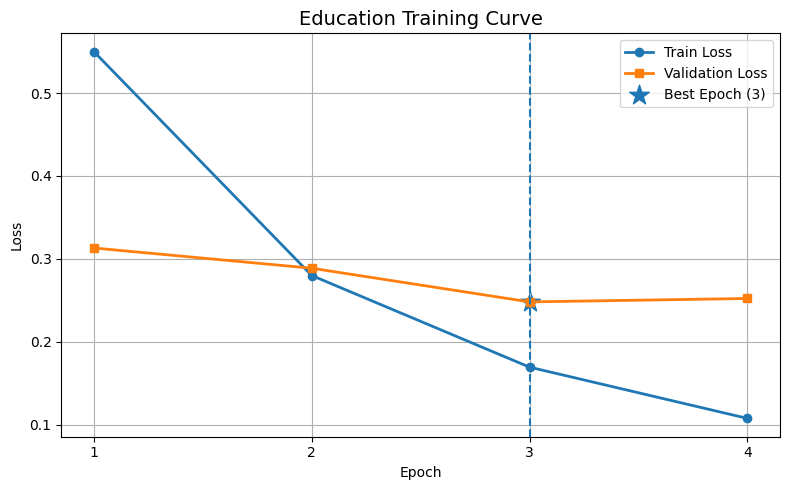

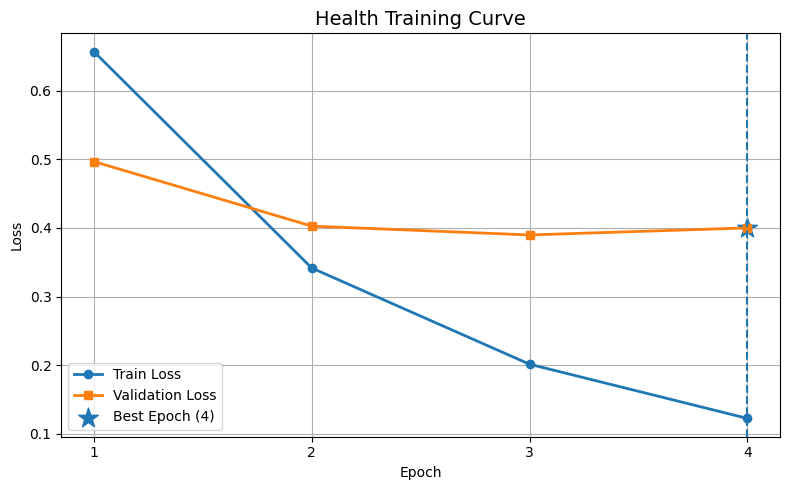

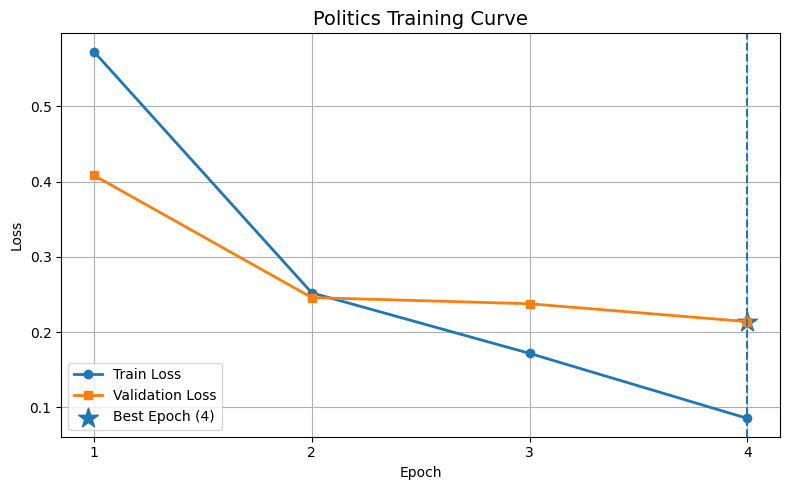

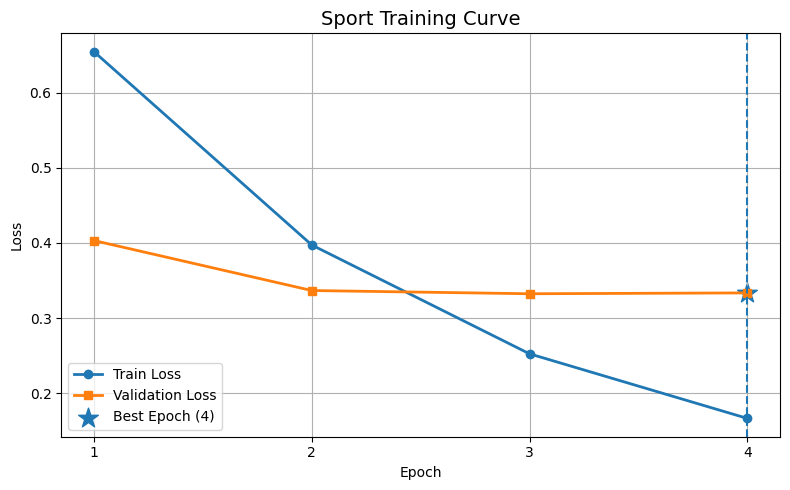

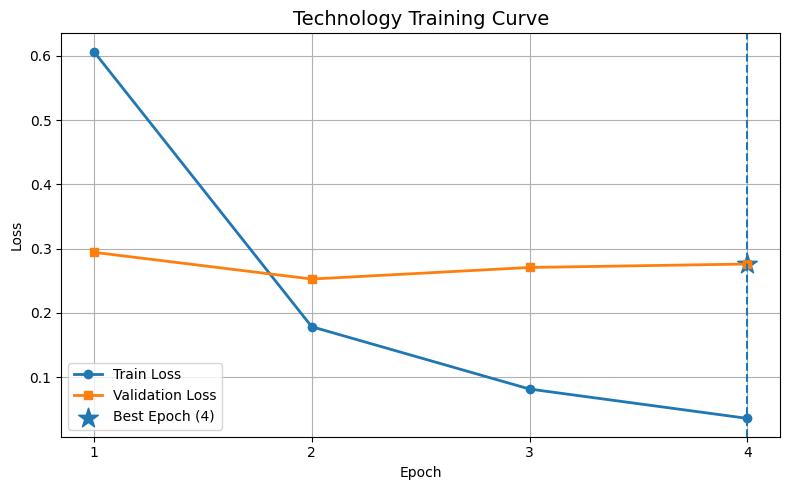

In [ ]:
import json
import matplotlib.pyplot as plt
import os

domains = [
    "Education",
    "Health",
    "Politics",
    "Sport",
    "Technology"
]

# =====================================================
# PLOT TRAINING CURVES
# =====================================================
for domain in domains:
    history_path = os.path.join(
        "/content/drive/MyDrive/thesis/checkpoints",
        "base",
        domain,
        "training_history.json"
    )

    with open(history_path, "r") as f:
        history = json.load(f)

    epochs = history["epochs"]
    train_loss = history["train_loss"]
    val_loss = history["val_loss"]
    macro_f1 = history["val_macro_f1"]

    # Best epoch (highest validation Macro-F1)
    best_epoch_idx = macro_f1.index(max(macro_f1))
    best_epoch = epochs[best_epoch_idx]
    best_val_loss = val_loss[best_epoch_idx]

    # ------------------------------------------------------
    # Plot
    # ------------------------------------------------------
    plt.figure(figsize=(8,5))
    plt.plot(
        epochs,
        train_loss,
        marker="o",
        linewidth=2,
        label="Train Loss"
    )
    plt.plot(
        epochs,
        val_loss,
        marker="s",
        linewidth=2,
        label="Validation Loss"
    )

    # Best epoch marker
    plt.scatter(
        best_epoch,
        best_val_loss,
        marker="*",
        s=220,
        label=f"Best Epoch ({best_epoch})"
    )
    plt.axvline(
        best_epoch,
        linestyle="--",
        linewidth=1.5
    )

    plt.title(f"{domain.capitalize()} Training Curve", fontsize=14)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.xticks(epochs)
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
import os

for domain in ["Education","Health","Politics","Sport","Technology"]:
    ckpt = f"/content/drive/MyDrive/thesis/checkpoints/base/{domain}/best_model.pt"
    print(domain, os.path.exists(ckpt))

Education True
Health True
Politics True
Sport True
Technology True


In [ ]:
# Train all models (base, large, lite) - Use A100 GPU for this
# Uncomment to run:
# !python src/train_pipeline.py \
#     --model all \
#     --dataset-dir dataset \
#     --checkpoint-dir /content/drive/MyDrive/thesis/checkpoints \
#     --output-dir /content/drive/MyDrive/thesis/output \
#     --device cuda \
#     --seed 42

In [ ]:
# Optional: Train with hyperparameter grid search
# !python src/train_pipeline.py \
#     --model base \
#     --dataset-dir dataset \
#     --checkpoint-dir /content/drive/MyDrive/thesis/checkpoints \
#     --output-dir /content/drive/MyDrive/thesis/output \
#     --device cuda \
#     --grid-search \
#     --seed 42

## 4. Model Evaluation

Run comprehensive evaluation including in-domain, cross-domain, and perturbation testing.

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.1 MB/s eta 0:00:00


**USE HIGHEST CONTEXTUAL SIMILARITY**

```
best = max(
          candidates,
          key=lambda x: x["similarity"],
      )
```



In [ ]:
# Evaluate base model with full perturbation testing
# --train-output-dir must match --output-dir used in train_pipeline.py
# so evaluation reuses the exact same test splits the model never saw during training.
!python src/evaluate_pipeline.py \
    --model base \
    --checkpoint-dir /content/drive/MyDrive/thesis/checkpoints \
    --dataset-dir dataset/data \
    --output-dir /content/drive/MyDrive/thesis/results \
    --train-output-dir /content/drive/MyDrive/thesis/outputs/ \
    --device cuda \
    --seed 42 \
    --debug

Streaming output truncated to the last 5000 lines.
Perturbing MEDIUM:  49% 73/150 [00:13<00:14,  5.41it/s]2026-09-02 14:46:21,974 - INFO - DEBUG replacements=2 target_count=2 eligible=2
Perturbing MEDIUM:  49% 74/150 [00:13<00:13,  5.60it/s]2026-09-02 14:46:22,173 - INFO - DEBUG replacements=2 target_count=2 eligible=3
Perturbing MEDIUM:  50% 75/150 [00:13<00:13,  5.42it/s]2026-09-02 14:46:22,524 - INFO - DEBUG replacements=3 target_count=3 eligible=4
Perturbing MEDIUM:  51% 77/150 [00:14<00:13,  5.54it/s]2026-09-02 14:46:22,692 - INFO - DEBUG replacements=2 target_count=2 eligible=3
Perturbing MEDIUM:  52% 78/150 [00:14<00:12,  5.64it/s]2026-09-02 14:46:22,843 - INFO - DEBUG replacements=2 target_count=2 eligible=5
Perturbing MEDIUM:  53% 79/150 [00:14<00:12,  5.87it/s]2026-09-02 14:46:23,139 - INFO - DEBUG replacements=3 target_count=3 eligible=7
Perturbing MEDIUM:  53% 80/150 [00:14<00:14,  4.89it/s]2026-09-02 14:46:23,310 - INFO - DEBUG replacements=1 target_count=1 eligible=1
Pert

In [ ]:
import os
import pandas as pd


# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/content/drive/MyDrive/thesis/results/perturb_data/base"

DOMAINS = [
    "education",
    "health",
    "politics",
    "sport",
    "technology"
]

LEVELS = ["low", "medium", "high"]


# ============================================================
# LOAD DATA
# ============================================================

def load_domain_data(domain):
    domain_dir = os.path.join(BASE_DIR, domain)
    dfs = {}

    for level in LEVELS:
        path = os.path.join(domain_dir, f"{level}.csv")

        if not os.path.exists(path):
            raise FileNotFoundError(f"Missing file: {path}")

        df = pd.read_csv(path)

        if "id" in df.columns:
            df = df.set_index("id")

        dfs[level] = df

    return dfs


# ============================================================
# CLASSIFY TEXT PATTERN
# ============================================================

def classify_perturbation(low_row, medium_row, high_row):

    low_success = bool(low_row["perturbation_in_range"])
    medium_success = bool(medium_row["perturbation_in_range"])
    high_success = bool(high_row["perturbation_in_range"])

    # Any failed level is handled separately.
    if not (low_success and medium_success and high_success):
        return None

    low = str(low_row["perturbed_text"])
    medium = str(medium_row["perturbed_text"])
    high = str(high_row["perturbed_text"])

    low_eq_medium = low == medium
    low_eq_high = low == high
    medium_eq_high = medium == high

    if low_eq_medium and medium_eq_high:
        return "Low = Medium = High"

    if medium_eq_high and not low_eq_medium:
        return "Medium = High != Low"

    if low_eq_medium and not low_eq_high:
        return "Low = Medium != High"

    if low_eq_high and not low_eq_medium:
        return "Low = High != Medium"

    return "Low != Medium != High"


# ============================================================
# ANALYZE ONE DOMAIN
# ============================================================

def analyze_domain(domain):

    dfs = load_domain_data(domain)

    low_df = dfs["low"]
    medium_df = dfs["medium"]
    high_df = dfs["high"]

    common_ids = (
        low_df.index
        .intersection(medium_df.index)
        .intersection(high_df.index)
    )

    if len(common_ids) == 0:
        raise ValueError(
            f"No common samples found for domain: {domain}"
        )

    results = []

    for sample_id in common_ids:

        low_row = low_df.loc[sample_id]
        medium_row = medium_df.loc[sample_id]
        high_row = high_df.loc[sample_id]

        low_success = bool(
            low_row["perturbation_in_range"]
        )

        medium_success = bool(
            medium_row["perturbation_in_range"]
        )

        high_success = bool(
            high_row["perturbation_in_range"]
        )

        pattern = classify_perturbation(
            low_row,
            medium_row,
            high_row
        )

        results.append({
            "id": sample_id,
            "low_success": low_success,
            "medium_success": medium_success,
            "high_success": high_success,
            "pattern": pattern
        })

    return pd.DataFrame(results)


# ============================================================
# RUN ALL DOMAINS
# ============================================================

all_details = {}
all_summaries = []


for domain in DOMAINS:

    detail_df = analyze_domain(domain)

    all_details[domain] = detail_df

    all_summaries.append({
        "domain": domain,
        "total_samples": len(detail_df),

        "low_success": int(
            detail_df["low_success"].sum()
        ),

        "low_failed": int(
            (~detail_df["low_success"]).sum()
        ),

        "medium_success": int(
            detail_df["medium_success"].sum()
        ),

        "medium_failed": int(
            (~detail_df["medium_success"]).sum()
        ),

        "high_success": int(
            detail_df["high_success"].sum()
        ),

        "high_failed": int(
            (~detail_df["high_success"]).sum()
        )
    })


# ============================================================
# FINAL SUMMARY
# ============================================================

summary_df = pd.DataFrame(all_summaries)


# ============================================================
# PRINT: SUCCESS / FAILED PER LEVEL
# ============================================================

print("=" * 80)
print("PERTURBATION SUCCESS / FAILURE BY LEVEL")
print("=" * 80)


for level in LEVELS:

    print("\n" + "-" * 80)
    print(f"{level.upper()} LEVEL")
    print("-" * 80)

    success_col = f"{level}_success"
    failed_col = f"{level}_failed"

    print(
        f"{'Domain':<15}"
        f"{'Success':>12}"
        f"{'Failed':>12}"
        f"{'Total':>12}"
    )

    print("-" * 51)

    for _, row in summary_df.iterrows():

        print(
            f"{row['domain'].upper():<15}"
            f"{row[success_col]:>12}"
            f"{row[failed_col]:>12}"
            f"{row['total_samples']:>12}"
        )

    print("-" * 51)

    print(
        f"{'TOTAL':<15}"
        f"{summary_df[success_col].sum():>12}"
        f"{summary_df[failed_col].sum():>12}"
        f"{summary_df['total_samples'].sum():>12}"
    )


# ============================================================
# SUCCESSFUL TEXT PATTERNS PER DOMAIN
# ============================================================

# ============================================================
# SUCCESSFUL / FAILED PERTURBATION PATTERNS PER DOMAIN
# ============================================================

print("\n\n")
print("=" * 80)
print("PERTURBATION PATTERNS BY DOMAIN")
print("=" * 80)

for domain, detail_df in all_details.items():

    counts = detail_df["pattern"].value_counts()

    # Failed = at least one perturbation level failed
    failed_count = (
        (~detail_df["low_success"])
        | (~detail_df["medium_success"])
        | (~detail_df["high_success"])
    ).sum()

    print("\n" + "-" * 80)
    print(f"DOMAIN: {domain.upper()}")
    print("-" * 80)

    print(
        f"Failed:                     "
        f"{failed_count}"
    )

    print(
        f"Low = Medium = High:       "
        f"{counts.get('Low = Medium = High', 0)}"
    )

    print(
        f"Medium = High != Low:      "
        f"{counts.get('Medium = High != Low', 0)}"
    )

    print(
        f"Low = Medium != High:      "
        f"{counts.get('Low = Medium != High', 0)}"
    )

    print(
        f"Low = High != Medium:      "
        f"{counts.get('Low = High != Medium', 0)}"
    )

    print(
        f"Low != Medium != High:     "
        f"{counts.get('Low != Medium != High', 0)}"
    )


# ============================================================
# FINAL TABLE
# ============================================================

print("\n\n")
print("=" * 80)
print("FINAL SUMMARY TABLE")
print("=" * 80)

print(
    summary_df.to_string(index=False)
)

PERTURBATION SUCCESS / FAILURE BY LEVEL

--------------------------------------------------------------------------------
LOW LEVEL
--------------------------------------------------------------------------------
Domain              Success      Failed       Total
---------------------------------------------------
EDUCATION               142           8         150
HEALTH                  144           6         150
POLITICS                142           8         150
SPORT                   132          18         150
TECHNOLOGY              130          20         150
---------------------------------------------------
TOTAL                   690          60         750

--------------------------------------------------------------------------------
MEDIUM LEVEL
--------------------------------------------------------------------------------
Domain              Success      Failed       Total
---------------------------------------------------
EDUCATION               142           8

In [ ]:
# check
import json

path = "/content/drive/MyDrive/thesis/results/base/complete_evaluation.json"

with open(path, "r", encoding="utf-8") as f:
    results = json.load(f)

# Inspect one perturbation result
for domain, levels in results["perturbation"].items():

    for level, result in levels.items():

        if level == "clean":
            continue

        print("\nDOMAIN:", domain)
        print("LEVEL:", level)

        print(
            "Similarity:",
            result[
                "perturbation_statistics"
            ][
                "semantic_similarity"
            ]
        )

        print(
            "Flip:",
            result.get(
                "prediction_flip"
            )
        )

        break

    break


DOMAIN: Education
LEVEL: low
Similarity: {'count': 144, 'mean': 0.8469828193386396, 'median': 0.8391922414302826, 'std': 0.03380410830589448, 'min': 0.8001872301101685, 'max': 0.9492011070251465}
Flip: {'total_samples': 150, 'successful_perturbations': None, 'flip_count': 4, 'flip_rate': 0.02666666666666667, 'flip_rate_pct': 2.666666666666667, 'flip_0_to_1_count': 2, 'flip_1_to_0_count': 2, 'flip_0_to_1_rate': 0.013333333333333334, 'flip_1_to_0_rate': 0.013333333333333334, 'flip_count_successful_only': None, 'flip_rate_successful_only': None, 'flip_rate_successful_only_pct': None, 'flips': {'correct_to_incorrect': 0, 'incorrect_to_correct': 4, 'correct_to_incorrect_rate': 0.0, 'correct_to_incorrect_rate_pct': 0.0, 'incorrect_to_correct_rate': 0.02666666666666667, 'incorrect_to_correct_rate_pct': 2.666666666666667, 'clean_correct_count': 129, 'clean_incorrect_count': 21, 'correct_to_incorrect_rate_among_correct': 0.0, 'correct_to_incorrect_rate_among_correct_pct': 0.0, 'incorrect_to_co

In [ ]:
import os

# ============================================================
# CONFIG
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/thesis"
MODEL = "base"

# Core directories
RESULTS_ROOT = os.path.join(PROJECT_ROOT, "results")
OUTPUTS_ROOT = os.path.join(PROJECT_ROOT, "outputs")

# Model-specific directories
RESULTS_DIR = os.path.join(RESULTS_ROOT, MODEL)
OUTPUT_DIR = os.path.join(OUTPUTS_ROOT, MODEL, "evaluation_results")

# Files
COMPLETE_EVALUATION_JSON = os.path.join(
    RESULTS_DIR,
    "complete_evaluation.json"
)

CROSS_DOMAIN_PERTURBATION_JSON = os.path.join(
    RESULTS_DIR,
    "cross_domain_perturbation_results.json"
)

EVALUATION_SUMMARY_JSON = os.path.join(
    RESULTS_ROOT,
    "evaluation_summary.json"
)

TRAINING_SUMMARY_JSON = os.path.join(
    OUTPUTS_ROOT,
    "training_summary.json"
)

# Data splits
SPLITS_DIR = os.path.join(
    OUTPUTS_ROOT,
    "data_splits"
)

# Domains / perturbation
DOMAINS = [
    "Education",
    "Health",
    "Politics",
    "Sport",
    "Technology"
]

PERTURB_LEVELS = [
    "clean",
    "low",
    "medium",
    "high"
]

# Metrics
METRICS_TO_PLOT = {
    "macro_f1": "Macro-F1",
    "f1_0": "F1₀ (Non-Clickbait)",
    "f1_1": "F1₁ (Clickbait)"
}

**testing prediction flip**


PREDICTION FLIP ANALYSIS
    domain  level  flip_rate_pct  flip_0_to_1_count  flip_1_to_0_count  correct_to_incorrect  incorrect_to_correct
 Education  clean       0.000000                  0                  0                     0                     0
 Education    low       2.666667                  2                  2                     0                     4
 Education medium       4.666667                  2                  5                     3                     4
 Education   high       3.333333                  2                  3                     1                     4
    Health  clean       0.000000                  0                  0                     0                     0
    Health    low       2.000000                  1                  2                     3                     0
    Health medium       2.666667                  1                  3                     3                     1
    Health   high       4.000000                  2   

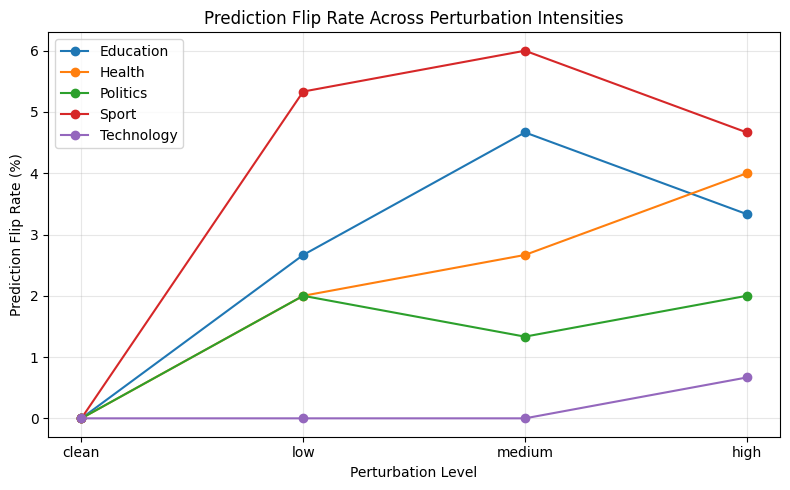

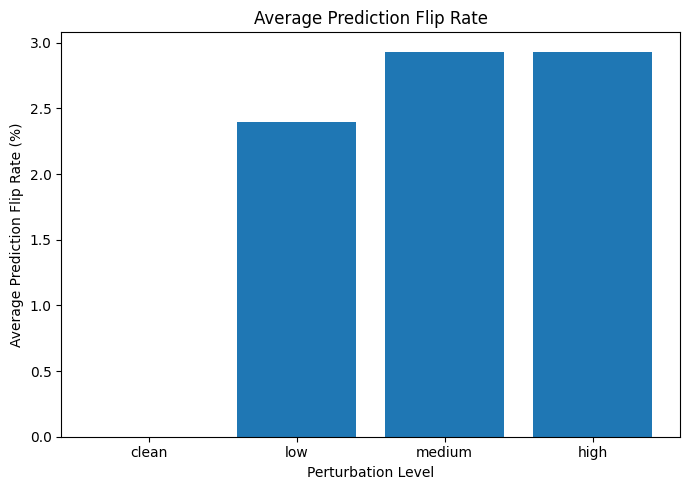

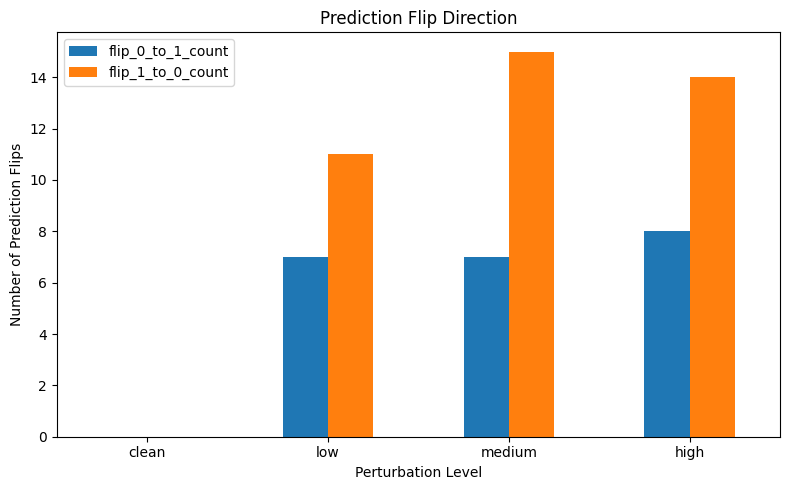

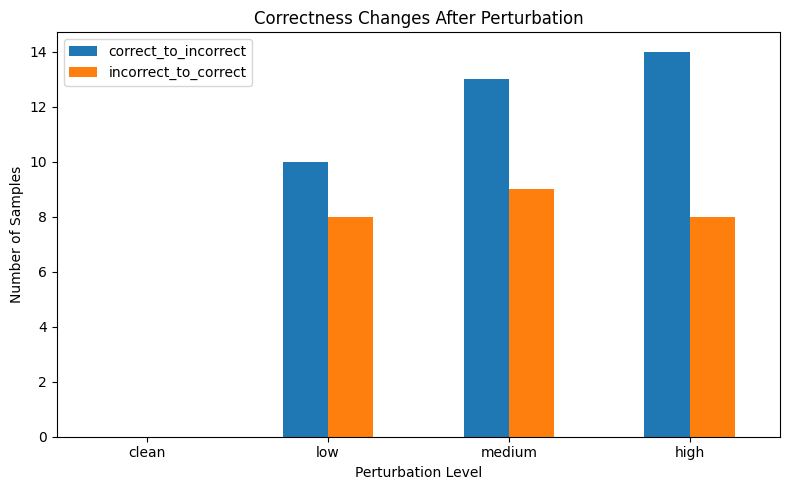

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD JSON
# ============================================================

with open(COMPLETE_EVALUATION_JSON, "r", encoding="utf-8") as f:
    results = json.load(f)


# ============================================================
# EXTRACT PREDICTION FLIP RESULTS
# ============================================================

rows = []

for domain, domain_results in results["perturbation"].items():

    for level in PERTURB_LEVELS:

        if level not in domain_results:
            continue

        flip = domain_results[level].get("prediction_flip", {})

        row = {
            "domain": domain,
            "level": level,

            # Perturbation
            "total_samples": flip.get("total_samples", 0),
            "successful_perturbations":
                flip.get("successful_perturbations", 0),

            # Prediction flip
            "flip_count":
                flip.get("flip_count", 0),

            "flip_rate":
                flip.get("flip_rate", 0),

            "flip_rate_pct":
                flip.get("flip_rate_pct", 0),

            # Direction
            "flip_0_to_1_count":
                flip.get("flip_0_to_1_count", 0),

            "flip_1_to_0_count":
                flip.get("flip_1_to_0_count", 0),

            "flip_0_to_1_rate":
                flip.get("flip_0_to_1_rate", 0),

            "flip_1_to_0_rate":
                flip.get("flip_1_to_0_rate", 0),

            # Successful perturbations only
            "flip_count_successful_only":
                flip.get("flip_count_successful_only", 0),

            "flip_rate_successful_only":
                flip.get("flip_rate_successful_only", 0),

            "flip_rate_successful_only_pct":
                flip.get("flip_rate_successful_only_pct", 0),
        }

        # Correctness-based flip
        flip_correctness = flip.get("flips", {})

        row["correct_to_incorrect"] = flip_correctness.get(
            "correct_to_incorrect", 0
        )

        row["incorrect_to_correct"] = flip_correctness.get(
            "incorrect_to_correct", 0
        )

        rows.append(row)


df = pd.DataFrame(rows)


# ============================================================
# DISPLAY FULL RESULT
# ============================================================

print("\n" + "=" * 80)
print("PREDICTION FLIP ANALYSIS")
print("=" * 80)

print(
    df[
        [
            "domain",
            "level",
            "flip_rate_pct",
            "flip_0_to_1_count",
            "flip_1_to_0_count",
            "correct_to_incorrect",
            "incorrect_to_correct"
        ]
    ].to_string(index=False)
)


# ============================================================
# SAVE CSV
# ============================================================
OUTPUT_CSV = "/content/drive/MyDrive/thesis/results/base/flip.json"
df.to_csv(
    OUTPUT_CSV,
    index=False,
    encoding="utf-8-sig"
)

print(f"\nSaved: {OUTPUT_CSV}")


# ============================================================
# 1. AVERAGE FLIP RATE BY INTENSITY
# ============================================================

avg_by_level = (
    df.groupby("level")
      .agg(
          mean_flip_rate=("flip_rate", "mean"),
          mean_flip_rate_successful=(
              "flip_rate_successful_only",
              "mean"
          ),
          mean_0_to_1=("flip_0_to_1_rate", "mean"),
          mean_1_to_0=("flip_1_to_0_rate", "mean")
      )
      .reindex(PERTURB_LEVELS)
)

print("\n" + "=" * 80)
print("AVERAGE FLIP RATE BY PERTURBATION LEVEL")
print("=" * 80)

print(
    (avg_by_level * 100).round(2).to_string()
)


# ============================================================
# 2. AVERAGE CORRECT → INCORRECT
# ============================================================

correctness_summary = (
    df.groupby("level")
      .agg(
          correct_to_incorrect=("correct_to_incorrect", "sum"),
          incorrect_to_correct=("incorrect_to_correct", "sum"),
          total_flips=("flip_count", "sum")
      )
      .reindex(PERTURB_LEVELS)
)

print("\n" + "=" * 80)
print("PREDICTION FLIP CORRECTNESS")
print("=" * 80)

print(correctness_summary)


# ============================================================
# 3. DOMAIN × LEVEL FLIP RATE TABLE
# ============================================================

pivot_flip = df.pivot(
    index="domain",
    columns="level",
    values="flip_rate_pct"
)

pivot_flip = pivot_flip.reindex(columns=PERTURB_LEVELS)

print("\n" + "=" * 80)
print("FLIP RATE (%) — DOMAIN × PERTURBATION LEVEL")
print("=" * 80)

print(pivot_flip.round(2))


# ============================================================
# 4. DOMAIN × LEVEL SUCCESSFUL-ONLY FLIP RATE
# ============================================================

pivot_successful = df.pivot(
    index="domain",
    columns="level",
    values="flip_rate_successful_only_pct"
)

pivot_successful = pivot_successful.reindex(columns=PERTURB_LEVELS)

print("\n" + "=" * 80)
print("FLIP RATE AMONG SUCCESSFUL PERTURBATIONS (%)")
print("=" * 80)

print(pivot_successful.round(2))


# ============================================================
# 5. CHECK MONOTONICITY
# ============================================================

print("\n" + "=" * 80)
print("FLIP RATE CHANGE BY INTENSITY")
print("=" * 80)

for domain in pivot_flip.index:

    low = pivot_flip.loc[domain, "low"]
    medium = pivot_flip.loc[domain, "medium"]
    high = pivot_flip.loc[domain, "high"]

    print(
        f"{domain:15s} "
        f"Low={low:.2f}% | "
        f"Medium={medium:.2f}% | "
        f"High={high:.2f}%"
    )


# ============================================================
# 6. PLOT — FLIP RATE BY INTENSITY
# ============================================================

plt.figure(figsize=(8, 5))

for domain in pivot_flip.index:
    plt.plot(
        PERTURB_LEVELS,
        pivot_flip.loc[domain],
        marker="o",
        label=domain
    )

plt.xlabel("Perturbation Level")
plt.ylabel("Prediction Flip Rate (%)")
plt.title("Prediction Flip Rate Across Perturbation Intensities")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


# ============================================================
# 7. PLOT — AVERAGE FLIP RATE
# ============================================================

plt.figure(figsize=(7, 5))

plt.bar(
    PERTURB_LEVELS,
    avg_by_level["mean_flip_rate"] * 100
)

plt.xlabel("Perturbation Level")
plt.ylabel("Average Prediction Flip Rate (%)")
plt.title("Average Prediction Flip Rate")

plt.tight_layout()
plt.show()


# ============================================================
# 8. PLOT — FLIP DIRECTION
# ============================================================

direction = (
    df.groupby("level")[
        [
            "flip_0_to_1_count",
            "flip_1_to_0_count"
        ]
    ]
    .sum()
    .reindex(PERTURB_LEVELS)
)

direction.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Perturbation Level")
plt.ylabel("Number of Prediction Flips")
plt.title("Prediction Flip Direction")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()


# ============================================================
# 9. PLOT — CORRECT → INCORRECT
# ============================================================

correctness_plot = (
    df.groupby("level")[
        [
            "correct_to_incorrect",
            "incorrect_to_correct"
        ]
    ]
    .sum()
    .reindex(PERTURB_LEVELS)
)

correctness_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Perturbation Level")
plt.ylabel("Number of Samples")
plt.title("Correctness Changes After Perturbation")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [ ]:
for domain, domain_results in results["perturbation"].items():

    print("\n" + "=" * 80)
    print(domain.upper())
    print("=" * 80)

    for level in PERTURB_LEVELS:

        if level not in domain_results:
            continue

        flip = domain_results[level].get(
            "prediction_flip",
            {}
        )

        print(f"\n{level.upper()}")
        print("successful_perturbations:",
              flip.get("successful_perturbations"))

        print("flip_count_successful_only:",
              flip.get("flip_count_successful_only"))

        print("flip_rate_successful_only:",
              flip.get("flip_rate_successful_only"))

        print("flip_rate_successful_only_pct:",
              flip.get("flip_rate_successful_only_pct"))


EDUCATION

CLEAN
successful_perturbations: None
flip_count_successful_only: None
flip_rate_successful_only: None
flip_rate_successful_only_pct: None

LOW
successful_perturbations: 142
flip_count_successful_only: 4
flip_rate_successful_only: 0.028169014084507043
flip_rate_successful_only_pct: 2.8169014084507045

MEDIUM
successful_perturbations: 142
flip_count_successful_only: 7
flip_rate_successful_only: 0.04929577464788732
flip_rate_successful_only_pct: 4.929577464788732

HIGH
successful_perturbations: 142
flip_count_successful_only: 5
flip_rate_successful_only: 0.035211267605633804
flip_rate_successful_only_pct: 3.5211267605633805

HEALTH

CLEAN
successful_perturbations: None
flip_count_successful_only: None
flip_rate_successful_only: None
flip_rate_successful_only_pct: None

LOW
successful_perturbations: 144
flip_count_successful_only: 3
flip_rate_successful_only: 0.020833333333333332
flip_rate_successful_only_pct: 2.083333333333333

MEDIUM
successful_perturbations: 145
flip_count_s

In [ ]:
# Quick evaluation (skip perturbation testing for faster results)
# !python src/evaluate_pipeline.py \
#     --model base \
#     --checkpoint-dir /content/drive/MyDrive/thesis/checkpoints \
#     --dataset-dir dataset/data \
#     --output-dir /content/drive/MyDrive/thesis/results \
#     --train-output-dir /content/drive/MyDrive/thesis/output \
#     --device cuda \
#     --skip-perturbation \
#     --seed 42

In [ ]:
# Evaluate all models (if you trained all)
# !python src/evaluate_pipeline.py \
#     --model all \
#     --checkpoint-dir /content/drive/MyDrive/thesis/checkpoints \
#     --dataset-dir dataset/data \
#     --output-dir /content/drive/MyDrive/thesis/results \
#     --train-output-dir /content/drive/MyDrive/thesis/output \
#     --device cuda \
#     --seed 42

## **Perturbation Check**

In [ ]:
# ── INPUT: clean test text  |  OUTPUT: perturbed text per level ──────────────
import sys
sys.path.insert(0, "/content/domain-shift-trustworthy-ai/src")

import pandas as pd
from perturbation_engine import PerturbationEngine

engine = PerturbationEngine(thesaurus_path="/content/dict.json",random_seed=42)

# Pick 3 samples from the Technology test split for a concrete demonstration
test_df = pd.read_csv(f"{SPLITS_DIR}/technology/test.csv")
samples = test_df.sample(n=3, random_state=0)["text"].tolist()

SEP = "═" * 80
for i, original in enumerate(samples):
    low    = engine.apply_perturbation(original, "low")
    medium = engine.apply_perturbation(original, "medium")
    high   = engine.apply_perturbation(original, "high")

    # Compute simple char-change ratio
    def change_ratio(a, b):
        return sum(x != y for x, y in zip(a, b)) / max(len(a), 1)

    print(f"\n{SEP}")
    print(f"Sample {i+1}")
    print(f"{SEP}")
    print(f"  ORIGINAL  : {original}")
    print(f"  LOW       : {low}")
    print(f"             char-change = {change_ratio(original, low):.1%}")
    print(f"  MEDIUM    : {medium}")
    print(f"             char-change = {change_ratio(original, medium):.1%}")
    print(f"  HIGH      : {high}")
    print(f"             char-change = {change_ratio(original, high):.1%}")
print(SEP)

**Perturbation Intensity Validation**

In [ ]:
# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/content/drive/MyDrive/thesis/results/perturb_data/base"

DOMAINS = [
    "education",
    "health",
    "politics",
    "sport",
    "technology"
]

LEVELS = [
    "low",
    "medium",
    "high"
]


# ============================================================
# WORD-LEVEL CHANGE CALCULATION
# ============================================================

def calculate_word_changes(original, perturbed):
    """
    Calculate actual word changes using position-based comparison.

    Example:
        original  = "A B C D"
        perturbed = "A X C Y"

        changed words = 2
        ratio = 2 / 4 = 0.50
    """

    original_words = str(original).split()
    perturbed_words = str(perturbed).split()

    original_count = len(original_words)

    if original_count == 0:
        return {
            "actual_replacements": 0,
            "actual_ratio": 0.0
        }

    max_len = max(
        len(original_words),
        len(perturbed_words)
    )

    changed_words = sum(
        1
        for i in range(max_len)
        if (
            i >= len(original_words)
            or i >= len(perturbed_words)
            or original_words[i] != perturbed_words[i]
        )
    )

    ratio = changed_words / original_count

    return {
        "actual_replacements": changed_words,
        "actual_ratio": ratio
    }


# ============================================================
# PROCESS ONE FILE
# ============================================================

def analyze_file(path, domain, level):

    df = pd.read_csv(path)

    required_columns = [
        "original_text",
        "perturbed_text",
        "perturbation_in_range"
    ]

    missing = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing:
        raise ValueError(
            f"{path} is missing columns: {missing}"
        )

    actual_replacements = []
    actual_ratios = []

    for _, row in df.iterrows():

        result = calculate_word_changes(
            row["original_text"],
            row["perturbed_text"]
        )

        actual_replacements.append(
            result["actual_replacements"]
        )

        actual_ratios.append(
            result["actual_ratio"]
        )

    df["actual_replacements_calculated"] = actual_replacements
    df["actual_ratio_calculated"] = actual_ratios

    # --------------------------------------------------------
    # SUCCESS / FAILURE
    # --------------------------------------------------------

    successful = df["perturbation_in_range"].astype(bool)

    successful_df = df[successful].copy()

    total_samples = len(df)

    successful_samples = int(successful.sum())

    unchanged_samples = total_samples - successful_samples

    # Only analyze successfully perturbed samples
    # for actual perturbation intensity.
    ratios = successful_df[
        "actual_ratio_calculated"
    ]

    replacements = successful_df[
        "actual_replacements_calculated"
    ]

    # --------------------------------------------------------
    # SUMMARY
    # --------------------------------------------------------

    summary = {
        "domain": domain.capitalize(),
        "level": level.capitalize(),

        "total_samples": total_samples,

        "successful_samples": successful_samples,

        "success_rate": (
            successful_samples / total_samples
            if total_samples > 0
            else 0
        ),

        "unchanged_samples": unchanged_samples,

        "unchanged_rate": (
            unchanged_samples / total_samples
            if total_samples > 0
            else 0
        ),

        "mean_actual_replacements": (
            replacements.mean()
            if len(replacements) > 0
            else np.nan
        ),

        "median_actual_replacements": (
            replacements.median()
            if len(replacements) > 0
            else np.nan
        ),

        "mean_actual_ratio": (
            ratios.mean()
            if len(ratios) > 0
            else np.nan
        ),

        "median_actual_ratio": (
            ratios.median()
            if len(ratios) > 0
            else np.nan
        ),

        "min_actual_ratio": (
            ratios.min()
            if len(ratios) > 0
            else np.nan
        ),

        "max_actual_ratio": (
            ratios.max()
            if len(ratios) > 0
            else np.nan
        )
    }

    return summary, df


# ============================================================
# RUN ALL DOMAINS / LEVELS
# ============================================================

all_summaries = []
all_distributions = []

for domain in DOMAINS:

    for level in LEVELS:

        path = os.path.join(
            BASE_DIR,
            domain,
            f"{level}.csv"
        )

        if not os.path.exists(path):
            print(f"WARNING: File not found: {path}")
            continue

        summary, df = analyze_file(
            path,
            domain,
            level
        )

        all_summaries.append(summary)

        # ----------------------------------------------------
        # Distribution
        # ----------------------------------------------------

        successful_df = df[
            df["perturbation_in_range"].astype(bool)
        ]

        for ratio in successful_df[
            "actual_ratio_calculated"
        ]:

            all_distributions.append({
                "domain": domain.capitalize(),
                "level": level.capitalize(),
                "actual_ratio": ratio,
                "actual_ratio_pct": ratio * 100
            })

        print(
            f"Loaded {domain:<12} "
            f"{level:<7} "
            f"{len(df)} samples"
        )


# ============================================================
# SUMMARY DATAFRAME
# ============================================================

summary_df = pd.DataFrame(all_summaries)

print("\n")
print("=" * 110)
print("ACTUAL PERTURBATION INTENSITY SUMMARY")
print("=" * 110)

print(
    summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# DISTRIBUTION SUMMARY
# ============================================================

distribution_df = pd.DataFrame(
    all_distributions
)

distribution_summary = (
    distribution_df
    .groupby(["domain", "level"])["actual_ratio_pct"]
    .describe()
    .reset_index()
)

print("\n")
print("=" * 110)
print("ACTUAL REPLACEMENT RATIO DISTRIBUTION")
print("=" * 110)

print(
    distribution_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)


# ============================================================
# INTENSITY ORDER CHECK
# ============================================================

print("\n")
print("=" * 100)
print("INTENSITY CHECK: LOW < MEDIUM < HIGH")
print("=" * 100)

intensity = (
    summary_df
    .pivot(
        index="domain",
        columns="level",
        values="mean_actual_ratio"
    )
)

intensity["Low < Medium"] = (
    intensity["Low"] < intensity["Medium"]
)

intensity["Medium < High"] = (
    intensity["Medium"] < intensity["High"]
)

intensity["Low < Medium < High"] = (
    intensity["Low"]
    < intensity["Medium"]
) & (
    intensity["Medium"]
    < intensity["High"]
)

print(
    intensity.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# SUCCESS-ONLY INTENSITY DIFFERENCE
# ============================================================

print("\n")
print("=" * 100)
print("PAIRWISE INTENSITY DIFFERENCES")
print("=" * 100)

for domain in intensity.index:

    low = intensity.loc[domain, "Low"]
    medium = intensity.loc[domain, "Medium"]
    high = intensity.loc[domain, "High"]

    print(f"\n{domain}")

    print(
        f"  Low    : {low * 100:.2f}%"
    )

    print(
        f"  Medium : {medium * 100:.2f}%"
    )

    print(
        f"  High   : {high * 100:.2f}%"
    )

    print(
        f"  Medium - Low : "
        f"{(medium - low) * 100:+.2f} percentage points"
    )

    print(
        f"  High - Medium: "
        f"{(high - medium) * 100:+.2f} percentage points"
    )

    print(
        f"  High - Low   : "
        f"{(high - low) * 100:+.2f} percentage points"
    )


# ============================================================
# SAVE RESULTS
# ============================================================

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "perturbation_validation"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

summary_path = os.path.join(
    OUTPUT_DIR,
    "actual_intensity_summary.csv"
)

distribution_path = os.path.join(
    OUTPUT_DIR,
    "actual_intensity_distribution.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)

distribution_df.to_csv(
    distribution_path,
    index=False
)

print("\n")
print("=" * 100)
print("SAVED FILES")
print("=" * 100)

print(
    f"Summary:\n{summary_path}"
)

print(
    f"\nDistribution:\n{distribution_path}"
)

Loaded education    low     150 samples
Loaded education    medium  150 samples
Loaded education    high    150 samples
Loaded health       low     150 samples
Loaded health       medium  150 samples
Loaded health       high    150 samples
Loaded politics     low     150 samples
Loaded politics     medium  150 samples
Loaded politics     high    150 samples
Loaded sport        low     150 samples
Loaded sport        medium  150 samples
Loaded sport        high    150 samples
Loaded technology   low     150 samples
Loaded technology   medium  150 samples
Loaded technology   high    150 samples


ACTUAL PERTURBATION INTENSITY SUMMARY
    domain  level  total_samples  successful_samples  success_rate  unchanged_samples  unchanged_rate  mean_actual_replacements  median_actual_replacements  mean_actual_ratio  median_actual_ratio  min_actual_ratio  max_actual_ratio
 Education    Low            150                 142        0.9467                  8          0.0533                    1.3099 

## **Inspect In-Domain Evaluation — Inputs and Outputs**

Loads the saved evaluation results and shows, for each domain specialist:
the test texts going in, the predicted labels coming out, and the per-domain metrics.

In [ ]:
# ── INPUT: test texts + true labels  |  OUTPUT: predictions + metrics ─────────
import json, pandas as pd


# RESULTS_DIR = "/content/drive/MyDrive/thesis/results/base"
# SPLITS_DIR  = "/content/drive/MyDrive/thesis/outputs/data_splits"

with open(COMPLETE_EVALUATION_JSON, "r") as f:
    ev = json.load(f)

SEP = "─" * 80
print("IN-DOMAIN EVALUATION — inputs and predicted outputs")
print(SEP)
print(f"{'Domain':<14} {'N':>5}  {'Acc':>7}  {'MacroF1':>8}  {'F1-CB':>7}  {'FP':>5}  {'FN':>5}")
print(SEP)

for domain, data in ev["in_domain"].items():
    m  = data["metrics"]
    cm = m.get("confusion_matrix", [[0,0],[0,0]])
    print(f"{domain:<14} {data['num_samples']:>5}  "
          f"{m['accuracy']:>7.4f}  {m['macro_f1']:>8.4f}  "
          f"{m.get('f1_1', m.get('f1_1', 0)):>7.4f}  "
          f"{cm[0][1]:>5}  {cm[1][0]:>5}")

# Show 4 concrete prediction examples for Education
print(f"\n── Sample predictions: Education specialist on Education test set ──")
edu_test = pd.read_csv(f"{SPLITS_DIR}/education/test.csv")
edu_data = ev["in_domain"].get("Education", {})
preds    = edu_data.get("predictions", [])
trues    = edu_data.get("true_labels", [])
texts    = edu_test["text"].tolist()

print(f"  {'True':>13}  {'Pred':>13}  Text")
print(f"  {'─'*13}  {'─'*13}  {'─'*50}")
count = 0
for txt, true, pred in zip(texts, trues, preds):
    label_t = "clickbait" if true == 1 else "non-clickbait"
    label_p = "clickbait" if pred == 1 else "non-clickbait"
    mark = "  ✗" if true != pred else ""
    print(f"  {label_t:>13}  {label_p:>13}  {str(txt)[:60]}{mark}")
    count += 1
    if count >= 6:
        break

IN-DOMAIN EVALUATION — inputs and predicted outputs
────────────────────────────────────────────────────────────────────────────────
Domain             N      Acc   MacroF1    F1-CB     FP     FN
────────────────────────────────────────────────────────────────────────────────
Education        150   0.8600    0.8487   0.8073     13      8
Health           150   0.8733    0.8669   0.8376     12      7
Politics         150   0.9400    0.8902   0.8163      1      8
Sport            150   0.8267    0.7292   0.5667      7     19
Technology       150   0.9533    0.9327   0.8955      3      4

── Sample predictions: Education specialist on Education test set ──
           True           Pred  Text
  ─────────────  ─────────────  ──────────────────────────────────────────────────
  non-clickbait  non-clickbait  Beasiswa Telkom University untuk Maba 2026, Bisa Kuliah Grat
  non-clickbait  non-clickbait  Usai Sidang Tuntutan Hari Ini, Eks Mendikbud Nadiem Langsung
  non-clickbait  non-clickbait  

## **Inspect Cross-Domain Evaluation — Source Model on Target Texts**

Shows which source-domain specialist was used, what target-domain texts it received,
and how its predictions compare to the target specialist's in-domain performance.

In [ ]:
# ── INPUT: source specialist + target test texts  |  OUTPUT: metrics + shift ──
import json

with open(COMPLETE_EVALUATION_JSON, "r") as f:
    ev = json.load(f)

# ── Cross-domain performance matrix ──
cd = ev["cross_domain"]

print("CROSS-DOMAIN Macro-F1  (row = source specialist, col = target test set)")
print(f"{'Source':<12}", end="")
for d in domains:
    print(f"  {d[:9]:>9}", end="")
print()
print("-" * 65)
for src in domains:
    print(f"{src:<12}", end="")
    for tgt in domains:
        key = f"{src}->{tgt}"
        f1  = cd.get(key, {}).get("metrics", {}).get("macro_f1", 0.0)
        marker = "◆" if src == tgt else " "
        print(f"  {f1:>8.4f}{marker}", end="")
    print()

# ── Concrete example: Technology specialist predicting Health test set ──
print("\n── Example: Technology specialist applied to Health test texts ──")
key = "Technology->Health"
cd_data = cd.get(key, {})
preds   = cd_data.get("predictions", [])
trues   = cd_data.get("true_labels", [])
shift   = cd_data.get("domain_shift", {})

health_test = pd.read_csv(f"{SPLITS_DIR}/health/test.csv")
texts       = health_test["text"].tolist()

mf1_src = ev["in_domain"].get("Technology", {}).get("metrics", {}).get("macro_f1", 0)
mf1_tgt = ev["in_domain"].get("Health",     {}).get("metrics", {}).get("macro_f1", 0)
mf1_cd  = cd_data.get("metrics", {}).get("macro_f1", 0)
print(f"  Technology in-domain F1 : {mf1_src:.4f}")
print(f"  Health in-domain F1     : {mf1_tgt:.4f}")
print(f"  Technology→Health F1    : {mf1_cd:.4f}")
print(f"  Source Drop (SD)        : {shift.get('sd_macro_f1', 0):+.4f}")
print(f"  Target Drop (TD)        : {shift.get('td_macro_f1', 0):+.4f}")

print(f"\n  {'True':>13}  {'Pred':>13}  Health headline")
print(f"  {'─'*13}  {'─'*13}  {'─'*50}")
count = 0
for txt, true, pred in zip(texts, trues, preds):
    label_t = "clickbait" if true == 1 else "non-clickbait"
    label_p = "clickbait" if pred == 1 else "non-clickbait"
    mark = "  ✗" if true != pred else ""
    print(f"  {label_t:>13}  {label_p:>13}  {str(txt)[:55]}{mark}")
    count += 1
    if count >= 6:
        break

CROSS-DOMAIN Macro-F1  (row = source specialist, col = target test set)
Source        Education     Health   Politics      Sport  Technolog
-----------------------------------------------------------------
Education       0.8487◆    0.6680     0.6843     0.5122     0.8479 
Health          0.8845     0.8669◆    0.7071     0.4605     0.9206 
Politics        0.7943     0.7066     0.8902◆    0.6161     0.8062 
Sport           0.7563     0.6518     0.6565     0.7292◆    0.7650 
Technology      0.8869     0.7778     0.6987     0.5137     0.9327◆

── Example: Technology specialist applied to Health test texts ──
  Technology in-domain F1 : 0.9327
  Health in-domain F1     : 0.8669
  Technology→Health F1    : 0.7778
  Source Drop (SD)        : +0.1550
  Target Drop (TD)        : +0.0891

           True           Pred  Health headline
  ─────────────  ─────────────  ──────────────────────────────────────────────────
  non-clickbait  non-clickbait  5 Makanan yang Bikin Gairah Seks Pasutri Makin

## 5. View Results

In [ ]:
# Print evaluation summary + error analysis
# --results-dir must point to the model subfolder (results/base, results/large, etc.)
# because evaluate_pipeline.py saves complete_evaluation.json inside results/{model}/
!python src/print_evaluation_summary.py \
    --results-dir /content/drive/MyDrive/thesis/results/ \
    --model base


════════════════════════════════════════════════════════════════════════════════
════════════════════════════════════════════════════════════════════════════════
                        EVALUATION SUMMARY  ·  MODEL: BASE
════════════════════════════════════════════════════════════════════════════════
════════════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════════════
══════════════ 1. IN-DOMAIN PERFORMANCE (Specialist → Own Domain) ══════════════
════════════════════════════════════════════════════════════════════════════════
Domain           Accuracy   Macro_F1Macro-PrecisionMacro-Recall        MCC    ROC-AUC
────────────────────────────────────────────────────────────────────────────────
Education          0.8600     0.8487     0.8430     0.8568     0.6996     0.9345
Health             0.8733     0.8669     0.8623     0.8737     0.7359     0.9282
Politics           0.9400     0.8902     0.

In [ ]:
from pathlib import Path

root = Path("/content/drive/MyDrive/thesis/checkpoints/base")
print ("drive folder")
for domain in ["Education", "Health", "Politics", "Sport", "Technology"]:
    domain_dir = root / domain

    print(f"\n{domain}")
    for f in domain_dir.iterdir():
        print(f"  {f.name}: {f.stat().st_size / 1024**2:.2f} MB")


root = Path("/content/checkpoints_staging")
print ("local not connect to drive")
for domain in ["Education", "Health", "Politics", "Sport", "Technology"]:
    domain_dir = root / "base" / domain # Changed to use Path object concatenation

    print(f"\n{domain}")
    for f in domain_dir.iterdir():
        print(f"  {f.name}: {f.stat().st_size / 1024**2:.2f} MB")

drive folder

Education
  best_model_history.json: 0.00 MB
  best_model.pt: 1419.87 MB
  training_history.json: 0.00 MB

Health
  training_history.json: 0.00 MB
  best_model.pt: 1419.87 MB
  best_model_history.json: 0.00 MB

Politics
  training_history.json: 0.00 MB
  best_model.pt: 1419.87 MB
  best_model_history.json: 0.00 MB

Sport
  training_history.json: 0.00 MB
  best_model.pt: 1419.87 MB
  best_model_history.json: 0.00 MB

Technology
  best_model_history.json: 0.00 MB
  best_model.pt: 1419.87 MB
  training_history.json: 0.00 MB
local not connect to drive

Education
  training_history.json: 0.00 MB
  best_model.pt: 1419.87 MB
  best_model_history.json: 0.00 MB

Health
  training_history.json: 0.00 MB
  best_model.pt: 1419.87 MB
  best_model_history.json: 0.00 MB

Politics
  training_history.json: 0.00 MB
  best_model.pt: 1419.87 MB
  best_model_history.json: 0.00 MB

Sport
  training_history.json: 0.00 MB
  best_model.pt: 1419.87 MB
  best_model_history.json: 0.00 MB

Technology


In [ ]:
import json
import os

# history_path = os.path.join(
#     "/content/drive/MyDrive/thesis/results",
#     "base",
#     "complete_evaluation.json"
# )

# with open(history_path, "r") as f:
#     data = json.load(f)

# DOMAINS = ["Education", "Health", "Politics", "Sport", "Technology"]
# PERTURB_LEVELS = ["clean", "low", "medium", "high"]

with open(COMPLETE_EVALUATION_JSON, "r") as f:
    data = json.load(f)

DOMAINS = list(data["in_domain"].keys())

PERTURB_LEVELS = [
    "clean",
    "low",
    "medium",
    "high"
]
# ─────────────────────────────────────────────
# 1. IN-DOMAIN
# ─────────────────────────────────────────────
print("=" * 65)
print("  1. IN-DOMAIN — F1 per Class")
print("=" * 65)
print(f"{'Domain':<14} {'F1_0':>8} {'F1_1':>8} {'Macro_F1':>10}")
print("-" * 65)
for domain in DOMAINS:
    m = data["in_domain"][domain]["metrics"]
    print(f"{domain:<14} {m['f1_0']:>8.4f} {m['f1_1']:>8.4f} {m['macro_f1']:>10.4f}")

# ─────────────────────────────────────────────
# 2. CROSS-DOMAIN
# ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("  2. CROSS-DOMAIN — F1_0 Matrix (Row=Source, Col=Target)")
print("=" * 65)

header = f"{'Source':<14}" + "".join(f"{d[:6]:>10}" for d in DOMAINS)
print(header)
print("-" * 65)

for src in DOMAINS:
    row = f"{src:<14}"
    for tgt in DOMAINS:
        try:
            key = f"{src}->{tgt}"
            m = data["cross_domain"][key]["metrics"]

            marker = "◆" if src == tgt else " "
            row += f"{m['f1_0']:>9.4f}{marker}"

        except KeyError:
            row += f"{'N/A':>10}"

    print(row)


print("\n" + "=" * 65)
print("  2. CROSS-DOMAIN — F1_1 Matrix (Row=Source, Col=Target)")
print("=" * 65)

print(header)
print("-" * 65)

for src in DOMAINS:
    row = f"{src:<14}"
    for tgt in DOMAINS:
        try:
            key = f"{src}->{tgt}"
            m = data["cross_domain"][key]["metrics"]

            marker = "◆" if src == tgt else " "
            row += f"{m['f1_1']:>9.4f}{marker}"

        except KeyError:
            row += f"{'N/A':>10}"

    print(row)

# ─────────────────────────────────────────────
# 3. PERTURBATION
# ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("  3. PERTURBATION — F1_0 and F1_1 per Domain per Level")
print("=" * 65)
for domain in DOMAINS:
    print(f"\n  [{domain}]")
    print(f"  {'Level':<10} {'F1_0':>8} {'F1_1':>8} {'Macro_F1':>10}")
    print(f"  {'-'*38}")
    for level in PERTURB_LEVELS:
        try:
            m = data["perturbation"][domain][level]["metrics"]
            print(f"  {level:<10} {m['f1_0']:>8.4f} {m['f1_1']:>8.4f} {m['macro_f1']:>10.4f}")
        except KeyError:
            print(f"  {level:<10} {'N/A':>8} {'N/A':>8} {'N/A':>10}")

  1. IN-DOMAIN — F1 per Class
Domain             F1_0     F1_1   Macro_F1
-----------------------------------------------------------------
Education        0.8901   0.8073     0.8487
Health           0.8962   0.8376     0.8669
Politics         0.9641   0.8163     0.8902
Sport            0.8917   0.5667     0.7292
Technology       0.9700   0.8955     0.9327

  2. CROSS-DOMAIN — F1_0 Matrix (Row=Source, Col=Target)
Source            Educat    Health    Politi     Sport    Techno
-----------------------------------------------------------------
Education        0.8901◆   0.7101    0.9242    0.8504    0.9310 
Health           0.9268    0.8962◆   0.9278    0.8669    0.9661 
Politics         0.8670    0.7105    0.9641◆   0.8618    0.9018 
Sport            0.8066    0.6286    0.7962    0.8917◆   0.8716 
Technology       0.9254    0.8000    0.9237    0.8736    0.9700◆

  2. CROSS-DOMAIN — F1_1 Matrix (Row=Source, Col=Target)
Source            Educat    Health    Politi     Sport    Techno
---

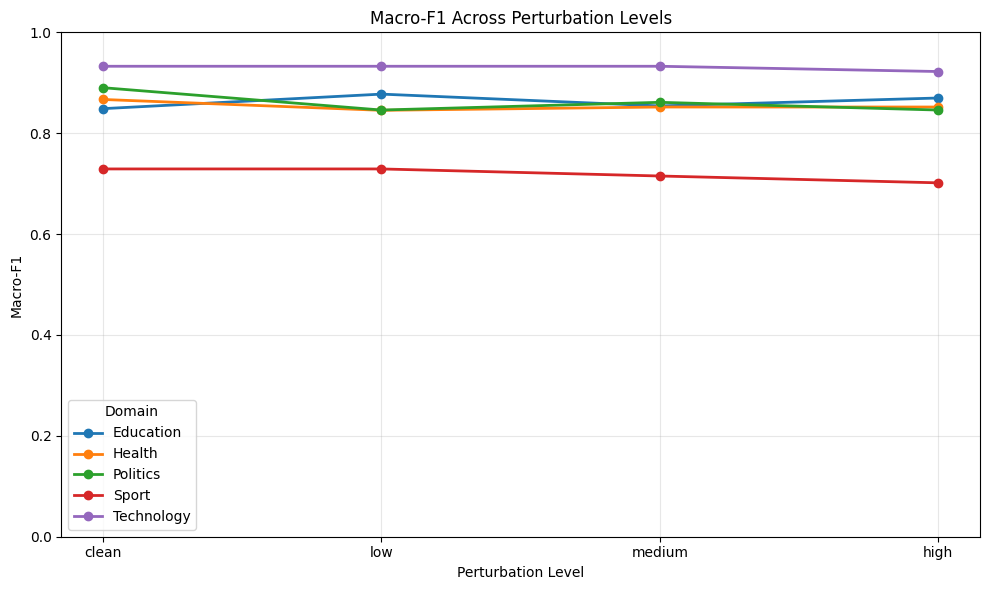

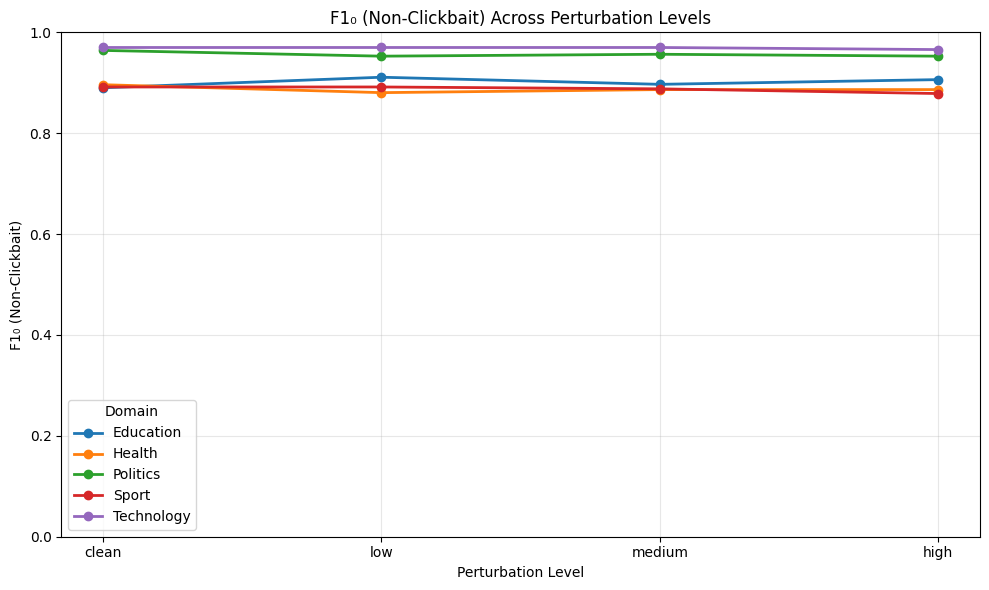

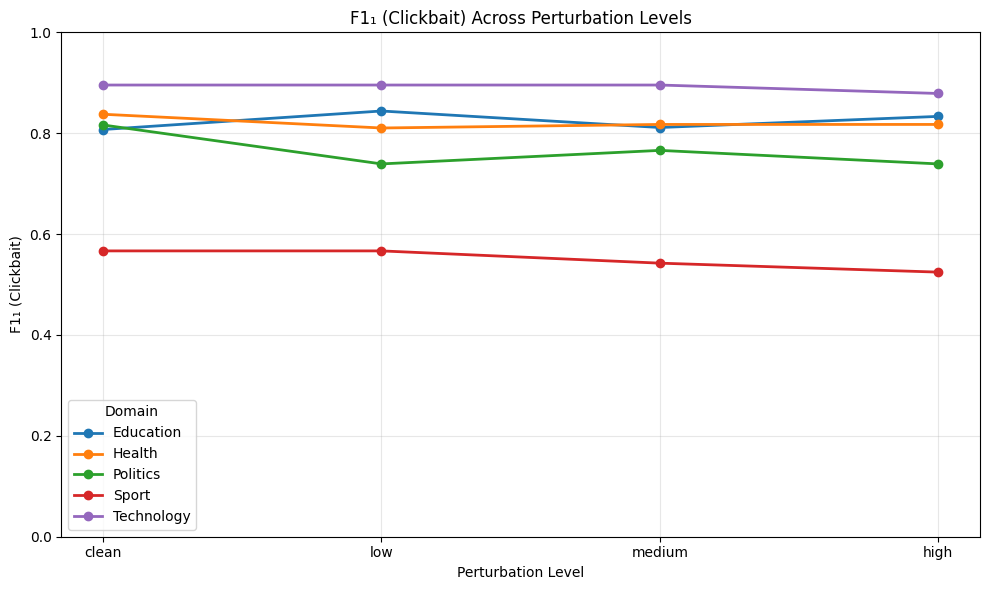

In [ ]:
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# 4. PERTURBATION LINE CHARTS
# ─────────────────────────────────────────────


# Metrics to plot
metrics_to_plot = {
    "macro_f1": "Macro-F1",
    "f1_0": "F1₀ (Non-Clickbait)",
    "f1_1": "F1₁ (Clickbait)"
}

for metric_key, metric_name in metrics_to_plot.items():

    plt.figure(figsize=(10, 6))

    for domain in DOMAINS:
        values = []

        for level in PERTURB_LEVELS:
            try:
                value = data["perturbation"][domain][level]["metrics"][metric_key]
                values.append(value)
            except KeyError:
                values.append(None)

        plt.plot(
            PERTURB_LEVELS,
            values,
            marker="o",
            linewidth=2,
            label=domain
        )

    plt.xlabel("Perturbation Level")
    plt.ylabel(metric_name)
    plt.title(f"{metric_name} Across Perturbation Levels")
    plt.ylim(0, 1.0)
    plt.grid(True, alpha=0.3)
    plt.legend(title="Domain")
    plt.tight_layout()

    plt.show()

In [ ]:
import json
import os
import pandas as pd


# ============================================================
# CONFIG
# ============================================================
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# LOAD JSON
# ============================================================

with open(COMPLETE_EVALUATION_JSON, "r") as f:
    data = json.load(f)

cross_results = results["cross_domain_perturbation"]

print(f"Loaded: {history_path}")
print(f"Number of source-target pairs: {len(cross_results)}")


# ============================================================
# CONVERT JSON -> DATAFRAME
# ============================================================

rows = []

for pair, conditions in cross_results.items():

    # Example:
    # education_to_health
    source, target = pair.split("_to_", 1)

    for level in PERTURB_LEVELS:
        if level not in conditions:
            continue
        metrics = conditions[level]["metrics"]
        row = {
            "source_domain": source,
            "target_domain": target,
            "perturbation_level": level,

            "accuracy": metrics["accuracy"],
            "macro_precision": metrics["macro_precision"],
            "macro_recall": metrics["macro_recall"],
            "macro_f1": metrics["macro_f1"],

            "precision_0": metrics["precision_0"],
            "recall_0": metrics["recall_0"],
            "f1_0": metrics["f1_0"],

            "precision_1": metrics["precision_1"],
            "recall_1": metrics["recall_1"],
            "f1_1": metrics["f1_1"],

            "mcc": metrics["mcc"],
            "roc_auc": metrics["roc_auc"],
        }
        # Robustness metrics
        if "robustness_metrics" in conditions[level]:
            robustness = conditions[level]["robustness_metrics"]
            row.update({
                "macro_f1_drop": robustness.get("macro_f1_drop"),
                "macro_f1_drop_pct": robustness.get("macro_f1_drop_pct"),

                "accuracy_drop": robustness.get("accuracy_drop"),
                "accuracy_drop_pct": robustness.get("accuracy_drop_pct"),

                "macro_precision_drop": robustness.get(
                    "macro_precision_drop"
                ),
                "macro_precision_drop_pct": robustness.get(
                    "macro_precision_drop_pct"
                ),

                "macro_recall_drop": robustness.get(
                    "macro_recall_drop"
                ),
                "macro_recall_drop_pct": robustness.get(
                    "macro_recall_drop_pct"
                ),
            })
        rows.append(row)


df = pd.DataFrame(rows)


# ============================================================
# ORDERING
# ============================================================

df["perturbation_level"] = pd.Categorical(
    df["perturbation_level"],
    categories=PERTURB_LEVELS,
    ordered=True
)

# ============================================================
# NORMALIZE DOMAIN NAMES
# ============================================================

# Make domain names consistent regardless of JSON capitalization
df["source_domain"] = (
    df["source_domain"]
    .astype(str)
    .str.strip()
)

df["target_domain"] = (
    df["target_domain"]
    .astype(str)
    .str.strip()
)

# Apply desired ordering
df["source_domain"] = pd.Categorical(
    df["source_domain"],
    categories=DOMAINS,
    ordered=True
)

df["target_domain"] = pd.Categorical(
    df["target_domain"],
    categories=DOMAINS,
    ordered=True
)

df = df.sort_values(
    [
        "source_domain",
        "target_domain",
        "perturbation_level"
    ]
).reset_index(drop=True)


# ============================================================
# HELPER FUNCTION
# ============================================================

def print_train_domain_table(
    df,
    source_domain,
    metric="macro_f1"
):
    """
    Print results grouped by training/source domain.

    Rows    = target domains
    Columns = perturbation levels
    """
    table = (
        df[df["source_domain"] == source_domain]
        .pivot(
            index="target_domain",
            columns="perturbation_level",
            values=metric
        )
    )
    table = table.reindex(
        index=DOMAINS,
        columns=PERTURB_LEVELS
    )
    # Format values
    formatted = table.map(
        lambda x: f"{x:.4f}" if pd.notna(x) else "-"
    )

    print("\n" + "=" * 80)
    print(
        f"TRAIN DOMAIN: {source_domain.upper()} "
        f"| METRIC: {metric.upper()}"
    )
    print("=" * 80)
    print(formatted.to_string())

    return table


# ============================================================
# TABLE 1-5
# MACRO-F1
# ============================================================

print("\n")
print("#" * 80)
print(f"CROSS-DOMAIN PERTURBATION RESULTS — {MODEL.upper()}")
print("#" * 80)

macro_f1_tables = {}

for source_domain in DOMAINS:
    table = print_train_domain_table(
        df=df,
        source_domain=source_domain,
        metric="macro_f1"
    )
    macro_f1_tables[source_domain] = table


# ============================================================
# SAVE MACRO-F1 TABLES
# ============================================================

for source_domain, table in macro_f1_tables.items():
    output_path = os.path.join(
        OUTPUT_DIR,
        f"cross_domain_perturbation_{source_domain}_macro_f1.csv"
    )
    table.to_csv(output_path)

    print(
        f"Saved: {output_path}"
    )


# ============================================================
# ROBUSTNESS DROP TABLES
# ============================================================

for source_domain in DOMAINS:
    source_df = df[
        (df["source_domain"] == source_domain) &
        (df["perturbation_level"] != "clean")
    ]
    drop_table = (
        source_df
        .pivot(
            index="target_domain",
            columns="perturbation_level",
            values="macro_f1_drop"
        )
        .reindex(
            index=DOMAINS,
            columns=["low", "medium", "high"]
        )
    )
    formatted_drop = drop_table.map(
        lambda x: f"{x:.4f}" if pd.notna(x) else "-"
    )

    print("\n" + "=" * 80)
    print(
        f"TRAIN DOMAIN: {source_domain.upper()} "
        f"| MACRO-F1 DROP"
    )
    print("=" * 80)
    print(formatted_drop.to_string())

    output_path = os.path.join(
        OUTPUT_DIR,
        f"cross_domain_perturbation_{source_domain}_macro_f1_drop.csv"
    )
    drop_table.to_csv(output_path)

    print(
        f"Saved: {output_path}"
    )


# ============================================================
# OVERALL AVERAGE BY PERTURBATION LEVEL
# ============================================================

level_summary = (
    df.groupby(
        "perturbation_level",
        observed=True
    )
    .agg(
        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std"),
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std")
    )
    .reset_index()
)

print("\n" + "=" * 80)
print("OVERALL CROSS-DOMAIN PERFORMANCE")
print("=" * 80)

display_summary = level_summary.copy()

for column in [
    "mean_macro_f1",
    "std_macro_f1",
    "mean_accuracy",
    "std_accuracy"
]:
    display_summary[column] = display_summary[column].map(
        lambda x: f"{x:.4f}"
    )

print(display_summary.to_string(index=False))


# ============================================================
# OVERALL ROBUSTNESS DEGRADATION
# ============================================================

drop_summary = (
    df[df["perturbation_level"] != "clean"]
    .groupby(
        "perturbation_level",
        observed=True
    )
    .agg(
        mean_f1_drop=("macro_f1_drop", "mean"),
        std_f1_drop=("macro_f1_drop", "std"),
        mean_f1_drop_pct=("macro_f1_drop_pct", "mean"),
        std_f1_drop_pct=("macro_f1_drop_pct", "std")
    )
    .reset_index()
)

print("\n" + "=" * 80)
print("OVERALL ROBUSTNESS DEGRADATION")
print("=" * 80)

display_drop = drop_summary.copy()

for column in [
    "mean_f1_drop",
    "std_f1_drop",
    "mean_f1_drop_pct",
    "std_f1_drop_pct"
]:
    display_drop[column] = display_drop[column].map(
        lambda x: f"{x:.4f}"
    )

print(display_drop.to_string(index=False))


# ============================================================
# SAVE FULL FLATTENED DATA
# ============================================================

csv_path = os.path.join(
    OUTPUT_DIR,
    "cross_domain_perturbation_flat.csv"
)
df.to_csv(
    csv_path,
    index=False
)
print(f"\nFull flattened results saved to: {csv_path}")

Loaded: /content/drive/MyDrive/thesis/checkpoints/base/Technology/training_history.json
Number of source-target pairs: 25


################################################################################
CROSS-DOMAIN PERTURBATION RESULTS — BASE
################################################################################

TRAIN DOMAIN: EDUCATION | METRIC: MACRO_F1
perturbation_level   clean     low  medium    high
target_domain                                     
Education           0.8487  0.8775  0.8541  0.8698
Health              0.6680  0.6951  0.6680  0.6816
Politics            0.6843  0.6843  0.6843  0.6843
Sport               0.5122  0.5122  0.5122  0.5122
Technology          0.8479  0.8400  0.8479  0.8588

TRAIN DOMAIN: HEALTH | METRIC: MACRO_F1
perturbation_level   clean     low  medium    high
target_domain                                     
Education           0.8845  0.8857  0.8589  0.8589
Health              0.8669  0.8454  0.8519  0.8519
Politics            0.7071 

In [ ]:
# View training summary
# training_summary.json structure:
#   training_results -> {model_name -> {domain_name -> {best_f1, checkpoint_dir, ...}}}
import json

with open(TRAINING_SUMMARY_JSON, "r") as f:
    training_summary = json.load(f)

print("Training Summary:")
print(f"Total samples: {training_summary['total_samples']}")
print(f"Domains: {', '.join(training_summary['domains'])}")
print(f"\nBest F1 Scores per model per domain:")
for model_name, domain_results in training_summary['training_results'].items():
    print(f"  {model_name.upper()}:")
    for domain_name, info in domain_results.items():
        print(f"    {domain_name}: {info['best_macro_f1']:.4f}")

Training Summary:
Total samples: 5000
Domains: Education, Health, Politics, Sport, Technology

Best F1 Scores per model per domain:
  BASE:
    Education: 0.8939
    Health: 0.8433
    Politics: 0.8658
    Sport: 0.7890
    Technology: 0.8751


In [ ]:
# View evaluation summary
with open(EVALUATION_SUMMARY_JSON, "r") as f:
    eval_summary = json.load(f)

print("Evaluation Summary:")
for model, metrics in eval_summary['model_summaries'].items():
    print(f"\n{model.upper()}:")
    print(f"  Avg In-Domain F1: {metrics['avg_in_domain_f1']:.4f}")
    print(f"  Avg Cross-Domain F1: {metrics['avg_cross_domain_f1']:.4f}")
    if 'avg_perturbation_f1' in metrics:
        print(f"  Avg Perturbation F1: {metrics['avg_perturbation_f1']:.4f}")

Evaluation Summary:

BASE:
  Avg In-Domain F1: 0.8535
  Avg Cross-Domain F1: 0.7157
  Avg Perturbation F1: 0.8425


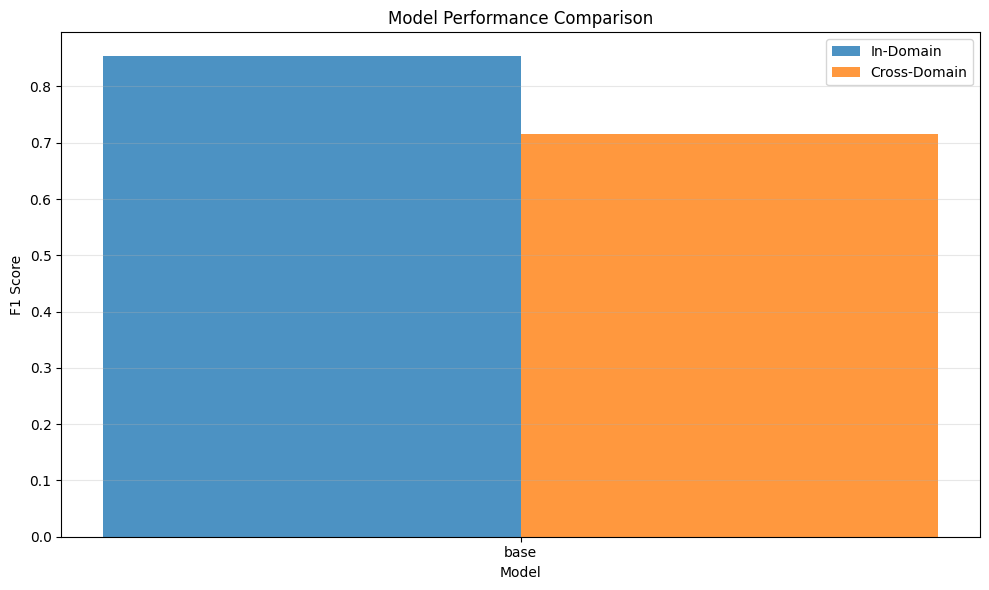

In [ ]:
# Visualize results
import matplotlib.pyplot as plt
import seaborn as sns

# Plot F1 scores comparison
models = list(eval_summary['model_summaries'].keys())
in_domain_f1 = [eval_summary['model_summaries'][m]['avg_in_domain_f1'] for m in models]
cross_domain_f1 = [eval_summary['model_summaries'][m]['avg_cross_domain_f1'] for m in models]

x = range(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar([i - width/2 for i in x], in_domain_f1, width, label='In-Domain', alpha=0.8)
ax.bar([i + width/2 for i in x], cross_domain_f1, width, label='Cross-Domain', alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('F1 Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/results/performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

---
### KAGGLE DEBUG
---

In [ ]:
from pathlib import Path
import sys
import pandas as pd
import torch
import transformers

# Kaggle failed dataset
FAILED_CSV = "/content/kaggle_failed_all.csv"

# Your project
PROJECT_ROOT = Path("/content/domain-shift-trustworthy-ai")

PERTURBATION_PY = PROJECT_ROOT / "src" / "perturbation_engine.py"
THESAURUS_PATH = PROJECT_ROOT / "dataset" / "data" / "dict.json"

# Make src importable
sys.path.insert(0, str(PROJECT_ROOT / "src"))

print("Project:", PROJECT_ROOT)
print("Perturbation:", PERTURBATION_PY)
print("Thesaurus:", THESAURUS_PATH)

print("\nEnvironment")
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA:", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Project: /content/domain-shift-trustworthy-ai
Perturbation: /content/domain-shift-trustworthy-ai/src/perturbation_engine.py
Thesaurus: /content/domain-shift-trustworthy-ai/dataset/data/dict.json

Environment
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
CUDA: True
Device: cuda


In [ ]:
from pathlib import Path

path = Path(FAILED_CSV)

with open(path, "rb") as f:
    data = f.read()

print("File size:", len(data))
print("0x96 count:", data.count(b"\x96"))

pos = data.find(b"\x96")
print("First 0x96 position:", pos)

print("\nBytes around first 0x96:")
print(data[pos-100:pos+100])


pos = data.find(b"\x96")

print(data[pos-200:pos+200].decode("utf-8", errors="replace"))


import csv

with open(FAILED_CSV, "rb") as f:
    raw = f.read()

# Find the physical line containing byte 0x96
pos = raw.find(b"\x96")

line_start = raw.rfind(b"\n", 0, pos) + 1
line_end = raw.find(b"\n", pos)

line = raw[line_start:line_end]

print("Line start:", line_start)
print("Line length:", len(line))
print(line[:1000])




File size: 678746
0x96 count: 3
First 0x96 position: 110048

Bytes around first 0x96:
b's;2026-01-27;Prabowo Kembali Kumpulkan Menteri pada Hambalang, Bahas Kerja Sama Pendidikan Indonesia\x96Inggris;0;https://www.tribunnews.com/nasional/7783684/prabowo-kembali-kumpulkan-menteri-di-hambalan'
an', 'serbuan', 'tampikan', 'tantangan', 'tentangan', 'tolakan'], 'position': 9}];[]
102;Tribun News;2026-01-27;Prabowo Kembali Kumpulkan Menteri pada Hambalang, Bahas Kerja Sama Pendidikan Indonesia�Inggris;0;https://www.tribunnews.com/nasional/7783684/prabowo-kembali-kumpulkan-menteri-di-hambalang-bahas-kerja-sama-pendidikan-indonesiainggris;Education;Prabowo Kembali Kumpulkan Menteri di Hambal
Line start: 109934
Line length: 5228
b"102;Tribun News;2026-01-27;Prabowo Kembali Kumpulkan Menteri pada Hambalang, Bahas Kerja Sama Pendidikan Indonesia\x96Inggris;0;https://www.tribunnews.com/nasional/7783684/prabowo-kembali-kumpulkan-menteri-di-hambalang-bahas-kerja-sama-pendidikan-indonesiainggris;Educ

In [ ]:
from perturbation_engine import PerturbationEngine
import pandas as pd

df = pd.read_csv(
    FAILED_CSV,
    encoding="cp1252",
    sep=";",
    engine="python",
    keep_default_na=False
)

print("Total rows:", len(df))
print(df.columns.tolist())

df["kaggle_success"] = (
    (~df["is_same_as_original"])
    & df["similarity_in_range"]
    & df["perturbation_in_range"]
)

kaggle_failed = df.loc[
    ~df["kaggle_success"]
].copy()

print("Kaggle failed:", len(kaggle_failed))
print("Kaggle successful:", df["kaggle_success"].sum())

print(
    kaggle_failed
    .groupby(["domain", "perturbation_level"])
    .size()
    .unstack(fill_value=0)
)

df.head()

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  498MB            

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  498MB            

model.safetensors: downloading bytes:           |  0.00B            

Total rows: 150
['id', 'source', 'date', 'text', 'label', 'url', 'domain', 'original_text', 'perturbed_text', 'perturbation_level', 'perturbation_rule', 'target_intensity', 'direct_lookup_words', 'reverse_parent_lookup_words', 'stemmed_lookup_words', 'failed_lookup_words', 'total_words', 'eligible_words', 'target_words', 'words_changed', 'actual_ratio_all_words', 'actual_ratio_eligible_words', 'word_cosine_similarity_mean', 'word_cosine_similarity_min', 'word_cosine_similarity_max', 'is_same_as_original', 'similarity_in_range', 'perturbation_in_range', 'diagnostic_stats', 'word_diagnostics', 'replacements']
Kaggle failed: 117
Kaggle successful: 33
perturbation_level  low
domain                 
Education           117


,id,source,date,text,label,url,domain,original_text,perturbed_text,perturbation_level,...,word_cosine_similarity_mean,word_cosine_similarity_min,word_cosine_similarity_max,is_same_as_original,similarity_in_range,perturbation_in_range,diagnostic_stats,word_diagnostics,replacements,kaggle_success
0,719,Detik Edu,2026-05-16,"Beasiswa Telkom University untuk Maba 2026, Bi...",0,https://www.detik.com/edu/beasiswa/d-8491182/b...,Education,"Beasiswa Telkom University untuk Maba 2026, Bi...","Beasiswa Telkom University untuk Maba 2026, Bi...",low,...,,,,True,False,False,"{'words_no_dictionary_entry': 3, 'words_no_syn...","[{'word': 'Beasiswa', 'lookup_found': True, 'l...",[],False
1,781,Detik Edu,2026-05-13,"Usai Sidang Tuntutan Hari Ini, Eks Mendikbud N...",0,https://www.detik.com/edu/detikpedia/d-8487374...,Education,"Usai Sidang Tuntutan Hari Ini, Eks Mendikbud N...","Usai Sidang Tuntutan Hari Ini, Eks Mendikbud N...",low,...,,,,True,False,False,"{'words_no_dictionary_entry': 4, 'words_no_syn...","[{'word': 'Usai', 'lookup_found': True, 'looku...",[],False
2,679,Detik Edu,2026-05-18,AHY: Indonesia Harus Reformasi Pendidikan Kala...,0,https://www.detik.com/edu/edutainment/d-849373...,Education,AHY: Indonesia Harus Reformasi Pendidikan Kala...,AHY: Indonesia Harus Reformasi Pendidikan Kala...,low,...,,,,True,False,False,"{'words_no_dictionary_entry': 2, 'words_no_syn...","[{'word': 'AHY', 'lookup_found': False, 'looku...",[],False
3,186,Tribun News,2025-10-15,"Dukung Pendidikan Anak Bangsa, Pemkot Surabaya...",0,https://www.tribunnews.com/regional/7742313/du...,Education,"Dukung Pendidikan Anak Bangsa, Pemkot Surabaya...","Dukung Pendidikan Anak Bangsa, Pemkot Surabaya...",low,...,,,,True,False,False,"{'words_no_dictionary_entry': 4, 'words_no_syn...","[{'word': 'Dukung', 'lookup_found': True, 'loo...",[],False
4,787,Detik Edu,2026-05-13,"Siswa Bisa Usul Menu MBG Agar Sesuai Selera, S...",1,https://www.detik.com/edu/sekolah/d-8486430/si...,Education,"Siswa Bisa Usul Menu MBG Agar Sesuai Selera, S...","Siswa Bisa Usul Menu MBG Agar Sesuai Selera, S...",low,...,,,,True,False,False,"{'words_no_dictionary_entry': 3, 'words_no_syn...","[{'word': 'Siswa', 'lookup_found': True, 'look...",[],False


In [ ]:
from tqdm.auto import tqdm
import pandas as pd

engine = PerturbationEngine(
    thesaurus_path=str(THESAURUS_PATH),
    random_seed=42,
    sim_min=0.80,
    sim_max=0.95,
)

results = []

# SAME 117 Kaggle-failed rows for every perturbation level
base_df = kaggle_failed.copy()

print("Base rows:", len(base_df))
print()

for level in ["low", "medium", "high"]:

    print("=" * 80)
    print(f"{level.upper()} — SAME Kaggle failures → Colab")
    print("=" * 80)
    print("Rows:", len(base_df))

    result_df = engine.apply_to_dataframe(
        df=base_df.copy(),
        text_column="text",
        level=level,
        output_csv=None,
    )

    result_df["rerun_environment"] = "colab"
    result_df["rerun_level"] = level

    results.append(result_df)

rerun_df = pd.concat(
    results,
    ignore_index=True,
)

print("\nTotal rerun rows:", len(rerun_df))



Base rows: 117

LOW — SAME Kaggle failures → Colab
Rows: 117


Perturbing LOW:   0%|          | 0/117 [00:00<?, ?it/s]


LOW SUCCESS: 110/117 (94.02%)
MEDIUM — SAME Kaggle failures → Colab
Rows: 117


Perturbing MEDIUM:   0%|          | 0/117 [00:00<?, ?it/s]


MEDIUM SUCCESS: 110/117 (94.02%)
HIGH — SAME Kaggle failures → Colab
Rows: 117


Perturbing HIGH:   0%|          | 0/117 [00:00<?, ?it/s]


HIGH SUCCESS: 110/117 (94.02%)

Total rerun rows: 351


OSError: Cannot save file into a non-existent directory: '/contentperturbation_validation'

In [ ]:

# ============================================================
# SAVE RESULT
# ============================================================

output_path = Path("/content/kaggle_failed_rerun_colab.csv")

rerun_df.to_csv(
    output_path,
    index=False,
)

print(f"Saved to: {output_path}")
print(f"Rows saved: {len(rerun_df)}")

Saved to: /content/kaggle_failed_rerun_colab.csv
Rows saved: 351


In [ ]:
rerun_df["colab_success"] = (
    (~rerun_df["is_same_as_original"])
    & rerun_df["similarity_in_range"]
    & rerun_df["perturbation_in_range"]
)

summary = (
    rerun_df
    .groupby(["perturbation_level", "domain"])
    .agg(
        total=("colab_success", "size"),
        success=("colab_success", "sum"),
    )
    .reset_index()
)

summary["failed"] = (
    summary["total"] - summary["success"]
)

summary["success_rate"] = (
    summary["success"] / summary["total"] * 100
)

print(summary.to_string(index=False))

perturbation_level    domain  total  success  failed  success_rate
              high Education    117      110       7     94.017094
               low Education    117      110       7     94.017094
            medium Education    117      110       7     94.017094


In [ ]:
print(kaggle_failed["perturbation_level"].value_counts(dropna=False))

perturbation_level
low    117
Name: count, dtype: int64


In [ ]:
print(rerun_df.columns.tolist())

['id', 'source', 'date', 'text', 'label', 'url', 'domain', 'original_text', 'perturbed_text', 'perturbation_level', 'perturbation_rule', 'target_intensity', 'direct_lookup_words', 'reverse_parent_lookup_words', 'stemmed_lookup_words', 'failed_lookup_words', 'total_words', 'eligible_words', 'target_words', 'words_changed', 'actual_ratio_all_words', 'actual_ratio_eligible_words', 'word_cosine_similarity_mean', 'word_cosine_similarity_min', 'word_cosine_similarity_max', 'is_same_as_original', 'similarity_in_range', 'perturbation_in_range', 'diagnostic_stats', 'word_diagnostics', 'replacements', 'kaggle_success', 'perturbation_success', 'rerun_environment', 'rerun_level', 'colab_success']


In [ ]:
comparison = rerun_df[
    [
        "id",
        "domain",
        "perturbation_level",
        "rerun_level",
        "original_text",
        "perturbed_text",
        "is_same_as_original",
        "similarity_in_range",
        "perturbation_in_range",
        "kaggle_success",
        "colab_success",
        "word_cosine_similarity_mean",
        "word_cosine_similarity_min",
        "word_cosine_similarity_max",
        "eligible_words",
        "target_words",
        "words_changed",
    ]
].copy()

comparison = comparison.rename(
    columns={
        "perturbation_level": "kaggle_level",
        "rerun_level": "colab_level",
    }
)

comparison.head()

,id,domain,kaggle_level,colab_level,original_text,perturbed_text,is_same_as_original,similarity_in_range,perturbation_in_range,kaggle_success,colab_success,word_cosine_similarity_mean,word_cosine_similarity_min,word_cosine_similarity_max,eligible_words,target_words,words_changed
0,719,Education,low,low,"Beasiswa Telkom University untuk Maba 2026, Bi...","Beasiswa Telkom University untuk Maba 2026, Bi...",False,True,True,False,True,0.826823,0.826823,0.826823,2,1,1
1,781,Education,low,low,"Usai Sidang Tuntutan Hari Ini, Eks Mendikbud N...","Usai Sidang Tuntutan Hari Ini, Eks Mendikbud N...",False,True,True,False,True,0.805043,0.805043,0.805043,1,1,1
2,679,Education,low,low,AHY: Indonesia Harus Reformasi Pendidikan Kala...,AHY: Indonesia Harus Reformasi Pendidikan Kala...,False,True,True,False,True,0.854767,0.854767,0.854767,4,1,1
3,186,Education,low,low,"Dukung Pendidikan Anak Bangsa, Pemkot Surabaya...","Dukung Pendidikan Anak Bangsa, Pemkot Surabaya...",False,True,True,False,True,0.860414,0.860414,0.860414,5,1,1
4,787,Education,low,low,"Siswa Bisa Usul Menu MBG Agar Sesuai Selera, S...","Siswa Bisa Usul Menu MBG Supaya Sesuai Selera,...",False,True,True,False,True,0.907139,0.907139,0.907139,3,1,1


In [ ]:
# ============================================================
# CLEAN KAGGLE → COLAB COMPARISON
# ============================================================

final_comparison = comparison.copy()

# Use the existing Kaggle columns
final_comparison = final_comparison.rename(
    columns={
        "kaggle_level_x": "kaggle_level",
        "kaggle_success_x": "kaggle_success",
    }
)

# Make sure Kaggle and Colab levels match
final_comparison["level_match"] = (
    final_comparison["kaggle_level"]
    == final_comparison["colab_level"]
)

# Environment success difference
final_comparison["environment_difference"] = (
    final_comparison["kaggle_success"]
    != final_comparison["colab_success"]
)

print(
    "Rows:",
    len(final_comparison)
)

print(
    "Kaggle FAILED → Colab SUCCESS:",
    (
        (~final_comparison["kaggle_success"])
        & final_comparison["colab_success"]
    ).sum()
)

print(
    "Kaggle FAILED → Colab FAILED:",
    (
        (~final_comparison["kaggle_success"])
        & (~final_comparison["colab_success"])
    ).sum()
)

print(
    "Kaggle SUCCESS → Colab FAILED:",
    (
        final_comparison["kaggle_success"]
        & (~final_comparison["colab_success"])
    ).sum()
)

print(
    "Kaggle SUCCESS → Colab SUCCESS:",
    (
        final_comparison["kaggle_success"]
        & final_comparison["colab_success"]
    ).sum()
)

Rows: 351
Kaggle FAILED → Colab SUCCESS: 330
Kaggle FAILED → Colab FAILED: 21
Kaggle SUCCESS → Colab FAILED: 0
Kaggle SUCCESS → Colab SUCCESS: 0


In [ ]:
print(final_comparison.columns.tolist())

['id', 'domain', 'kaggle_level_x', 'colab_level', 'original_text', 'perturbed_text', 'is_same_as_original', 'similarity_in_range', 'perturbation_in_range', 'kaggle_success_x', 'colab_success', 'word_cosine_similarity_mean', 'word_cosine_similarity_min', 'word_cosine_similarity_max', 'eligible_words', 'target_words', 'words_changed', 'kaggle_level_y', 'kaggle_success_y', 'kaggle_same', 'kaggle_similarity_in_range', 'kaggle_perturbation_in_range', 'kaggle_cosine_mean', 'kaggle_cosine_min', 'kaggle_cosine_max', 'kaggle_eligible_words', 'kaggle_target_words', 'kaggle_words_changed']


In [ ]:
OUTPUT = Path("/content/kaggle_failed_rerun_in_colab.csv")

final_comparison.to_csv(
    OUTPUT,
    index=False,
    encoding="utf-8-sig",
)

print(f"Saved → {OUTPUT}")

Saved → /content/kaggle_failed_rerun_in_colab.csv


---

## 6. Launch Dashboard (Optional)

Launch the interactive Streamlit dashboard for visualization and testing.

In [ ]:
# Install localtunnel for public URL
!npm install -g localtunnel

In [ ]:
# Launch dashboard in background
import subprocess
import threading
import time

def run_streamlit():
    subprocess.run(['streamlit', 'run', 'src/dashboard_app.py', '--server.port', '8501'])

# Start Streamlit in background
thread = threading.Thread(target=run_streamlit, daemon=True)
thread.start()

time.sleep(5)
print("Streamlit is starting...")

In [ ]:
# Create public URL with localtunnel
!lt --port 8501

## 7. Download Results

In [ ]:
# Create zip file of all results
!zip -r results.zip /content/drive/MyDrive/thesis/results/
!zip -r checkpoints.zip /content/drive/MyDrive/thesis/checkpoints/

print("Results and checkpoints zipped successfully!")
print("Files are saved in Google Drive and can be downloaded from there.")